In [56]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from scipy import stats, special
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, mannwhitneyu, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any
import warnings

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

In [ ]:
# ---------- helpers ----------

def _dir_from_alt(alternative: str) -> int:
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    sk = set(comparison_dict.get('shared', {}).keys())
    dk = set(comparison_dict.get('disjoint', {}).keys())
    common = sorted(sk & dk)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["shared"][k] for k in common], float)
    d = np.array([comparison_dict["disjoint"][k] for k in common], float)
    z = s - d
    return s, d, z


# ---------- effect sizes ----------

def cohens_d(shared, disjoint, *, alternative="greater", paired=False) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        return sign * (np.mean(z) / sd)

    n1, n2 = s.size, d.size
    if n1 < 2 or n2 < 2:
        return np.nan
    sp2 = ((n1 - 1)*np.var(s, ddof=1) + (n2 - 1)*np.var(d, ddof=1)) / (n1 + n2 - 2)
    sp = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return sign * ((np.mean(s) - np.mean(d)) / sp)


def hodges_lehmann(shared, disjoint, *, alternative="greater", paired=False,
                   max_pairs=5_000_000, rng=None, approx_pairs=2_000_000) -> float:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        return float(sign * np.median(s - d))

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan

    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()
        base = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k = int(min(approx_pairs, total))
        diffs = s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)

    return float(sign * base)

def ps_and_delta(shared, disjoint, *, alternative="greater", paired=False,
                 eps=0.0, method="asymptotic") -> Tuple[float, float]:
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    sign = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n   # P(z>0)+0.5P(z=0)
        delta= 2.0*A_sh - 1.0
        return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)

    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    U_sh, _ = stats.mannwhitneyu(s, d, alternative="greater", method=method)
    A_sh = U_sh / (n1 * n2)
    delta = 2.0*A_sh - 1.0
    return (A_sh, delta) if sign > 0 else (1.0 - A_sh, -delta)


# ---------- BCa CI implementation (generic) ----------

def _phi_inv(p: float) -> float:
    """
    Inverse CDF (quantile) for the standard normal distribution.
    Uses scipy.stats.norm.ppf for stability.
    """
    return stats.norm.ppf(p)

def _bca_ci_from_boot_and_jack(theta_hat: float, boot: np.ndarray, jack: np.ndarray, alpha=0.05) -> Tuple[float, float]:
    boot = np.asarray(boot, float)
    jack = np.asarray(jack, float)
    B = np.isfinite(boot).sum()
    if B == 0 or jack.size == 0:
        return (np.nan, np.nan)

    # bias-correction z0
    prop_lt = np.mean(boot < theta_hat)
    z0 = _phi_inv(prop_lt)

    # acceleration a via jackknife influence
    jack_mean = np.mean(jack)
    u = jack_mean - jack
    num = np.sum(u**3)
    den = 6.0 * (np.sum(u**2) ** 1.5)
    a = num / den if den != 0 else 0.0

    # adjusted quantiles
    al = alpha/2
    au = 1 - alpha/2
    z_al = _phi_inv(al)
    z_au = _phi_inv(au)

    adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
    adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))

    lo = np.quantile(boot, adj_al, method="nearest")
    hi = np.quantile(boot, adj_au, method="nearest")
    return (float(lo), float(hi))


def _jackknife_stat(effect_fn, s: np.ndarray, d: np.ndarray, *, paired: bool, alternative: str) -> np.ndarray:
    # Leave-one-out across the combined data (pairs as units when paired)
    if paired:
        n = s.size
        out = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            out[i] = effect_fn(s[mask], d[mask], alternative=alternative, paired=True)
        return out
    else:
        n1, n2 = s.size, d.size
        out = np.empty(n1 + n2)
        # leave-one-out from group 1
        for i in range(n1):
            out[i] = effect_fn(np.delete(s, i), d, alternative=alternative, paired=False)
        # leave-one-out from group 2
        for j in range(n2):
            out[n1 + j] = effect_fn(s, np.delete(d, j), alternative=alternative, paired=False)
        return out


def _ci_wrapper(theta_hat, boot_vals, jack_vals, alpha, method="bca"):
    boot_vals = np.asarray(boot_vals)
    if method == "percentile" or jack_vals.size == 0:
        return (float(np.percentile(boot_vals, 2.5)),
                float(np.percentile(boot_vals, 97.5)))
    elif method == "bca":
        try:
            return _bca_ci_from_boot_and_jack(theta_hat, boot_vals, jack_vals, alpha)
        except ValueError:
            # fallback if adjusted quantiles go out of bounds
            return (float(np.percentile(boot_vals, 2.5)),
                    float(np.percentile(boot_vals, 97.5)))


# ---------- main: bootstrap + reporting ----------

def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(list(comparison_dict["shared"].values()), float)
        d = np.array(list(comparison_dict["disjoint"].values()), float)
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

In [4]:
def save_figure(figure_name):
    plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")

def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()


def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )

    plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

# Pyramidal Rectangular Set

In [5]:
# Pull Data from LSMM Data
with open('pyr_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:391: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['connectome_index'] = data['structural']['post_cell'].index
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:417: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['pt_position'] = [[data['structural']['post_cell'].iloc[i]['pt_position_x'],data['structural']['post_cell'].iloc[i]['pt_position

Generating Connectome...


100%|██████████| 44293/44293 [03:02<00:00, 242.10it/s]


Generating Connectome...


100%|██████████| 44293/44293 [03:13<00:00, 229.05it/s]


In [6]:
### Pull necessary data from V1DD using LSMMData Manager
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']

# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9 * 9 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids

In [7]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1

# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

In [8]:
S_nonzero_pairwise = {}
W_nonzero_pairwise = {}
B_pairwise = {}
for connection_type in comparison_functions:
    S_nonzero_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            if w[(j, i)] > 0:
                S_nonzero_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]

S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

B_out = {}
for connection_type in comparison_functions:
    B_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if connection_type(j, i, A) and j != i]) > 0:
            B_out[connection_type.__name__][j] = sum([b[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if connection_type(j, i, A) and j != i])

B_in = {}
for connection_type in comparison_functions:
    B_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A) and i != j]) > 0:
            B_in[connection_type.__name__][i] = sum([b[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if connection_type(j, i, A) and j != i])


# Histograms By Connection Type

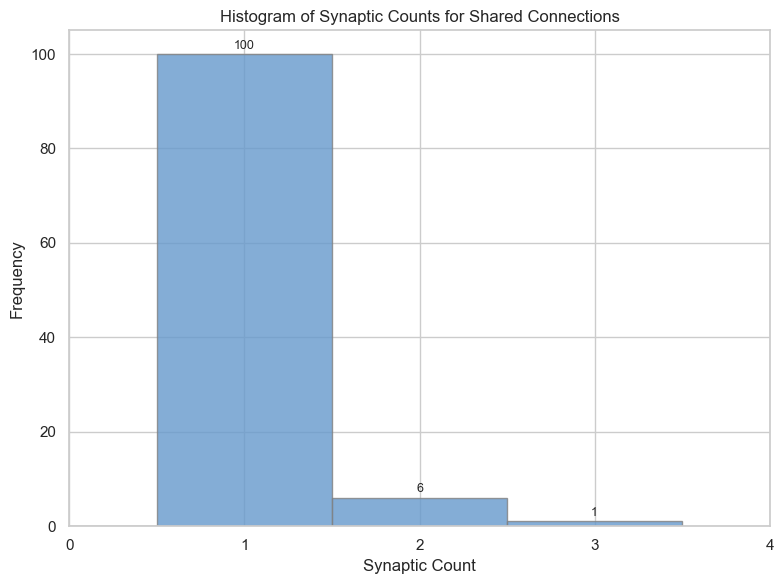

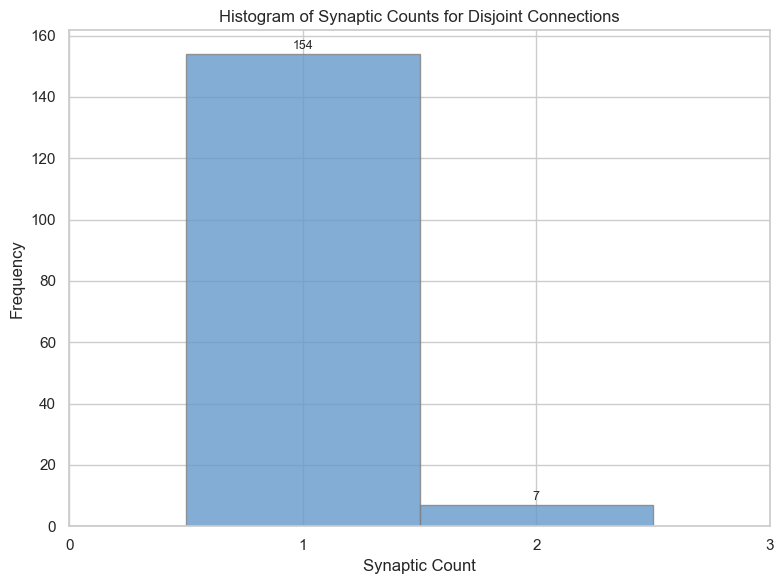

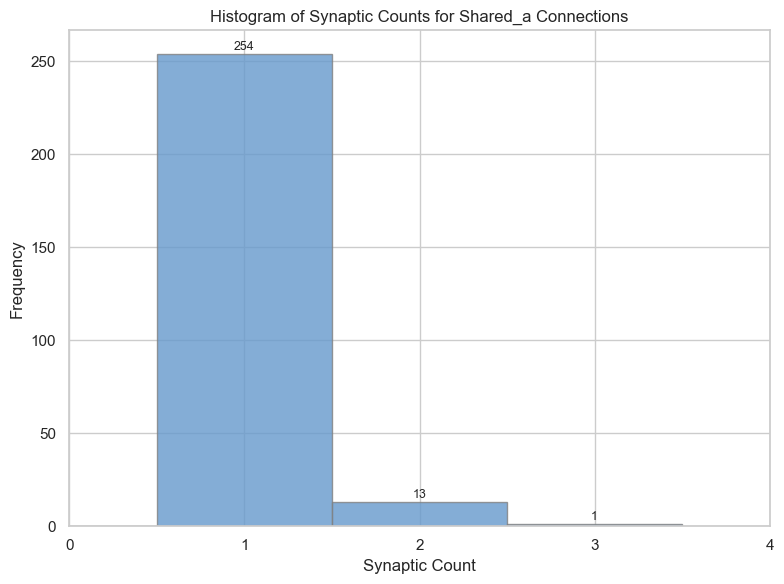

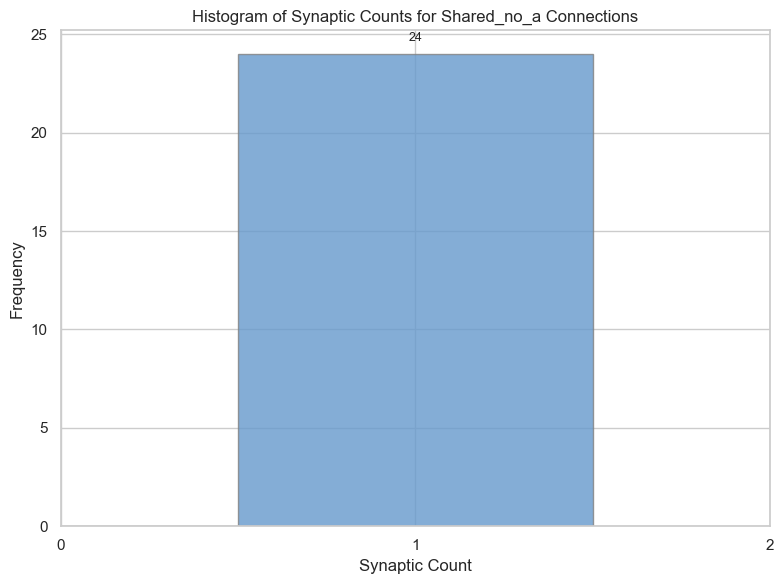

In [9]:
for group in groups:
    synaptic_count_histogram(
        values_dict=S_nonzero_pairwise[group],
        connection_type=group,
        save=False,
        figure_name=None
    )

# Report Results

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1762, P-value: 0.5699

[UNPAIRED] Effect sizes (pos = 'greater')  n1=107, n2=161
  Test p-value: 0.5703
  Shared median = 0.00659381, Disjoint median = 0.00626211

  Effect sizes with 95% CI (percentile):
    HL shift: -0.000112995 : CI [-0.00126172, 0.000940501]
    PS:       0.494 : CI [0.424, 0.559]   (δ=-0.013 : CI [-0.152, 0.118])
    Cohen's d: 0.053 : CI [-0.203, 0.275]

  Effect sizes with 95% CI (BCa):
    HL shift: -0.000112995 : CI [-0.00128304, 0.000929475]
    PS:       0.494 : CI [0.428, 0.560]   (δ=-0.013 : CI [-0.145, 0.120])
    Cohen's d: 0.053 : CI [-0.199, 0.276]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


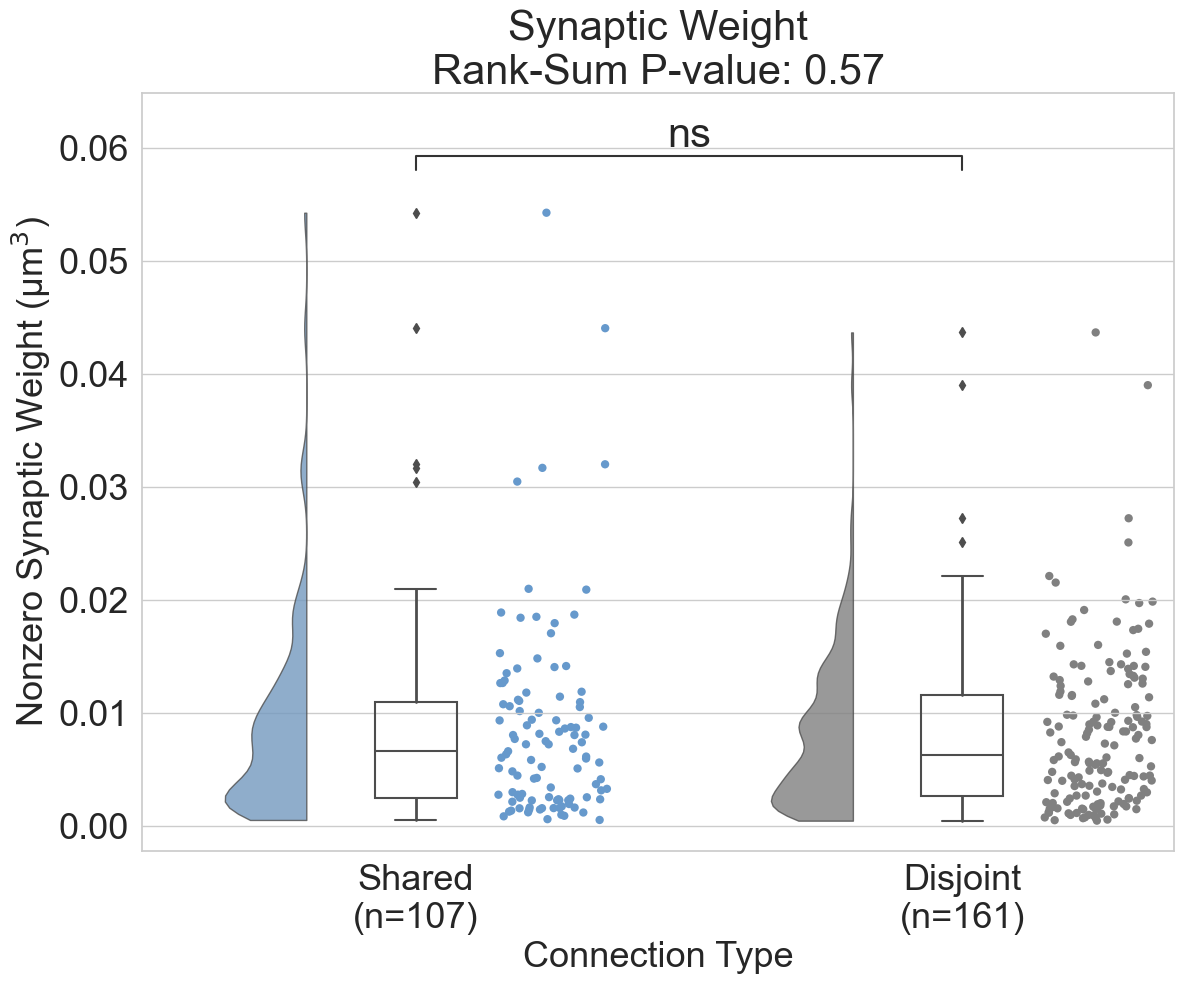

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


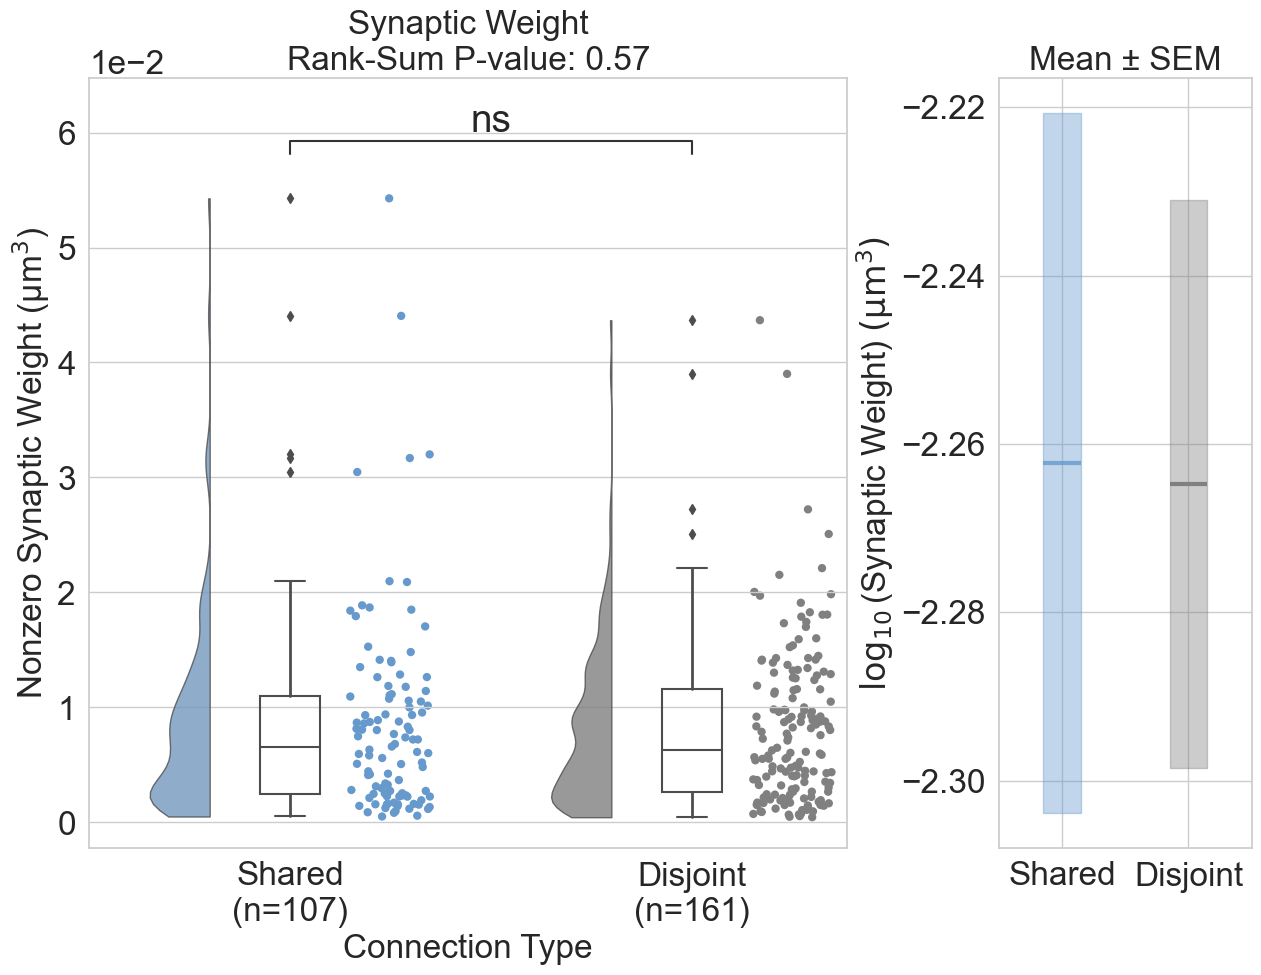

In [10]:
ranksum_signedrank_two_group_comparison(W_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn'
                                        )

# bootstrap_effects_and_p(W_nonzero_pairwise, alternative='greater')

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.7041, P-value: 0.7593

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=61
  Test p-value: 0.7618
  Shared median = 0.0103093, Disjoint median = 0.0162602

  Effect sizes with 95% CI (percentile):
    HL shift: -0.00078901 : CI [-0.00813008, 0.00398057]
    PS:       0.463 : CI [0.356, 0.563]   (δ=-0.074 : CI [-0.289, 0.127])
    Cohen's d: 0.123 : CI [-0.258, 0.435]

  Effect sizes with 95% CI (BCa):
    HL shift: -0.00078901 : CI [-0.00813008, 0.00420008]
    PS:       0.463 : CI [0.358, 0.567]   (δ=-0.074 : CI [-0.284, 0.134])
    Cohen's d: 0.123 : CI [-0.254, 0.457]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 916.5, P-value: 0.406

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=61
  Test p-value: 0.406
  Median paired difference = 0

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [-0.00892857, 0.00703443]
    PS:       0.492 : CI [0.377, 0.615]   (δ=-0.016 : CI [-0.246, 0

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


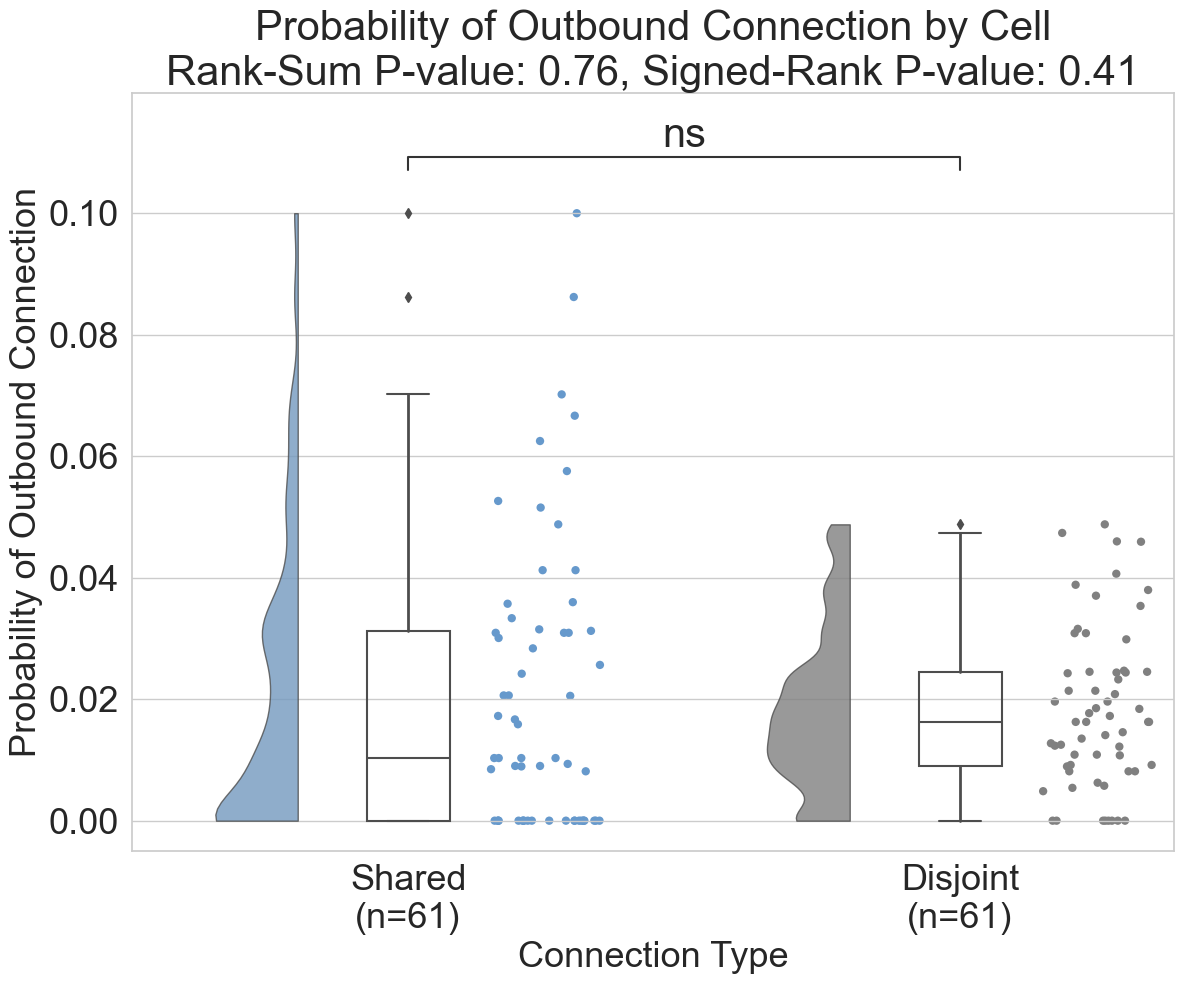

C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:7.593e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


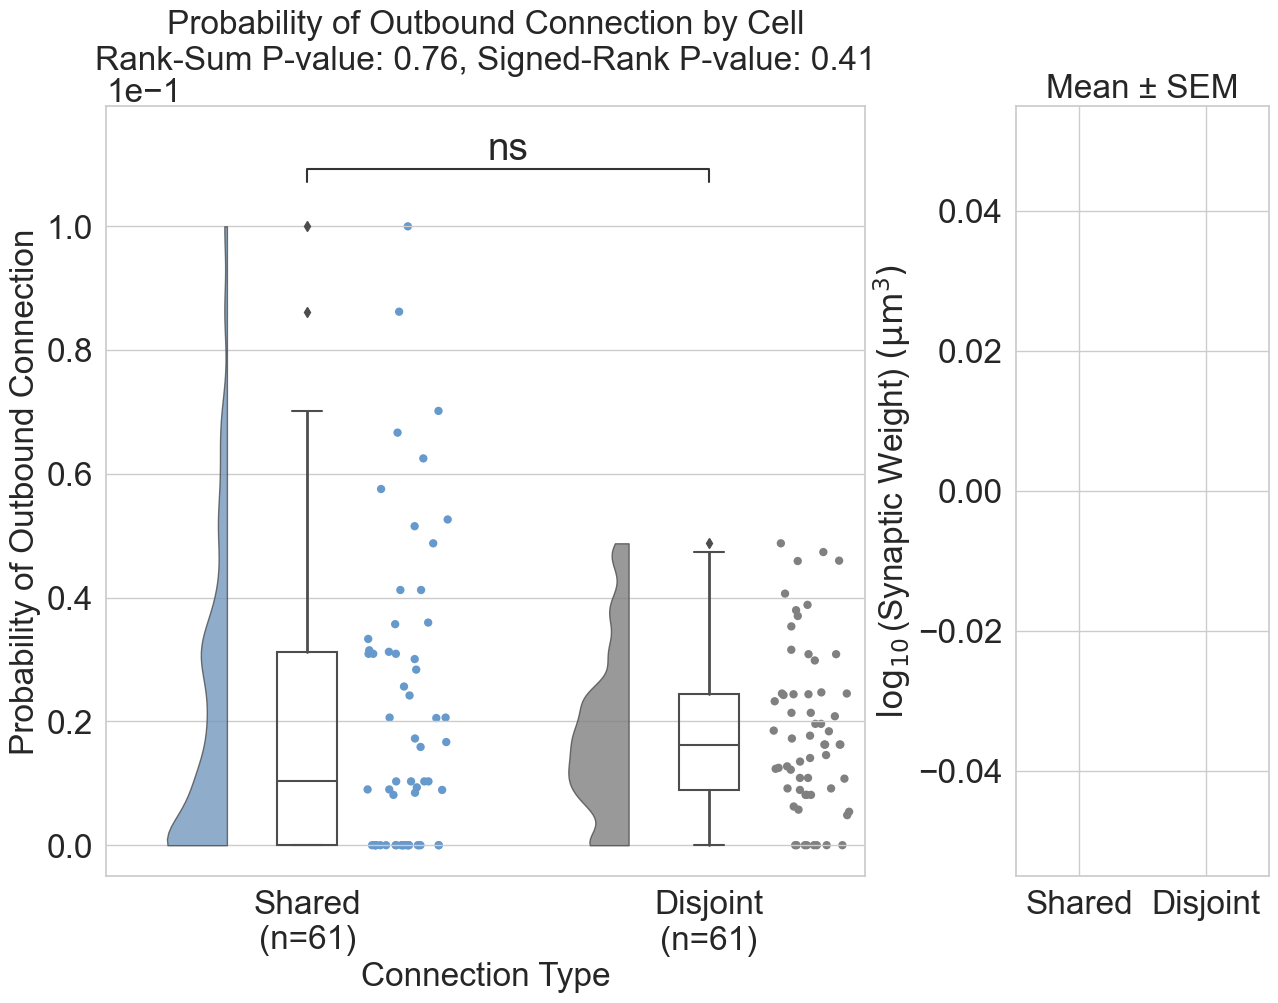

In [11]:
ranksum_signedrank_two_group_comparison(B_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Outbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.2647, P-value: 0.6044

[UNPAIRED] Effect sizes (pos = 'greater')  n1=39, n2=53
  Test p-value: 0.6059
  Shared median = 0.00702027, Disjoint median = 0.00672958

  Effect sizes with 95% CI (percentile):
    HL shift: -0.00028674 : CI [-0.00219758, 0.00161663]
    PS:       0.484 : CI [0.359, 0.608]   (δ=-0.032 : CI [-0.281, 0.216])
    Cohen's d: -0.041 : CI [-0.465, 0.388]

  Effect sizes with 95% CI (BCa):
    HL shift: -0.00028674 : CI [-0.00219672, 0.00161656]
    PS:       0.484 : CI [0.359, 0.605]   (δ=-0.032 : CI [-0.281, 0.210])
    Cohen's d: -0.041 : CI [-0.453, 0.397]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 266, P-value: 0.6043

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=33
  Test p-value: 0.6043
  Median paired difference = -0.000307395

  Effect sizes with 95% CI (percentile):
    HL shift: -0.000307395 : CI [-0.00232259, 0.00212261]
    PS:       0.485 : CI [0.333, 0.667]  

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


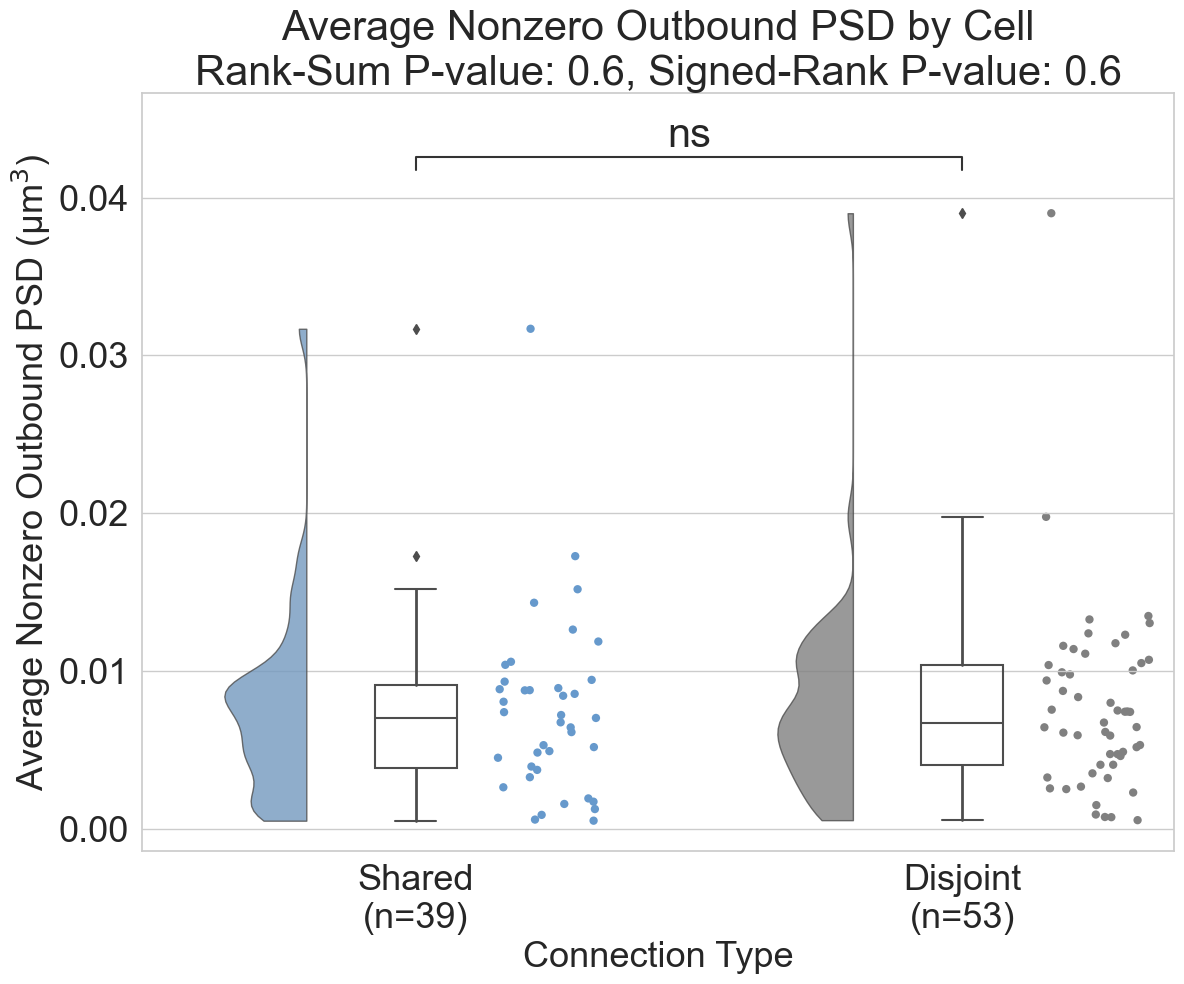

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:6.044e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


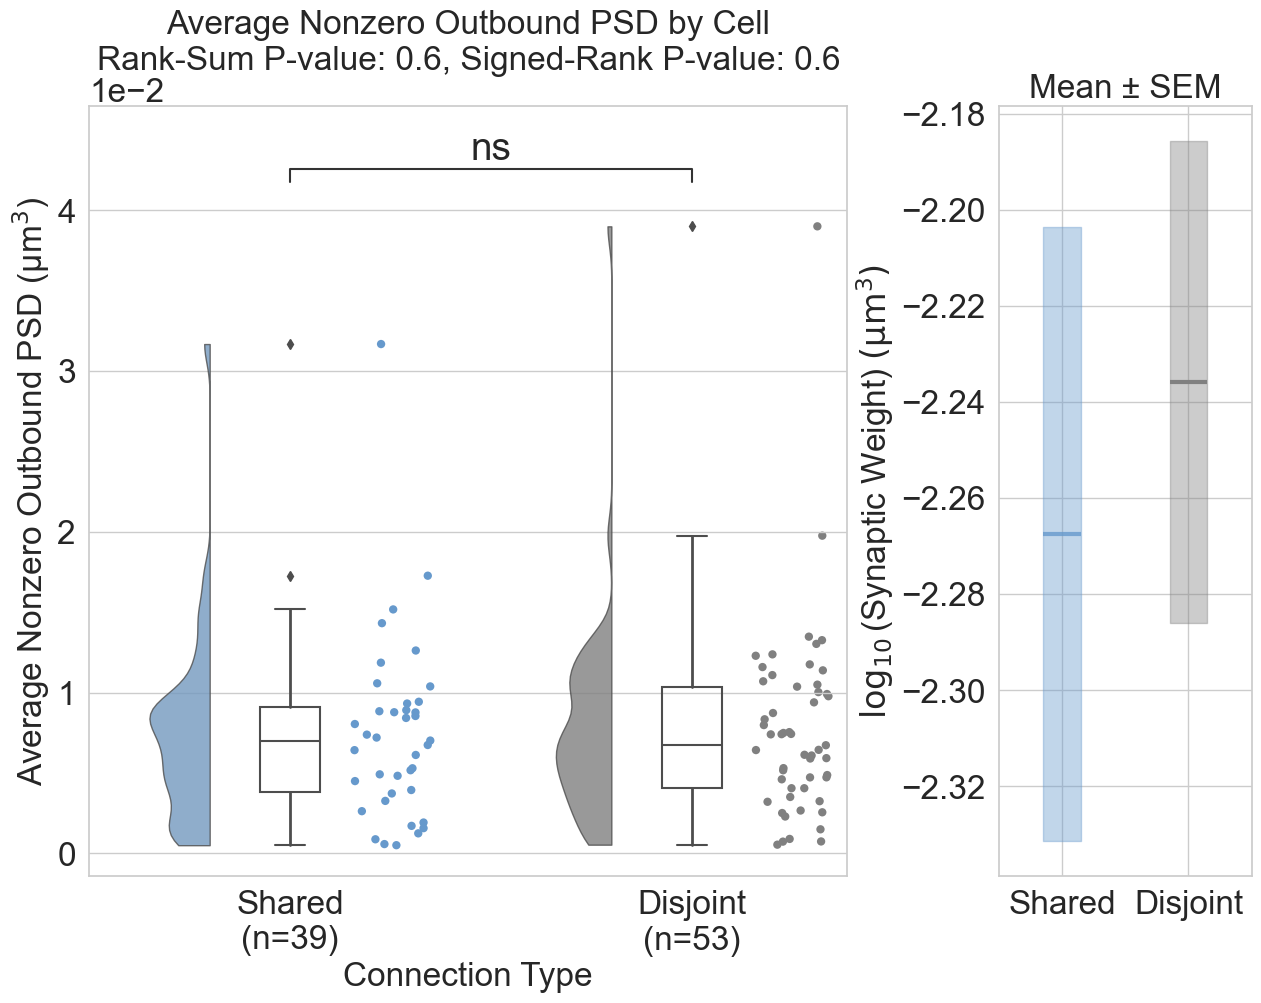

In [12]:
ranksum_signedrank_two_group_comparison(W_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name = 'Avg_Nonzero_Outbound_PSD'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -1.755, P-value: 0.9603


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnin


[UNPAIRED] Effect sizes (pos = 'greater')  n1=220, n2=221
  Test p-value: 0.9767
  Shared median = 0, Disjoint median = 0

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.452 : CI [0.405, 0.498]   (δ=-0.097 : CI [-0.190, -0.004])
    Cohen's d: 0.007 : CI [-0.190, 0.186]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.452 : CI [0.406, 0.500]   (δ=-0.097 : CI [-0.188, -0.001])
    Cohen's d: 0.007 : CI [-0.175, 0.199]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 4262, P-value: 0.7186

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=220
  Test p-value: 0.7186
  Median paired difference = 0

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.436 : CI [0.384, 0.489]   (δ=-0.127 : CI [-0.232, -0.023])
    Cohen's d: 0.006 : CI [-0.143, 0.126]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.436 : CI [0.382, 0.484]   (δ=-0.127 : CI [-0.236

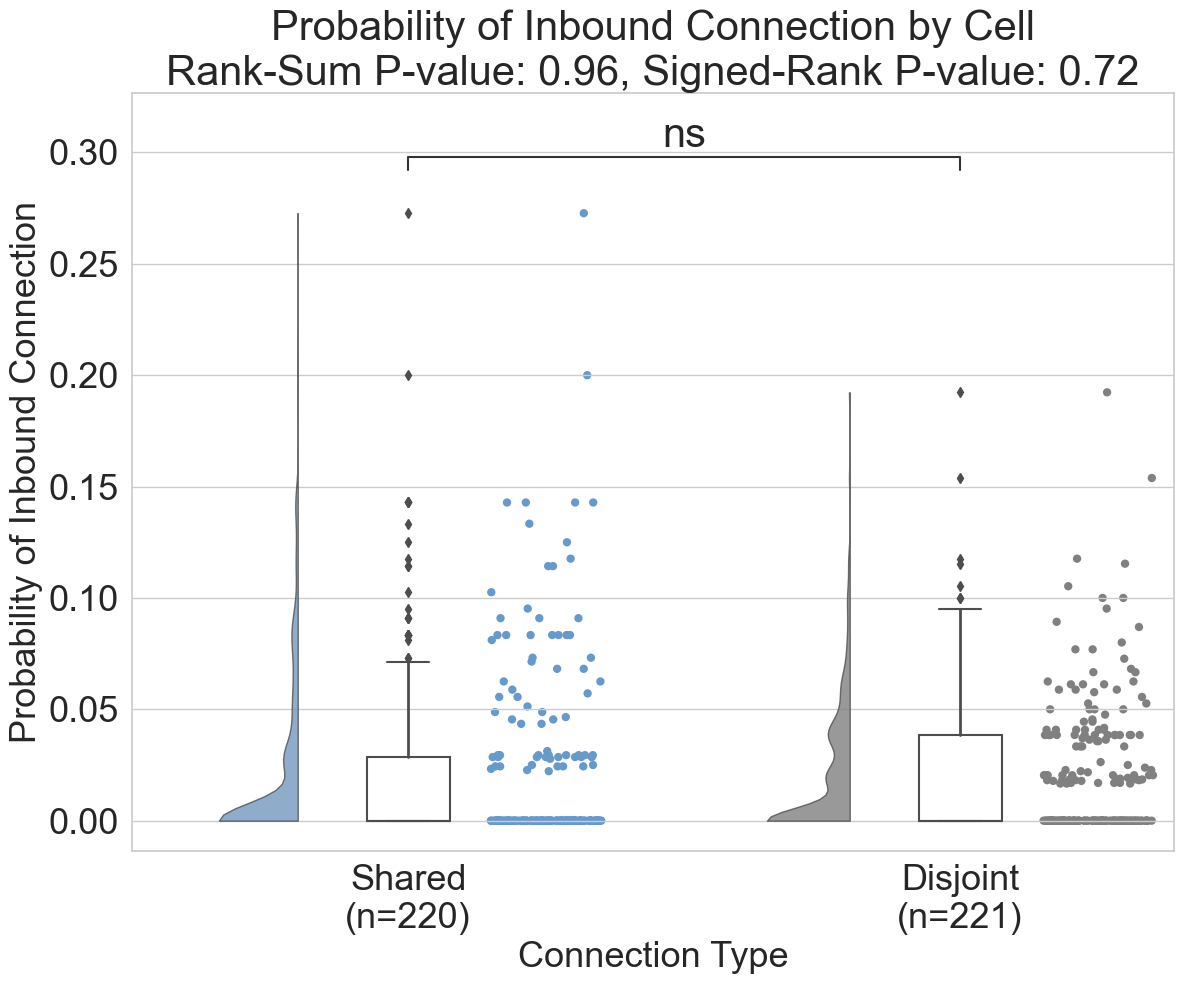

C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:9.603e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


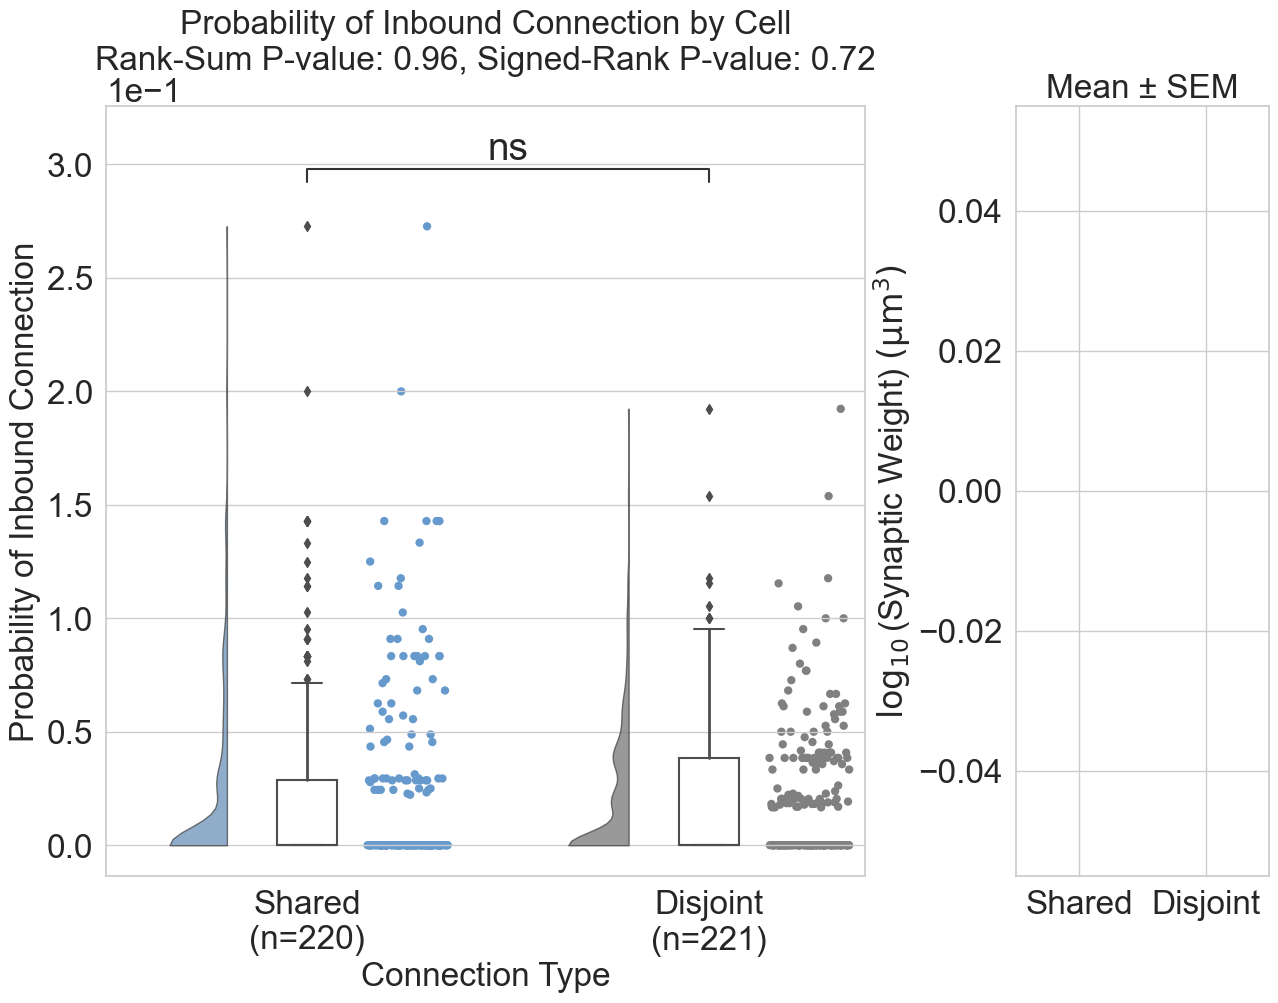

In [13]:
ranksum_signedrank_two_group_comparison(B_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Inbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1347, P-value: 0.5536

[UNPAIRED] Effect sizes (pos = 'greater')  n1=71, n2=103
  Test p-value: 0.5542
  Shared median = 0.00720981, Disjoint median = 0.00727178

  Effect sizes with 95% CI (percentile):
    HL shift: -0.000130309 : CI [-0.00157865, 0.00142374]
    PS:       0.494 : CI [0.410, 0.585]   (δ=-0.012 : CI [-0.180, 0.170])
    Cohen's d: 0.036 : CI [-0.265, 0.331]

  Effect sizes with 95% CI (BCa):
    HL shift: -0.000130309 : CI [-0.00153819, 0.00148352]
    PS:       0.494 : CI [0.414, 0.588]   (δ=-0.012 : CI [-0.172, 0.175])
    Cohen's d: 0.036 : CI [-0.232, 0.362]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 431, P-value: 0.288

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=39
  Test p-value: 0.288
  Median paired difference = 0.000275197

  Effect sizes with 95% CI (percentile):
    HL shift: 0.000275197 : CI [-0.00190998, 0.00312377]
    PS:       0.513 : CI [0.359, 0.667]   (δ

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


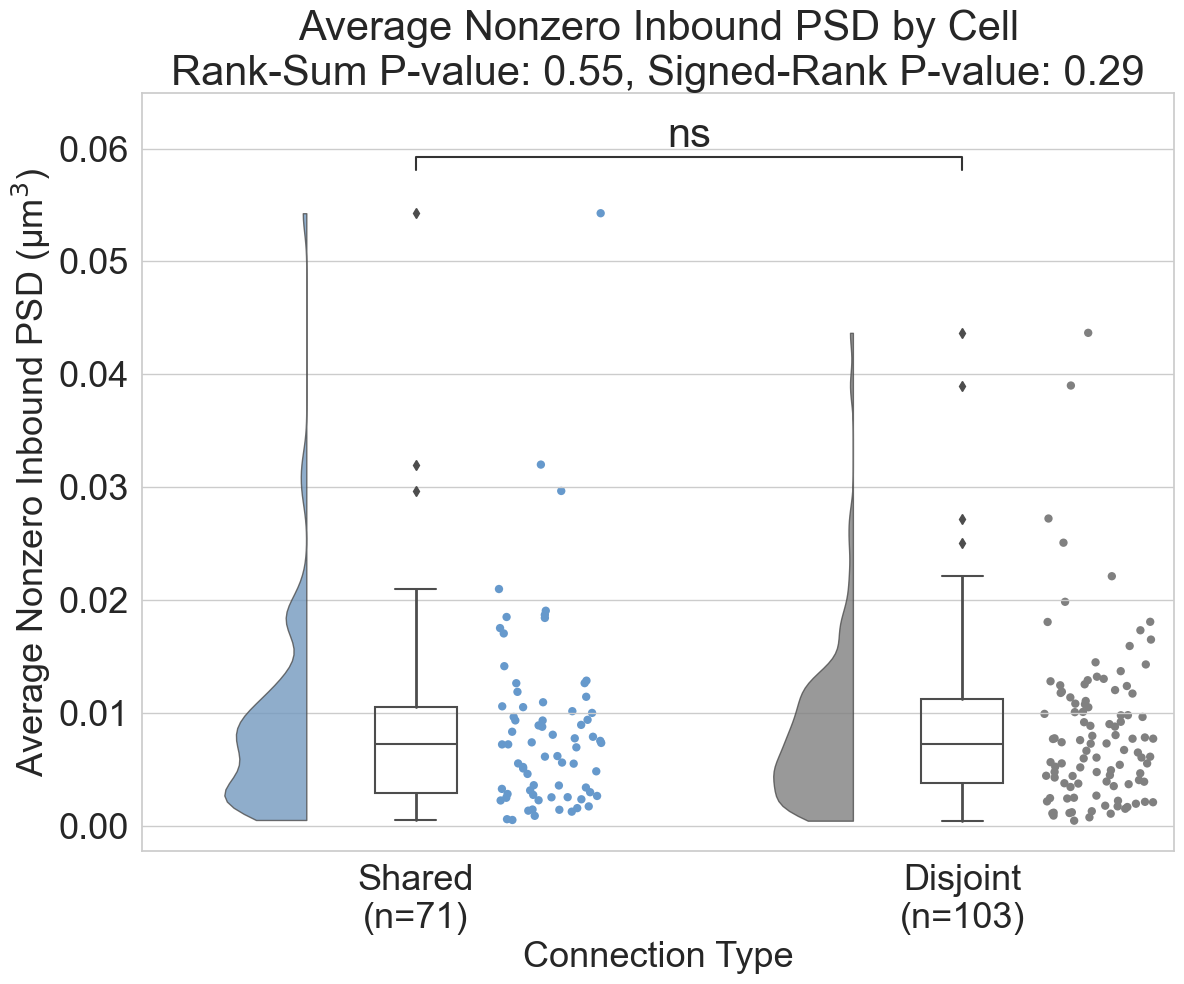

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:5.536e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


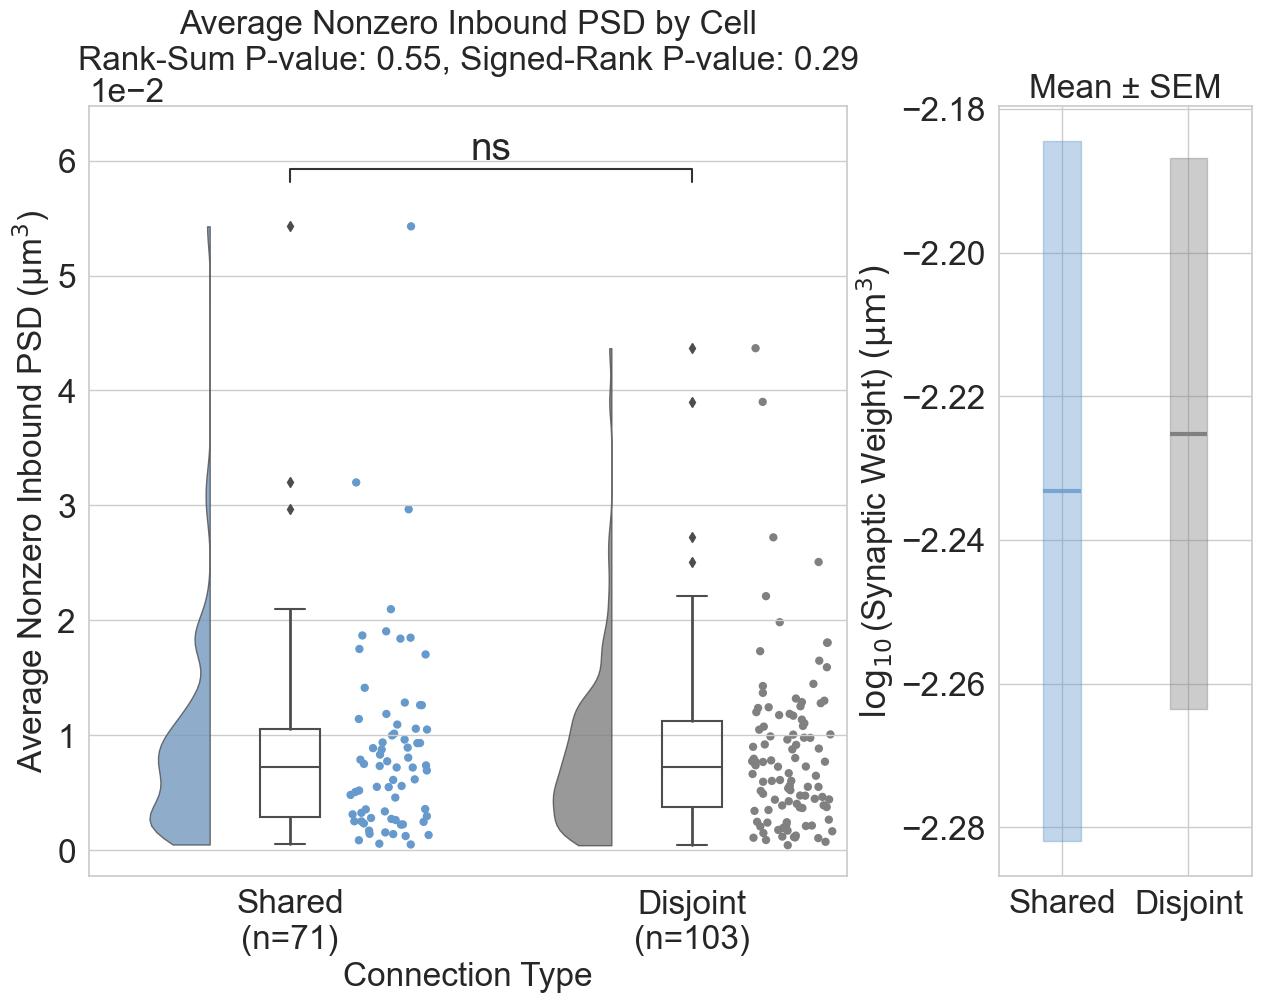

In [14]:
ranksum_signedrank_two_group_comparison(W_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD'
                                        )

# Normalized Synaptic Counts (Mirrored to PSD)

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3098, P-value: 0.3784


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "



[UNPAIRED] Effect sizes (pos = 'greater')  n1=107, n2=161
  Test p-value: 0.2114
  Shared median = 1, Disjoint median = 1

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.078])
    Cohen's d: 0.127 : CI [-0.111, 0.353]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.511 : CI [0.486, 0.539]   (δ=0.022 : CI [-0.028, 0.079])
    Cohen's d: 0.127 : CI [-0.109, 0.359]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


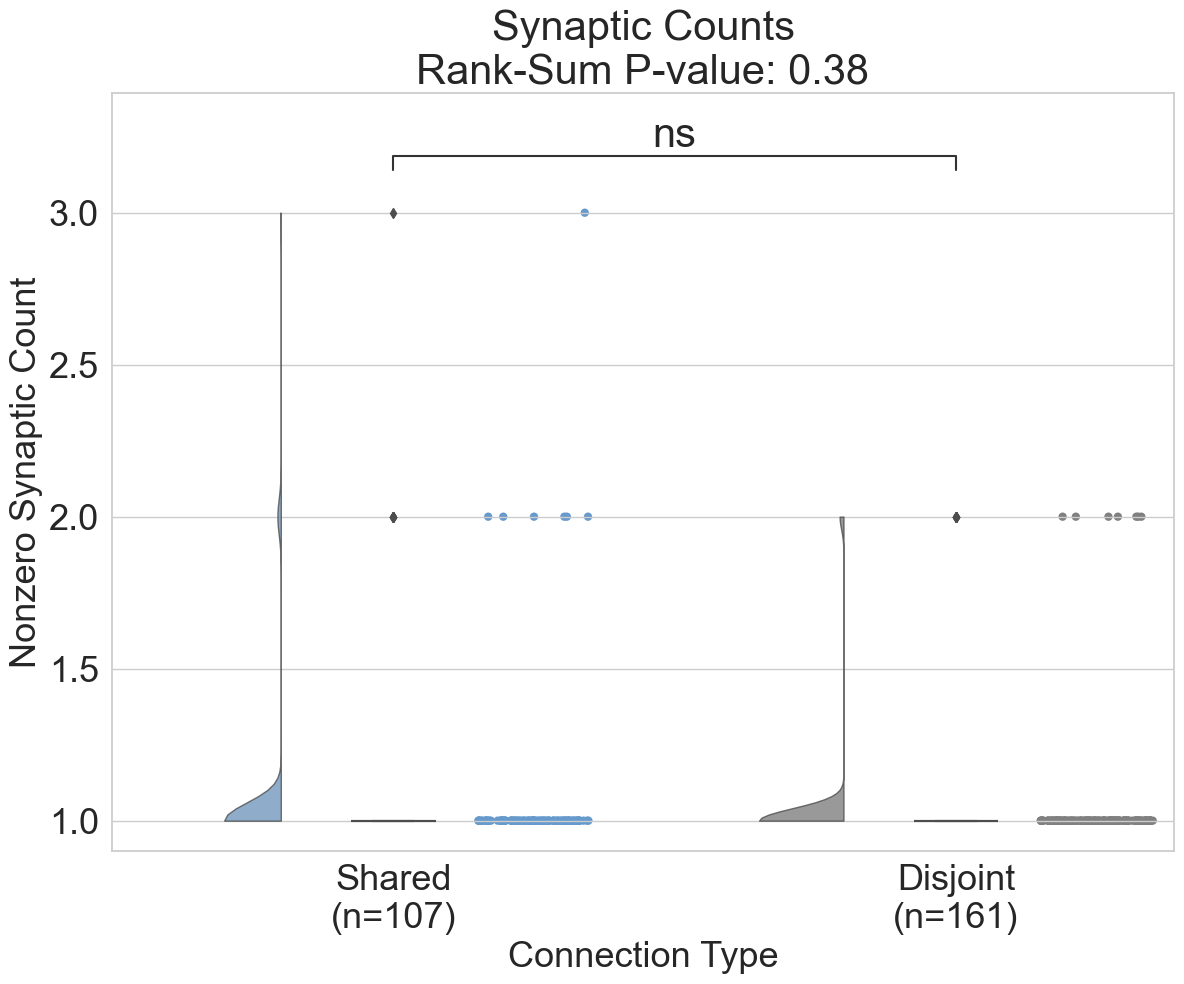

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


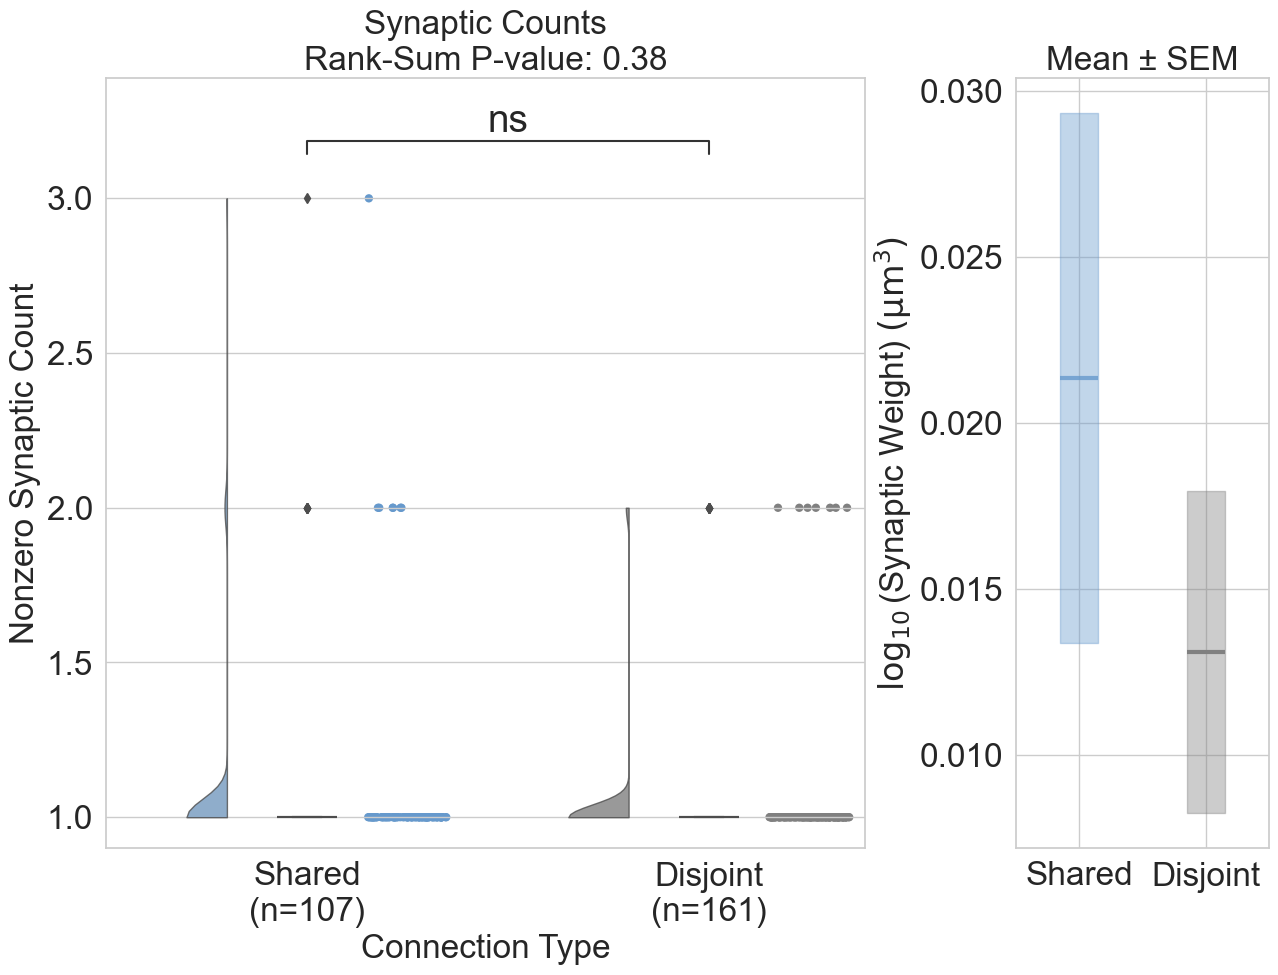

In [15]:
ranksum_signedrank_two_group_comparison(S_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3555, P-value: 0.3611


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnin


[UNPAIRED] Effect sizes (pos = 'greater')  n1=39, n2=53
  Test p-value: 0.274
  Shared median = 1, Disjoint median = 1

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.455, 0.595]   (δ=0.044 : CI [-0.090, 0.189])
    Cohen's d: 0.210 : CI [-0.267, 0.550]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.522 : CI [0.456, 0.596]   (δ=0.044 : CI [-0.089, 0.192])
    Cohen's d: 0.210 : CI [-0.231, 0.578]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 17.5, P-value: 0.2767

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=33
  Test p-value: 0.2767
  Median paired difference = 0

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : CI [0.439, 0.591]   (δ=0.030 : CI [-0.121, 0.182])
    Cohen's d: 0.129 : CI [-0.256, 0.394]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.515 : CI [0.424, 0.576]   (δ=0.030 : CI [-0.152, 0.152])
 

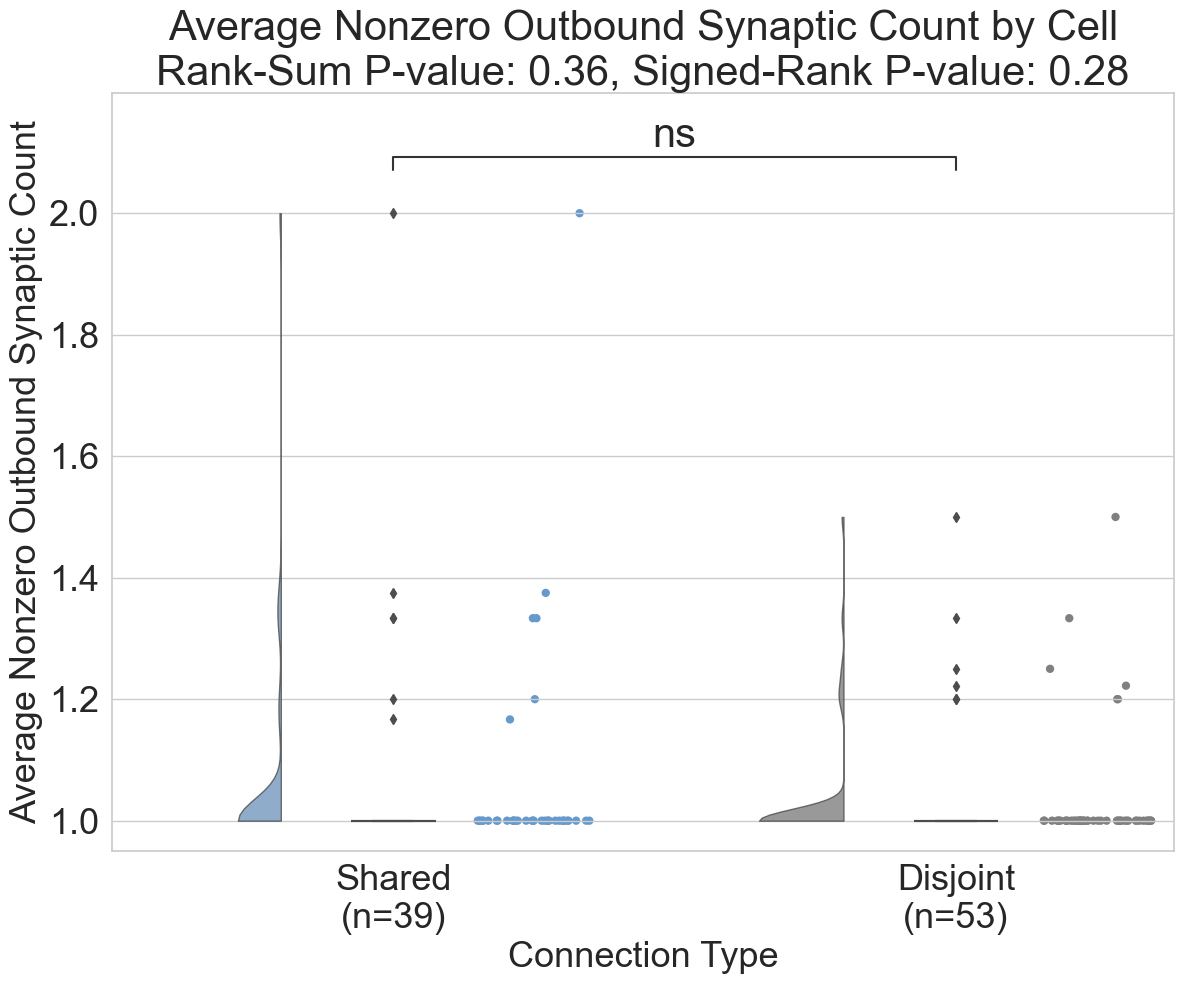

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


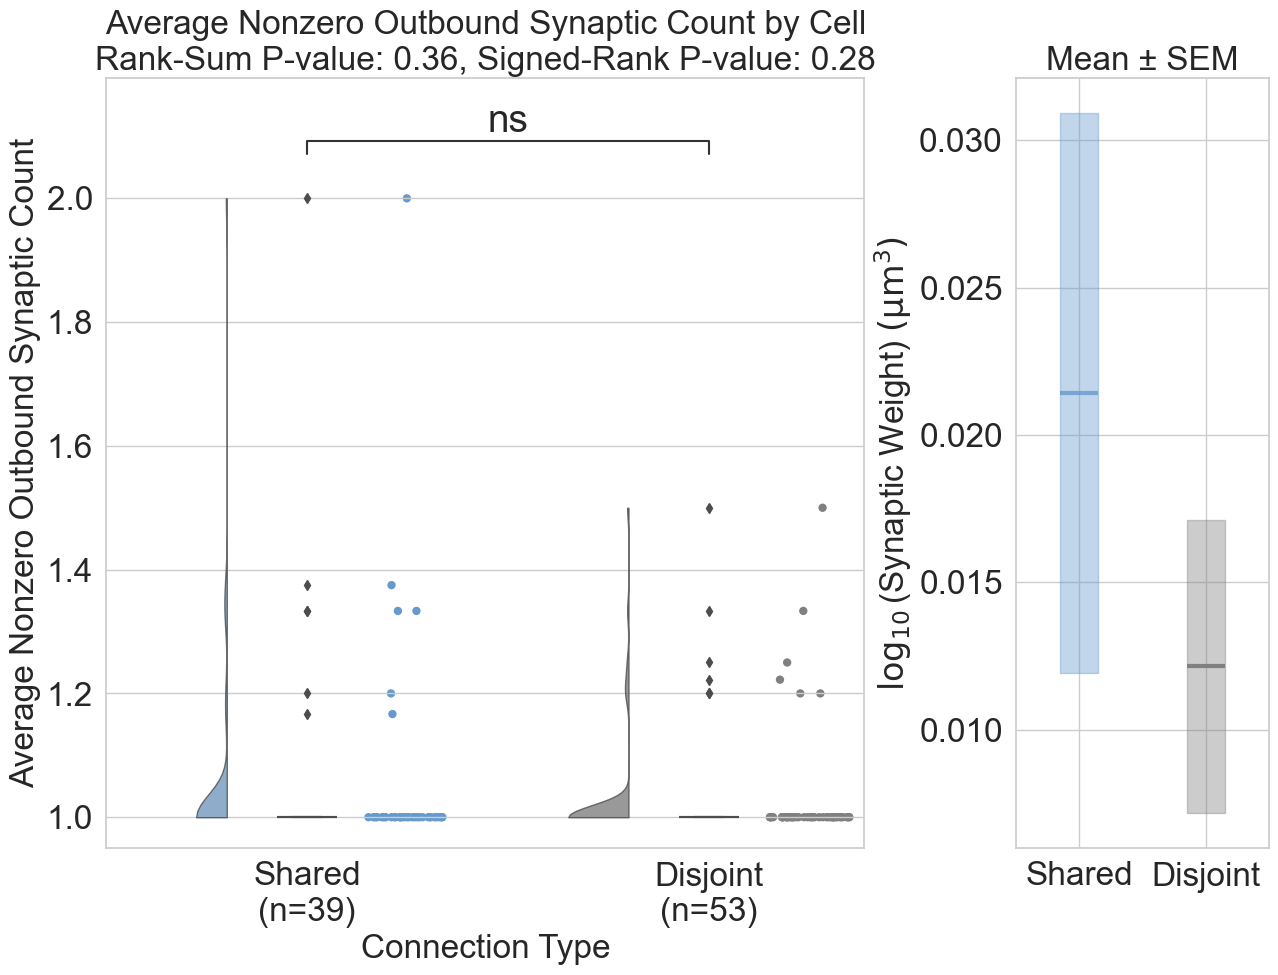

In [16]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.4394, P-value: 0.3302


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:131: RuntimeWarning: invalid value encountered in scalar multiply
  adj_al = stats.norm.cdf(z0 + (z0 + z_al) / (1 - a*(z0 + z_al)))
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\406515043.py:132: RuntimeWarning: invalid value encountered in scalar multiply
  adj_au = stats.norm.cdf(z0 + (z0 + z_au) / (1 - a*(z0 + z_au)))
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnin


[UNPAIRED] Effect sizes (pos = 'greater')  n1=71, n2=103
  Test p-value: 0.1684
  Shared median = 1, Disjoint median = 1

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.480, 0.563]   (δ=0.039 : CI [-0.040, 0.126])
    Cohen's d: 0.143 : CI [-0.195, 0.416]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.520 : CI [0.485, 0.571]   (δ=0.039 : CI [-0.030, 0.143])
    Cohen's d: 0.143 : CI [-0.147, 0.469]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 13, P-value: 0.2981

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=39
  Test p-value: 0.2981
  Median paired difference = 0

  Effect sizes with 95% CI (percentile):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : CI [0.462, 0.590]   (δ=0.051 : CI [-0.077, 0.179])
    Cohen's d: 0.105 : CI [-0.217, 0.362]

  Effect sizes with 95% CI (BCa):
    HL shift: 0 : CI [0, 0]
    PS:       0.526 : CI [0.462, 0.577]   (δ=0.051 : CI [-0.077, 0.154])
 

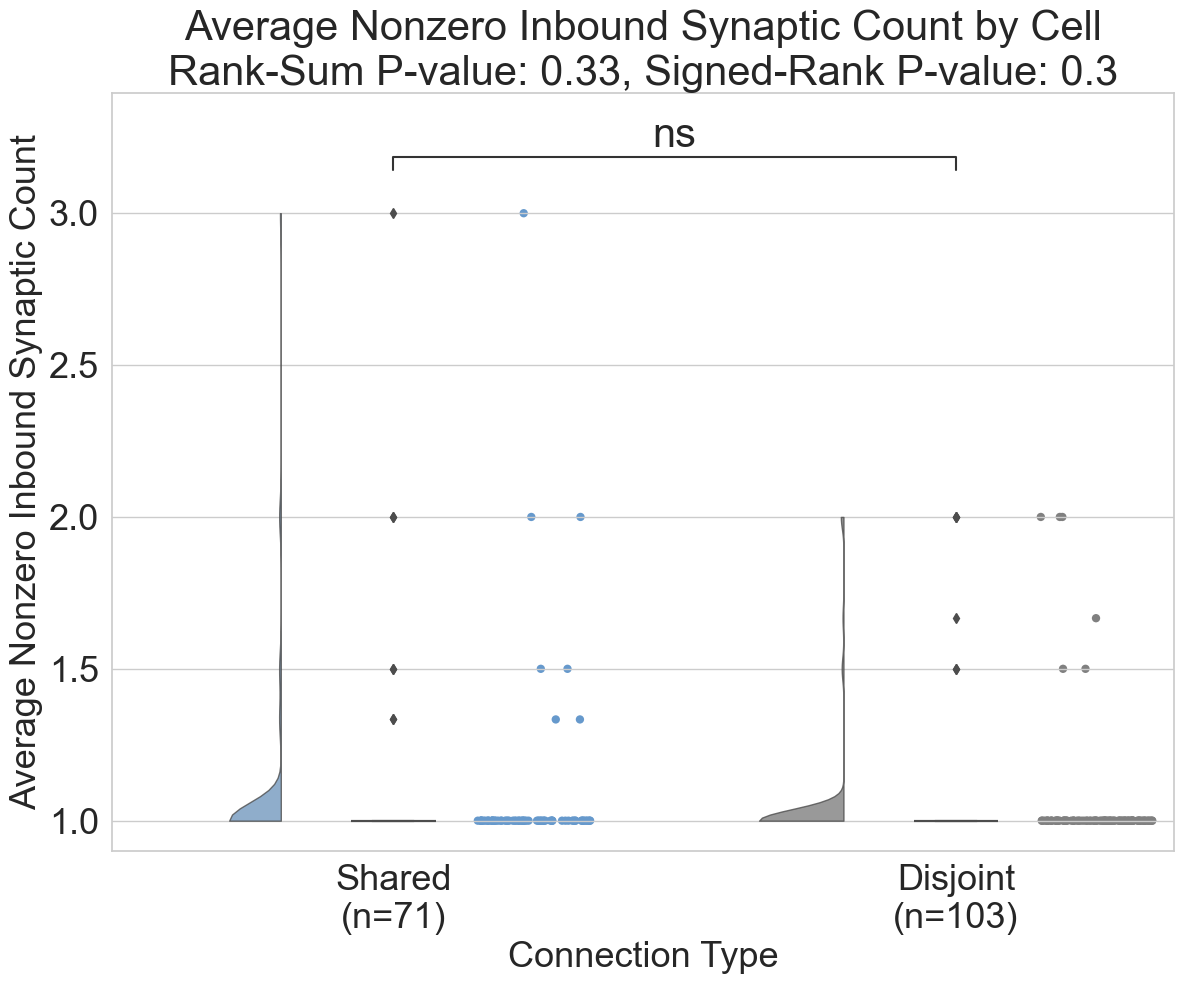

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


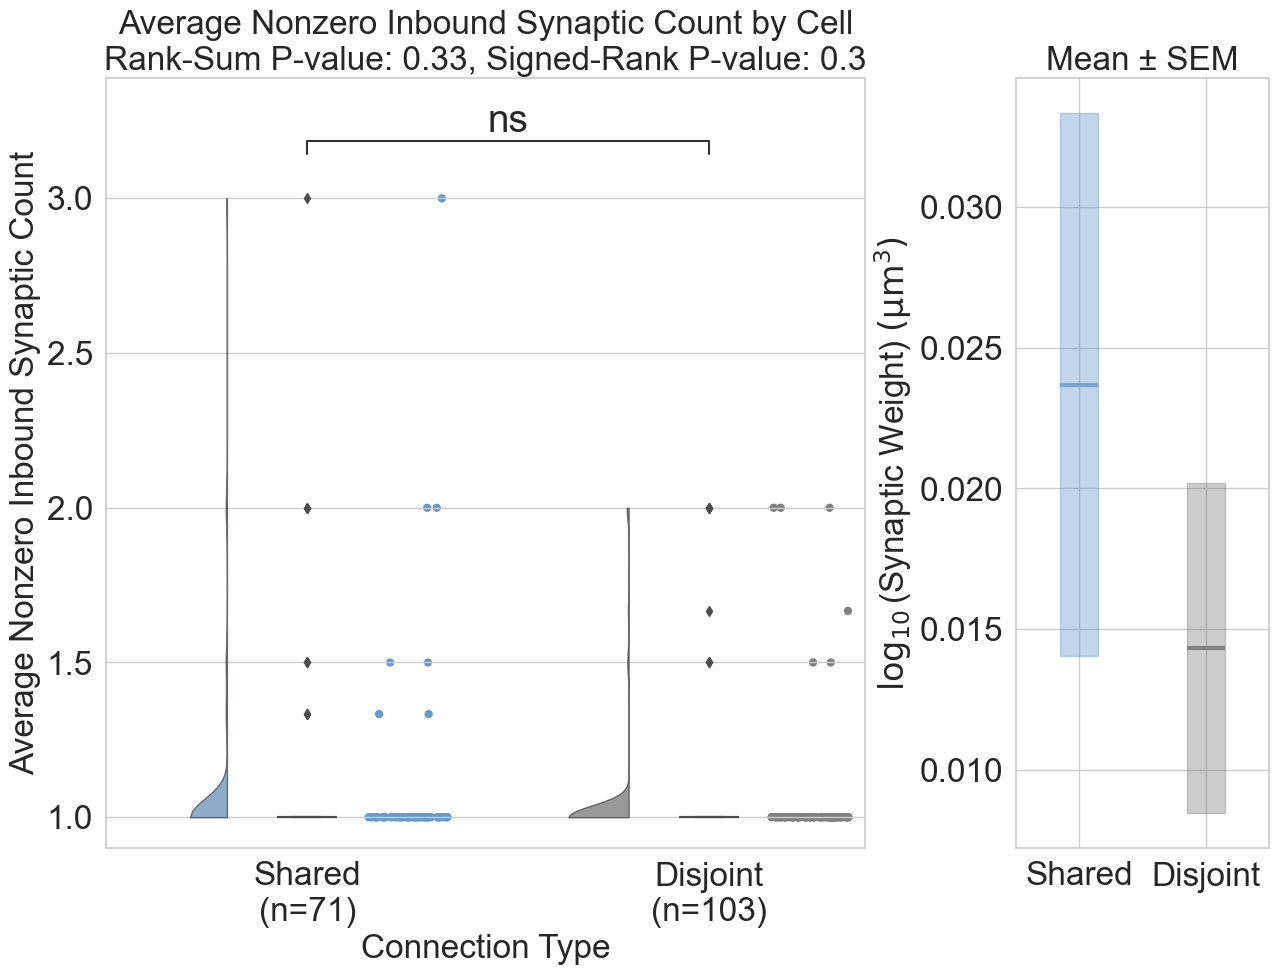

In [17]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

## Higher-Order Connectivity Analysis: Centrality

In [ ]:
def centrality_bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    *,
    B: int = 1_000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero: bool = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:

    rng = default_rng(seed)
    sign = _dir_from_alt(alternative)

    # ---------- build data ----------
    if paired:
        s, d, z = _paired_from_dict(comparison_dict)
        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]
        if z.size == 0:
            raise ValueError("No common keys for paired analysis after filtering.")
    else:
        s = np.array(comparison_dict["All A"])
        d = np.array(comparison_dict["No A"])
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis after filtering.")

    # ---------- point estimates ----------
    d_hat   = cohens_d(s, d, alternative=alternative, paired=paired)
    HL_hat  = hodges_lehmann(s, d, alternative=alternative, paired=paired,
                             max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=paired,
                                     eps=eps_tie, method=mw_method)

    # test (Wilcoxon or Mann–Whitney)
    if paired:
        alt = "greater" if sign > 0 else "less"
        sr = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)
        median_info = f"Median paired difference = {np.median(s - d):.6g}"
    else:
        alt = "greater" if sign > 0 else "less"
        mw = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)
        median_info = f"Shared median = {np.median(s):.6g}, Disjoint median = {np.median(d):.6g}"

    # ---------- bootstrap ----------
    if paired:
        n = s.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, size=n)
            sb, db = s[idx], d[idx]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b], delta_b[b] = A_b, del_b
    else:
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); ps_b = np.empty(B); delta_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]  = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b] = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                     max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b], delta_b[b] = A_b, del_b

    # ---------- jackknife for BCa ----------
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        try:
            jack_d    = _jackknife_stat(cohens_d,        s, d, paired=paired, alternative=alternative)
            jack_hl   = _jackknife_stat(hodges_lehmann,  s, d, paired=paired, alternative=alternative)
            jack_ps   = _jackknife_stat(lambda a,b,**kw: ps_and_delta(a,b,**kw)[0],
                                        s, d, paired=paired, alternative=alternative)
            jack_del  = 2.0*jack_ps - 1.0
        except Exception:
            jack_d = jack_hl = jack_ps = jack_del = np.array([])

    # ---------- percentile CIs ----------
    d_CI_pct     = _ci_wrapper(d_hat,   d_b,    np.array([]), alpha, method="percentile")
    hl_CI_pct    = _ci_wrapper(HL_hat,  hl_b,   np.array([]), alpha, method="percentile")
    ps_CI_pct    = _ci_wrapper(PS_hat,  ps_b,   np.array([]), alpha, method="percentile")
    delta_CI_pct = _ci_wrapper(delta_hat, delta_b, np.array([]), alpha, method="percentile")

    # ---------- BCa CIs ----------
    d_CI_bca     = _ci_wrapper(d_hat,   d_b,    jack_d,   alpha, method="bca")
    hl_CI_bca    = _ci_wrapper(HL_hat,  hl_b,   jack_hl,  alpha, method="bca")
    ps_CI_bca    = _ci_wrapper(PS_hat,  ps_b,   jack_ps,  alpha, method="bca")
    delta_CI_bca = _ci_wrapper(delta_hat, delta_b, jack_del, alpha, method="bca")

    # ---------- console output ----------
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"

    print(f"\n[{mode}] Effect sizes (pos = '{alternative}')  {n_info}")
    print(f"  Test p-value: {p_point:.4g}")
    print(f"  {median_info}")

    print("\n  Effect sizes with bootstrapped 95% CI (percentile):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_pct[0]:.6g}, {hl_CI_pct[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_pct[0]:.3f}, {ps_CI_pct[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_pct[0]:.3f}, {delta_CI_pct[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_pct[0]:.3f}, {d_CI_pct[1]:.3f}]")

    print("\n  Effect sizes with bootstrapped 95% CI (BCa):")
    print(f"    HL shift: {HL_hat:.6g} : CI [{hl_CI_bca[0]:.6g}, {hl_CI_bca[1]:.6g}]")
    print(f"    PS:       {PS_hat:.3f} : CI [{ps_CI_bca[0]:.3f}, {ps_CI_bca[1]:.3f}]   "
          f"(δ={delta_hat:.3f} : CI [{delta_CI_bca[0]:.3f}, {delta_CI_bca[1]:.3f}])")
    print(f"    Cohen's d: {d_hat:.3f} : CI [{d_CI_bca[0]:.3f}, {d_CI_bca[1]:.3f}]")

    # ---------- results dict ----------
    results = {
        "paired": paired,
        "alternative": alternative,
        "non_zero": non_zero,
        "B": B,
        "point": {"p_value": p_point, "d": float(d_hat), "HL": float(HL_hat),
                  "PS": float(PS_hat), "delta": float(delta_hat)},
        "CI95_percentile": {"d": d_CI_pct, "HL": hl_CI_pct, "PS": ps_CI_pct, "delta": delta_CI_pct},
        "CI95_bca": {"d": d_CI_bca, "HL": hl_CI_bca, "PS": ps_CI_bca, "delta": delta_CI_bca},
        "n": (len(s), len(d)) if not paired else (len(s),),
    }

    return results

def produce_centrality_plot(input_centrality_dict: dict,
                                     just_pyramidal=False,
                                     outdegree=False,
                                     indegree=False, 
                                     closeness=False, 
                                     betweenness=False,
                                     save=False,
                                     figure_name=None):
    """
    Produces a raincloud plot for centrality metrics.

    Parameters:
        input_centrality_dict (dict): Dictionary containing centrality values.
        just_pyramidal (bool): Whether to filter to pyramidal cells only.
        outdegree (bool): Whether to use outdegree centrality.
        indegree (bool): Whether to use indegree centrality.
        closeness (bool): Whether to use closeness centrality.
        betweenness (bool): Whether to use betweenness centrality.

    Returns:
        None
    """
    if outdegree and indegree:
        raise ValueError("Must either be working with outdegree or indegree.")
    if closeness and betweenness:
        raise ValueError("Must either be working with closeness or betweenness.")
    if (outdegree or indegree) and (closeness or betweenness):
        raise ValueError("Must either be working with directionality (indegree/outdegree) or higher-order (betweenness/closeness).")

    suffix = "of Co-Registered Cells"

    # Based on the connectome flags, set the correct y_label and plot title
    if outdegree:
        centrality_desc = "Outdegree_Centrality"
        suffix = "Outdegree Centrality " + suffix
        y_lab = "Outdegree Centrality"
    elif indegree:
        centrality_desc = "Indegree_Centrality"
        suffix = "Indegree Centrality " + suffix
        y_lab = "Indegree Centrality"
    elif closeness: 
        centrality_desc = "Closeness_Centrality"
        suffix = "Closeness Centrality " + suffix
        y_lab = "Closeness Centrality"
    elif betweenness:
        centrality_desc = "Betweenness_Centrality"
        suffix = "Betweenness Centrality " + suffix
        y_lab = "Betweenness Centrality"
    else:
        raise ValueError("Must Specify Degree")

    centrality_dict = {}
    for key in input_centrality_dict.keys():
        centrality_dict[key] = np.array(input_centrality_dict[key])

    all_arr = [centrality_dict['All A'], centrality_dict['No A']]
    result = stats.ranksums(centrality_dict['All A'], centrality_dict['No A'], 'greater')
    print(f"Rank-Sum Test (unpaired, All A > No A):\nStatistic: {result.statistic:.4g}, P-value: {result.pvalue:.4g}")
    centrality_bootstrap_effects_and_p(input_centrality_dict, alternative='greater')

    # Calculate sample sizes
    n_all_a = len(centrality_dict['All A'])
    n_no_a = len(centrality_dict['No A'])

    # Create a figure
    plt.figure(figsize=(12,10))
    sns.set_theme(style="whitegrid")

    # Prepare data for raincloud plot
    data = pd.DataFrame({
        "Values": np.concatenate(all_arr),
        "Group": [f"Assembly\n(n={n_all_a})"] * len(centrality_dict['All A']) + \
                 [f"Non-Assembly\n(n={n_no_a})"] * len(centrality_dict['No A'])
    })

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  # Adjust violin width
        alpha=0.8,  # Transparency of the cloud
        move=0.25,  # Adjust position of violins
        point_size = 6,
        orient="v"  # Horizontal orientation
    )

    # Set markings for significance
    y_labels = [f"Assembly\n(n={n_all_a})", f"Non-Assembly\n(n={n_no_a})"]
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([result.pvalue])
    annot.configure(text_format="star", loc="inside", fontsize=32)
    annot.annotate()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(32)

    # Add a multiline title to include the p-value, add y_label
    title = f'{suffix}\nRank-Sum P-value: {result.pvalue:.2g}'
    plt.title(title, size=32)
    plt.ylabel(y_lab, size=32)
    plt.xticks(fontsize=32)  # Adjust size of xticks
    plt.yticks(fontsize=32)  # Adjust size of yticks
    plt.xlabel("Assigned Assembly Status", size=32)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

### All Cells Proofread Connectome

In [25]:
# Pull Data from LSMM Data
with open('all_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:30<00:00, 1516.65it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:33<00:00, 1470.26it/s]


In [26]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [27]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

In [28]:
# Save all produced sets
save_folder = 'master_freeze_produced_sets/centrality/all_cell_connectome_'
with open(f"{save_folder}indegree_centrality.pkl", "wb") as f:
    pickle.dump(indegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}outdegree_centrality.pkl", "wb") as f:
    pickle.dump(outdegree_centrality_by_grouped_membership, f)
with open(f"{save_folder}closeness_centrality.pkl", "wb") as f:
    pickle.dump(closeness_centrality_by_grouped_membership, f)
with open(f"{save_folder}betweenness_centrality.pkl", "wb") as f:
    pickle.dump(betweenness_centrality_by_grouped_membership, f)

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.86, P-value: 0.03146

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.03181
  Shared median = 0.0481786, Disjoint median = 0.0434783

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00822562 : CI [0, 0.0176263]
    PS:       0.642 : CI [0.497, 0.771]   (δ=0.284 : CI [-0.006, 0.542])
    Cohen's d: 0.544 : CI [0.118, 0.986]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00822562 : CI [-0.00117509, 0.0152761]
    PS:       0.642 : CI [0.494, 0.768]   (δ=0.284 : CI [-0.013, 0.536])
    Cohen's d: 0.544 : CI [0.110, 0.972]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.146e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


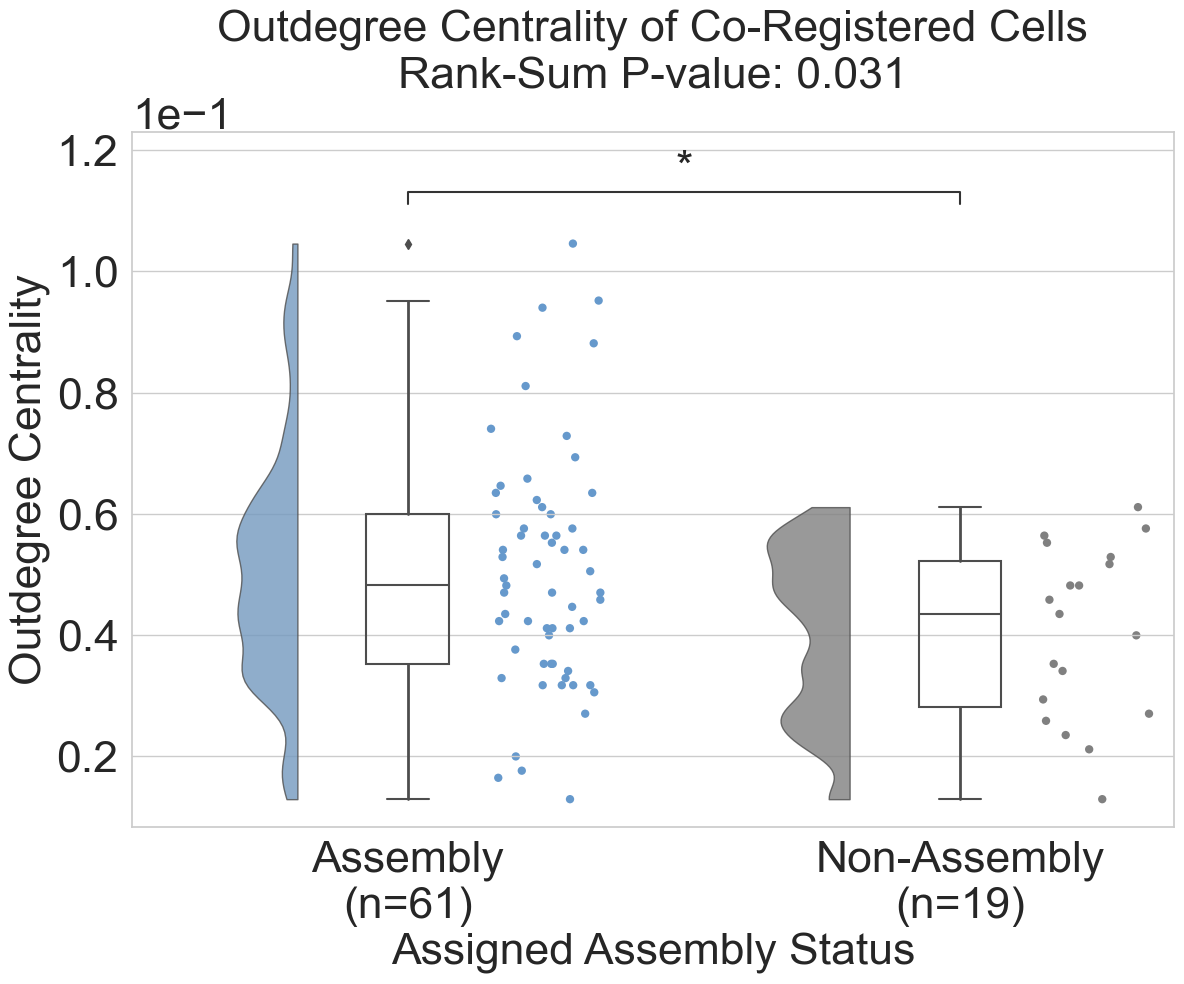

In [29]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True, save=True, figure_name='Outdegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.747, P-value: 0.04034

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.04078
  Shared median = 0.0857814, Disjoint median = 0.0740306

  Effect sizes with 95% CI (percentile):
    HL shift: 0.0141011 : CI [-0.00117509, 0.0282021]
    PS:       0.633 : CI [0.488, 0.769]   (δ=0.267 : CI [-0.024, 0.538])
    Cohen's d: 0.491 : CI [-0.010, 1.040]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.0141011 : CI [-0.00352526, 0.027027]
    PS:       0.633 : CI [0.459, 0.753]   (δ=0.267 : CI [-0.082, 0.506])
    Cohen's d: 0.491 : CI [-0.088, 0.963]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:4.034e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


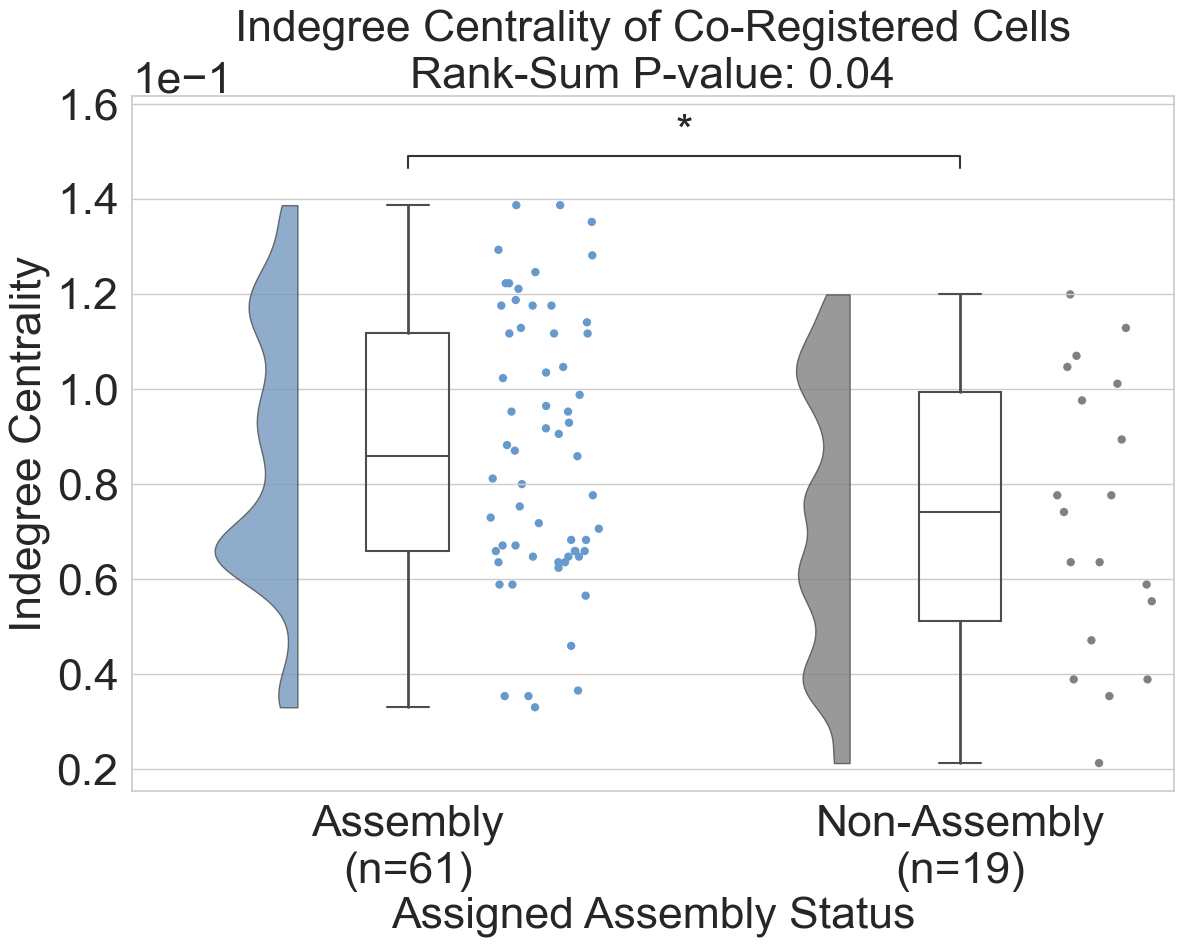

In [30]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True, save=True, figure_name='Indegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 2.719, P-value: 0.003273

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.00333
  Shared median = 0.000274487, Disjoint median = 0.000159944

  Effect sizes with 95% CI (percentile):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168546]
    PS:       0.708 : CI [0.563, 0.838]   (δ=0.415 : CI [0.125, 0.676])
    Cohen's d: 0.635 : CI [0.221, 1.023]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.000106312 : CI [3.11444e-05, 0.000168535]
    PS:       0.708 : CI [0.544, 0.821]   (δ=0.415 : CI [0.087, 0.641])
    Cohen's d: 0.635 : CI [0.087, 0.955]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.273e-03


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


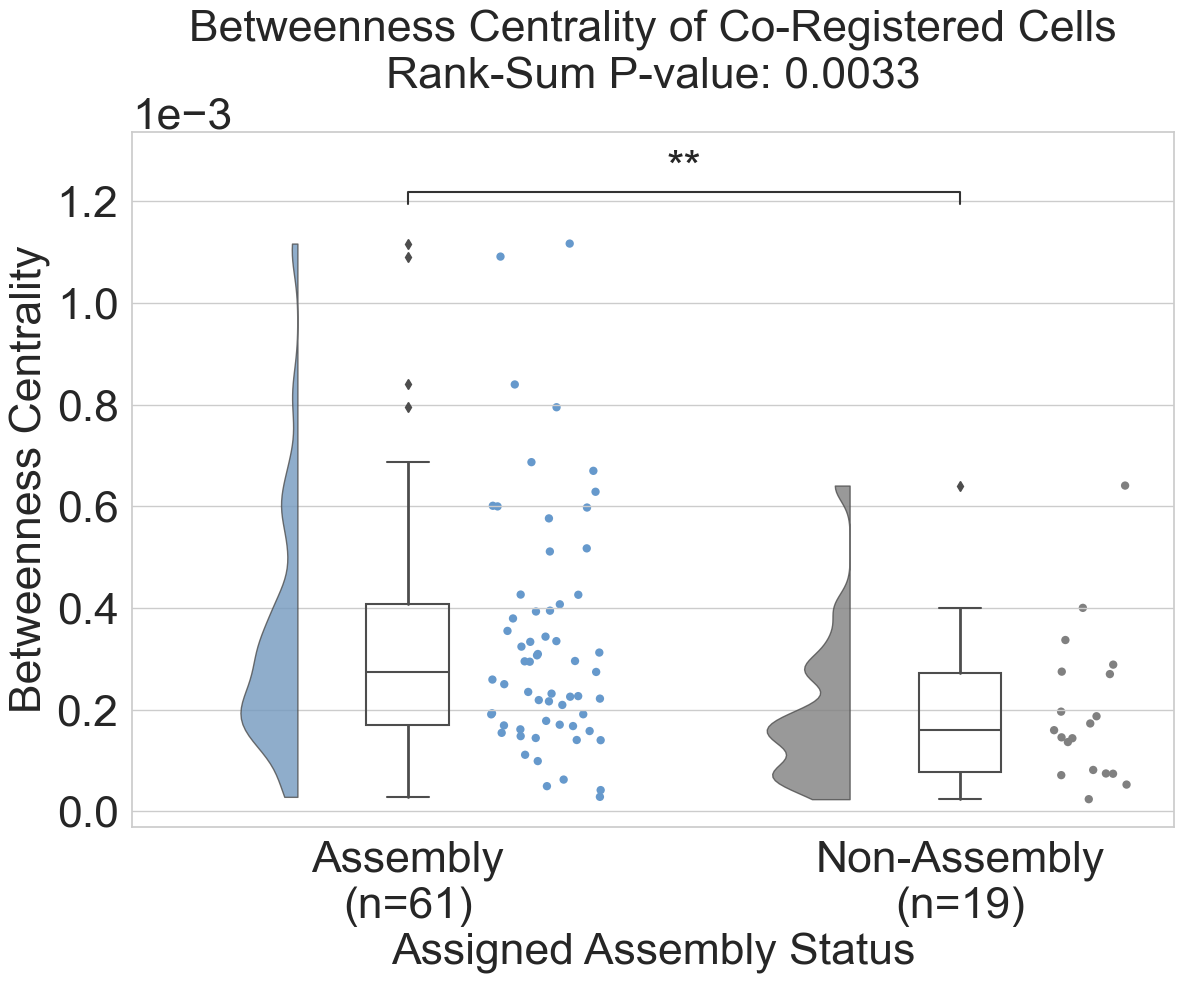

In [31]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.413, P-value: 0.07879

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.07961
  Shared median = 0.491889, Disjoint median = 0.48459

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00577382 : CI [-0.00209518, 0.0154273]
    PS:       0.608 : CI [0.462, 0.745]   (δ=0.216 : CI [-0.075, 0.490])
    Cohen's d: 0.391 : CI [-0.119, 0.945]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00577382 : CI [-0.00233917, 0.0142508]
    PS:       0.608 : CI [0.459, 0.738]   (δ=0.216 : CI [-0.083, 0.475])
    Cohen's d: 0.391 : CI [-0.119, 0.945]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:7.879e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


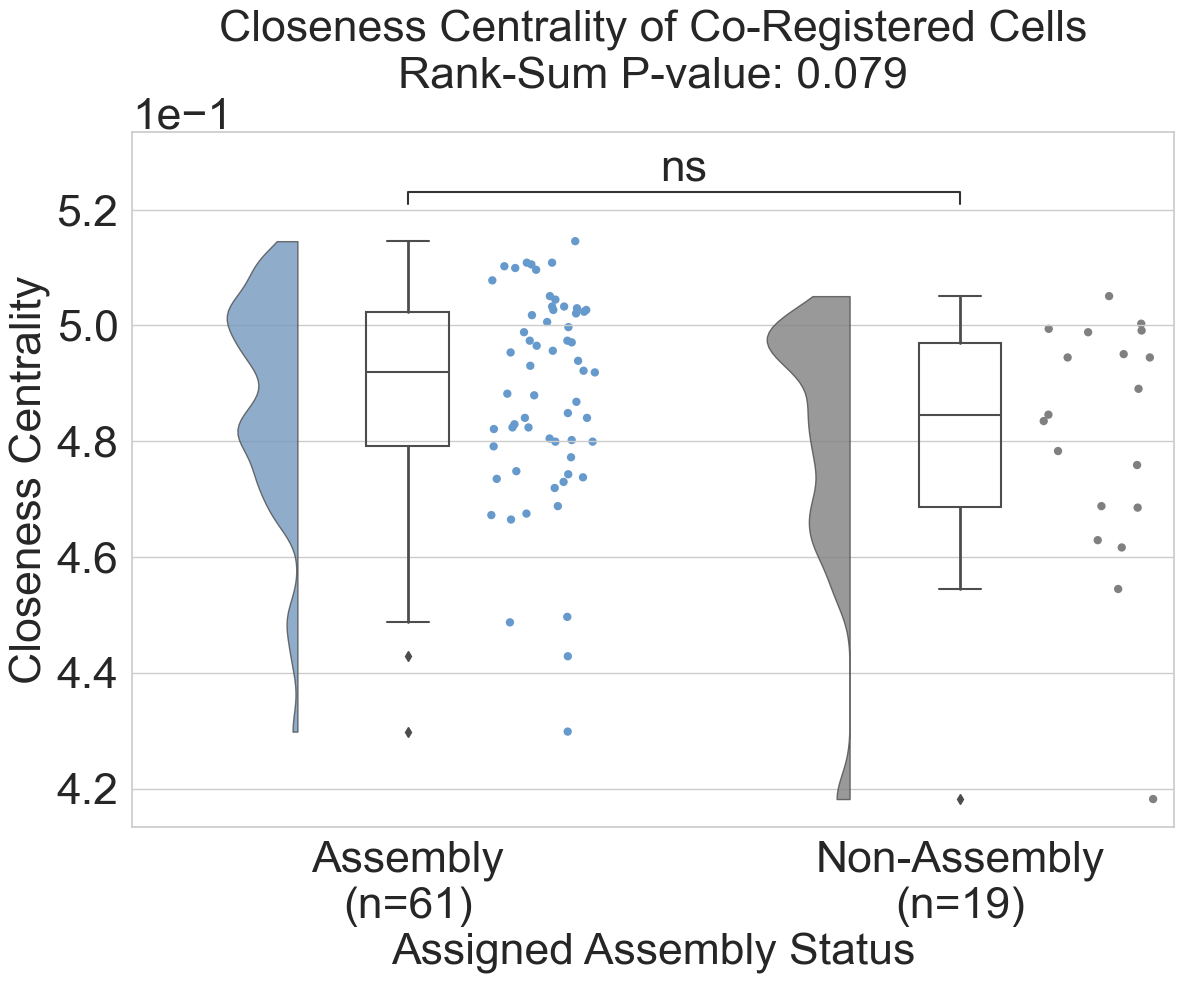

In [32]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

### Pyramidal Cells Proofread Connectome

In [33]:
# Pull Data from LSMM Data
with open('pyr_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459
Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 3220.57it/s]


Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 2981.41it/s]


In [34]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [35]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.899, P-value: 0.02876

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.02868
  Shared median = 0.0174672, Disjoint median = 0.0152838

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00436681 : CI [0, 0.00873362]
    PS:       0.645 : CI [0.515, 0.760]   (δ=0.290 : CI [0.030, 0.520])
    Cohen's d: 0.571 : CI [0.277, 0.851]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00436681 : CI [0, 0.00655022]
    PS:       0.645 : CI [0.516, 0.761]   (δ=0.290 : CI [0.032, 0.523])
    Cohen's d: 0.571 : CI [0.277, 0.851]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.876e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


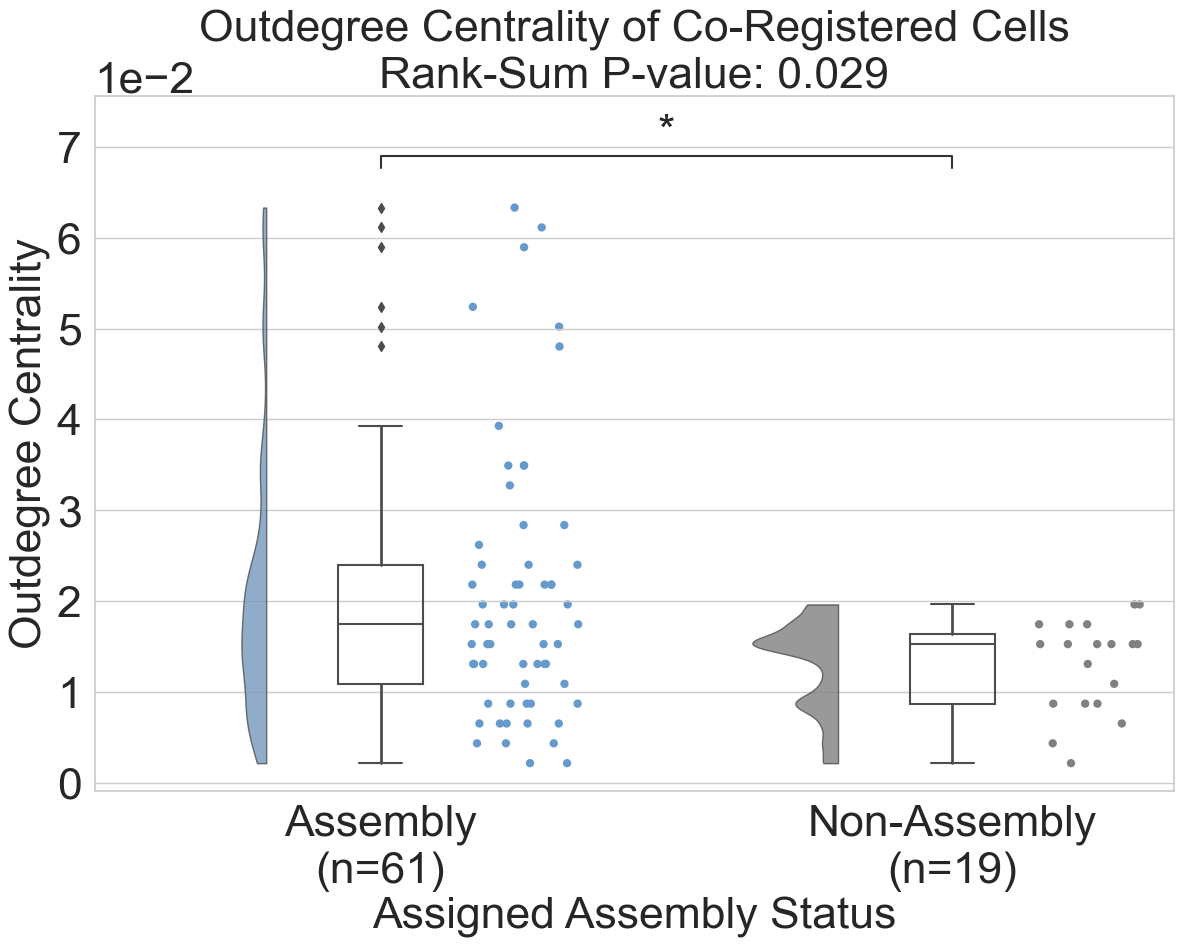

In [36]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Outdegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.538, P-value: 0.06207

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.062
  Shared median = 0.0131004, Disjoint median = 0.010917

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00218341 : CI [0, 0.00873362]
    PS:       0.617 : CI [0.466, 0.749]   (δ=0.235 : CI [-0.067, 0.498])
    Cohen's d: 0.393 : CI [-0.086, 0.888]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00218341 : CI [-0.00218341, 0.00655022]
    PS:       0.617 : CI [0.462, 0.742]   (δ=0.235 : CI [-0.075, 0.484])
    Cohen's d: 0.393 : CI [-0.261, 0.795]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:6.207e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


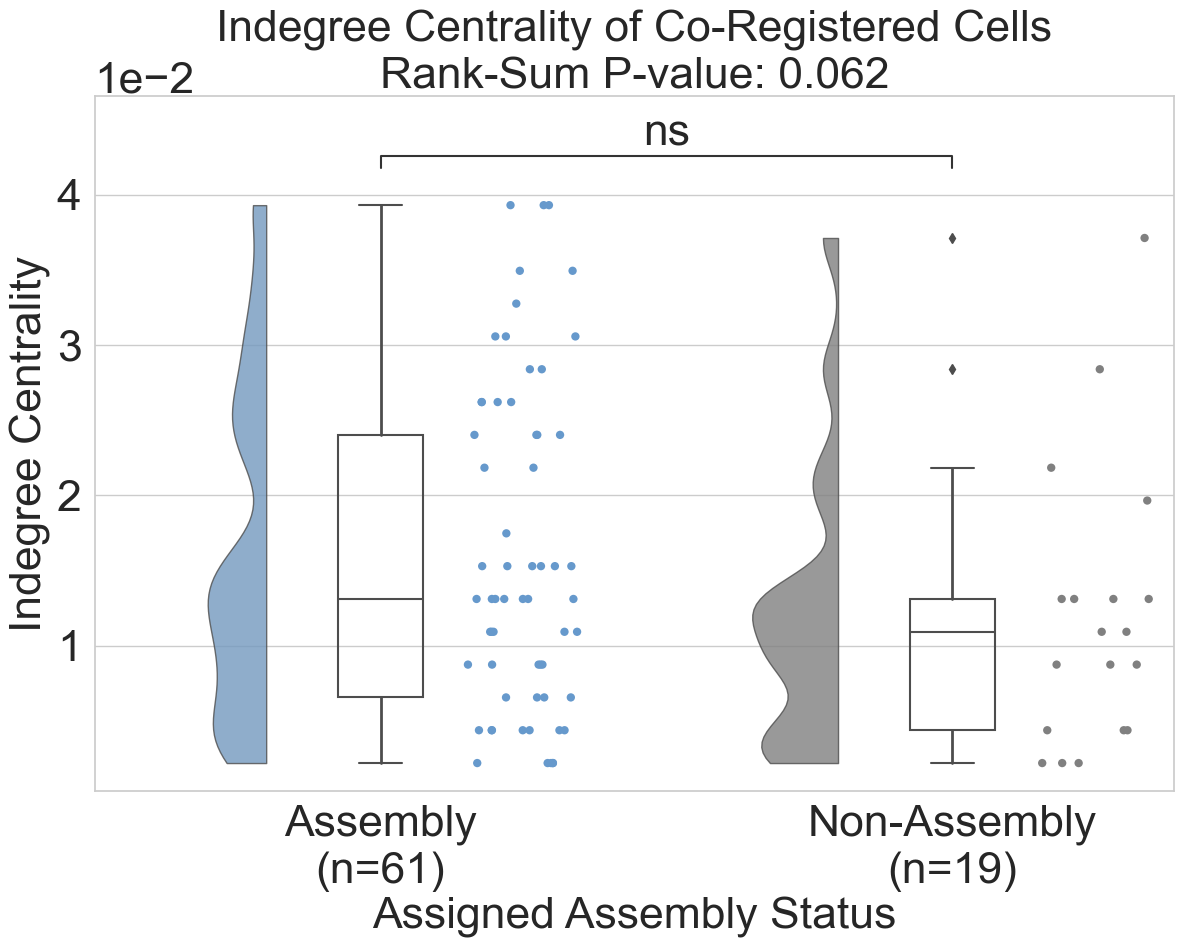

In [37]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Indegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.894, P-value: 0.02913

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.02951
  Shared median = 0.00324451, Disjoint median = 0.00199345

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00106893 : CI [1.28675e-05, 0.00215889]
    PS:       0.645 : CI [0.500, 0.779]   (δ=0.289 : CI [0.001, 0.558])
    Cohen's d: 0.477 : CI [0.143, 0.765]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00106893 : CI [-6.21082e-05, 0.00208542]
    PS:       0.645 : CI [0.494, 0.771]   (δ=0.289 : CI [-0.011, 0.543])
    Cohen's d: 0.477 : CI [0.064, 0.720]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.913e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


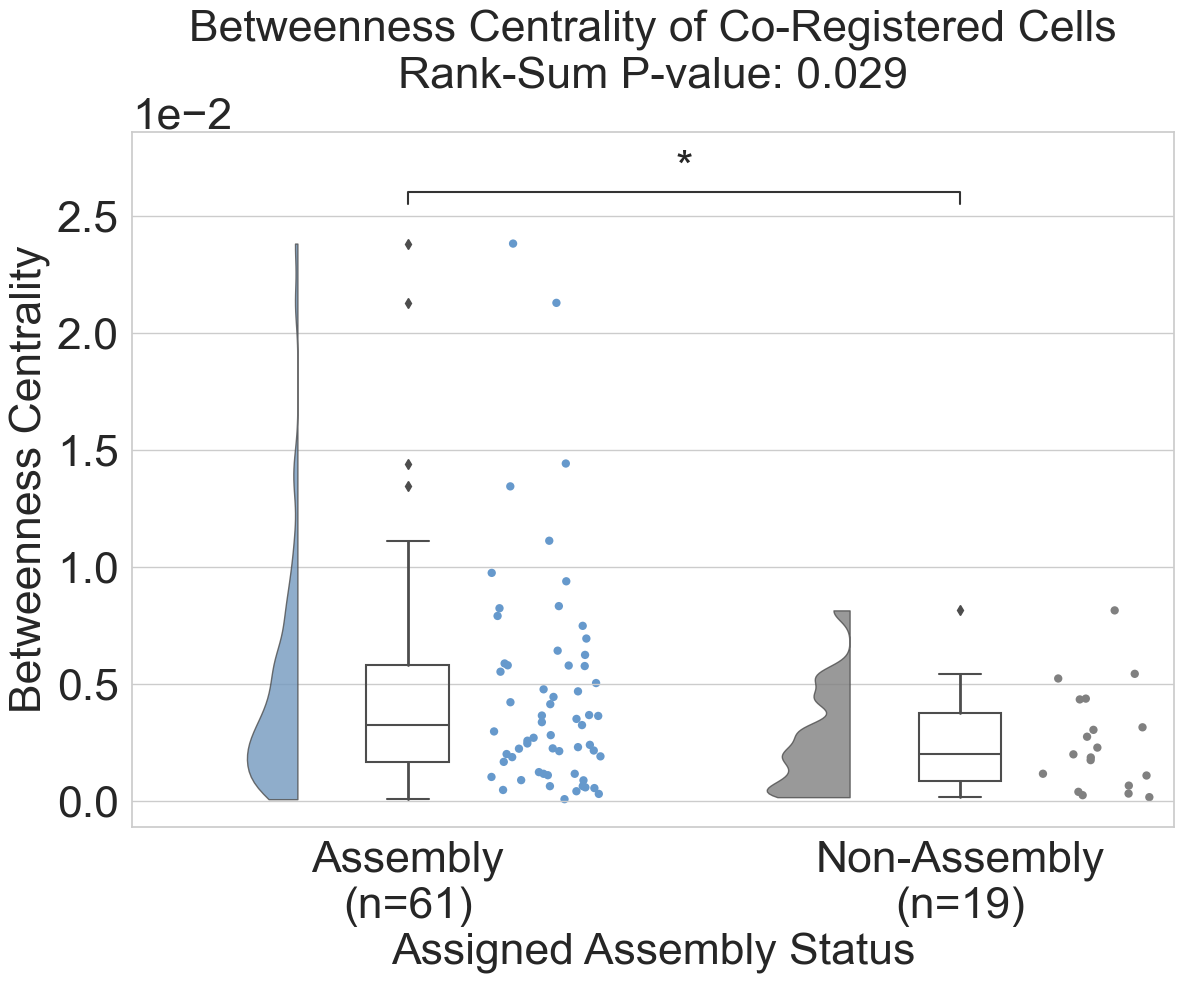

In [38]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 0.8423, P-value: 0.1998

[UNPAIRED] Effect sizes (pos = 'greater')  n1=61, n2=19
  Test p-value: 0.2014
  Shared median = 0.276667, Disjoint median = 0.270241

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00773406 : CI [-0.00986201, 0.0285218]
    PS:       0.564 : CI [0.417, 0.705]   (δ=0.129 : CI [-0.167, 0.411])
    Cohen's d: 0.132 : CI [-0.275, 0.705]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.00773406 : CI [-0.01013, 0.0283854]
    PS:       0.564 : CI [0.408, 0.698]   (δ=0.129 : CI [-0.184, 0.395])
    Cohen's d: 0.132 : CI [-0.336, 0.641]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:1.998e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


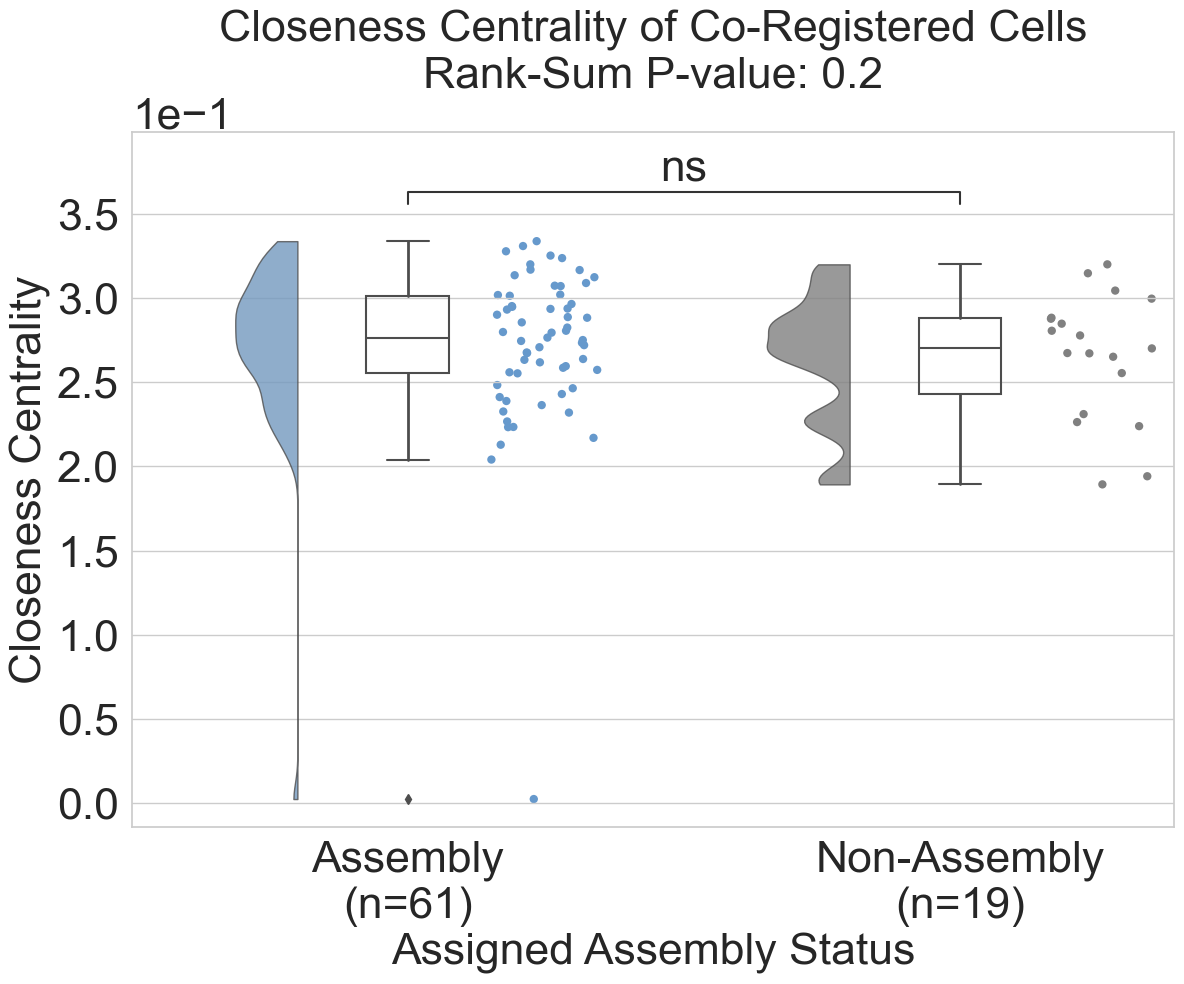

In [39]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

# Chains: Standard

In [40]:
with open('all_cells_proofread_connectome.json') as f:
    loaded_json = json.load(f)
my_data = LSMMData.LSMMData(loaded_json)
# with open('pyr_rect.data', 'wb') as f:
#     pickle.dump(my_data, f)

data_a = my_data.data
params_a = my_data.params
dirs_a = my_data.dirs
mappings_a = my_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:30<00:00, 1517.10it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:46<00:00, 1288.16it/s]


In [41]:
# Make a graph
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index

synapse_table = data_a['structural']['synapse']
# adjacency_matrix = data_a['structural']['binary_connectome']
binary_connectome = data_a['structural']['binary_connectome']

index_to_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]

summed_size_connectome = data_a['structural']['summed_size_connectome']
summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_root_id,
    columns=index_to_root_id
)

pyr_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)
pyr_graph = nx.relabel_nodes(pyr_graph, {i: index_to_root_id[i] for i in range(len(index_to_root_id))})

# Or uncomment below to generate new motif analysis results (Can take quite a while on larger graphs)
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= pyr_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

### Pool necessary Data
chain_count_string_array = ['pyr_cell_2chain']
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()
no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']
pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))

assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]

# Filter cell tables to only assembly cells (including 'No A')
assembly_cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
assembly_post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

assembly_pre_root_ids = set(assembly_cell_table['pt_root_id'].values)
assembly_post_root_ids = set(assembly_post_cell_table['pt_root_id'].values)
all_root_ids = assembly_pre_root_ids | assembly_post_root_ids

100%|██████████| 6052393/6052393 [00:05<00:00, 1168035.75it/s]


In [42]:
# Initialize dictionaries to store weights and binary connectivity
W_chain_excitatory = {}
W_chain_inhibitory = {}
B_chain_excitatory = {}
B_chain_inhibitory = {}

# Define all potential (pre-cell, post-cell) pairs with excitatory and inhibitory chain types
for j in all_root_ids:
    for i in all_root_ids:
        if j != i:  # Exclude autapses
            W_chain_excitatory[(j, i)] = 0
            W_chain_inhibitory[(j, i)] = 0
            B_chain_excitatory[(j, i)] = 0
            B_chain_inhibitory[(j, i)] = 0

pt_root_id_to_classification = cell_table.set_index('pt_root_id')['classification_system'].to_dict()

# Process each row in `two_chain_results_array` to populate weights and binary connectivity
for _, row in enumerate(two_chain_results_array):
    pre_cell, mid_cell, post_cell = row  # j: pre-cell, k: middle cell, i: post-cell
    if pre_cell in all_root_ids and post_cell in all_root_ids:
    # Determine chain type (excitatory if middle cell is in excitatory set, else inhibitory)
        if pt_root_id_to_classification[mid_cell] == 'inhibitory':
            W_chain = W_chain_inhibitory
            B_chain = B_chain_inhibitory
        elif pt_root_id_to_classification[mid_cell] == 'excitatory':
            W_chain = W_chain_excitatory
            B_chain = B_chain_excitatory
    # Get synapse weights for connections j -> k and k -> i
        w_jk = summed_size_connectome_df.loc[pre_cell, mid_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers
        w_ki = summed_size_connectome_df.loc[mid_cell, post_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers
    
    # Updates weights and binary connectivity
        W_chain[(pre_cell, post_cell)] += (w_jk * w_ki)
        B_chain[(pre_cell, post_cell)] = 1

In [43]:
## PARIWISE NONZERO PSD and CONNECTION PROBABILITY BY CONNECTION TYPE
# Aggregate nonzero pairs and calculate connectivity probabilities by connection type
W_chain_nonzero_pairwise_excitatory = {}
W_chain_nonzero_pairwise_inhibitory = {}
B_chain_pairwise_excitatory = {}
B_chain_pairwise_inhibitory = {}

for cond_function in comparison_functions:
    # Initialize dictionaries per connection type
    W_chain_nonzero_pairwise_excitatory[cond_function.__name__] = {}
    W_chain_nonzero_pairwise_inhibitory[cond_function.__name__] = {}
    B_chain_pairwise_excitatory[cond_function.__name__] = {}
    B_chain_pairwise_inhibitory[cond_function.__name__] = {}

    # Process all (j, i) pairs from excitatory/inhibitory dictionaries
    for (j, i) in W_chain_excitatory.keys():
        if cond_function(j, i, A):
            # Set binary connectivity for each connection type
            B_chain_pairwise_excitatory[cond_function.__name__][(j, i)] = 1 if W_chain_excitatory[(j, i)] > 0 else 0
            B_chain_pairwise_inhibitory[cond_function.__name__][(j, i)] = 1 if W_chain_inhibitory[(j, i)] > 0 else 0
            
            # Store only nonzero weights
            if W_chain_excitatory[(j, i)] > 0:
                W_chain_nonzero_pairwise_excitatory[cond_function.__name__][(j, i)] = W_chain_excitatory[(j, i)]
            if W_chain_inhibitory[(j, i)] > 0:
                W_chain_nonzero_pairwise_inhibitory[cond_function.__name__][(j, i)] = W_chain_inhibitory[(j, i)]


## ADD IN NORMALIZATION BY # POTENTIAL CONNECTIONS
## Inbound, Outbound Collections
from collections import Counter

classification_map = cell_table.set_index('connectome_index')['classification_system'].to_dict() # Map to tell us if its Excitatory or Inhibitory 
backup_assembly_pre_root_ids = assembly_pre_root_ids
backup_assembly_post_root_ids = assembly_post_root_ids
classification_counts = Counter(classification_map.values())

num_excitatory = classification_counts.get('excitatory', 0)
num_inhibitory = classification_counts.get('inhibitory', 0)
# Aggregate chain weights and connectivity for outbound and inbound paths
W_nonzero_chain_out_excitatory = {}
W_nonzero_chain_out_inhibitory = {}
W_nonzero_chain_in_excitatory = {}
W_nonzero_chain_in_inhibitory = {}
B_chain_out_excitatory = {}
B_chain_out_inhibitory = {}
B_chain_in_excitatory = {}
B_chain_in_inhibitory = {}

# Iterate through connection types in C (e.g., shared, disjoint)
for connection_type in comparison_functions:
    # Initialize per connection type dictionaries
    W_nonzero_chain_out_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_out_inhibitory[connection_type.__name__] = {}
    W_nonzero_chain_in_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_in_inhibitory[connection_type.__name__] = {}
    B_chain_out_excitatory[connection_type.__name__] = {}
    B_chain_out_inhibitory[connection_type.__name__] = {}
    B_chain_in_excitatory[connection_type.__name__] = {}
    B_chain_in_inhibitory[connection_type.__name__] = {}
    # Outbound analysis (from pre-cell j to post-cell i through middle cell k)
    for j in all_root_ids:
        potential_partners_out = {i for i in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_out:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_out)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_out)
            for i in potential_partners_out:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_out_excitatory[connection_type.__name__][j] = sum_weights_excitatory / realized_chains_count_excitatory
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_out_inhibitory[connection_type.__name__][j] = sum_weights_inhibitory / realized_chains_count_inhibitory

            # Calculate binary connectivity only if there are potential partners
            B_chain_out_excitatory[connection_type.__name__][j] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_out) > 0 else 0
            B_chain_out_inhibitory[connection_type.__name__][j] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_out) > 0 else 0
    
    for i in all_root_ids:
        potential_partners_in = {j for j in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_in:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_in)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_in)
            for j in potential_partners_in:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_in_excitatory[connection_type.__name__][i] = sum_weights_excitatory / realized_chains_count_excitatory
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_in_inhibitory[connection_type.__name__][i] = sum_weights_inhibitory / realized_chains_count_inhibitory

            # Calculate binary connectivity only if there are potential partners
            B_chain_in_excitatory[connection_type.__name__][i] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_in) > 0 else 0
            B_chain_in_inhibitory[connection_type.__name__][i] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_in) > 0 else 0

In [44]:
# Save all produced sets
save_folder = 'master_freeze_produced_sets/chain_connections/'
with open(f"{save_folder}W_chain_nonzero_pairwise_excitatory.pkl", "wb") as f:
    pickle.dump(W_chain_nonzero_pairwise_excitatory, f)
with open(f"{save_folder}W_chain_nonzero_pairwise_inhibitory.pkl", "wb") as f:
    pickle.dump(W_chain_nonzero_pairwise_inhibitory, f)
with open(f"{save_folder}B_chain_pairwise_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_pairwise_excitatory, f)
with open(f"{save_folder}B_chain_pairwise_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_pairwise_inhibitory, f)
with open(f"{save_folder}W_nonzero_chain_out_excitatory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_out_excitatory, f)
with open(f"{save_folder}W_nonzero_chain_out_inhibitory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_out_inhibitory, f)
with open(f"{save_folder}W_nonzero_chain_in_excitatory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_in_excitatory, f)
with open(f"{save_folder}W_nonzero_chain_in_inhibitory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_in_inhibitory, f)
with open(f"{save_folder}B_chain_out_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_out_excitatory, f)
with open(f"{save_folder}B_chain_out_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_out_inhibitory, f)
with open(f"{save_folder}B_chain_in_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_in_excitatory, f)
with open(f"{save_folder}B_chain_in_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_in_inhibitory, f)

# plots

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.6376, P-value: 0.2619

[UNPAIRED] Effect sizes (pos = 'less')  n1=60, n2=61
  Test p-value: 0.2627
  Shared median = 4.20441e+06, Disjoint median = 4.21068e+06

  Effect sizes with 95% CI (percentile):
    HL shift: 124573 : CI [-245348, 485467]
    PS:       0.534 : CI [0.432, 0.634]   (δ=0.067 : CI [-0.136, 0.267])
    Cohen's d: 0.127 : CI [-0.229, 0.480]

  Effect sizes with 95% CI (BCa):
    HL shift: 124573 : CI [-255639, 482868]
    PS:       0.534 : CI [0.431, 0.633]   (δ=0.067 : CI [-0.137, 0.266])
    Cohen's d: 0.127 : CI [-0.232, 0.474]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 606, P-value: 0.01146

[PAIRED] Effect sizes (pos = 'less')  n_pairs=60
  Test p-value: 0.01146
  Median paired difference = -134369

  Effect sizes with 95% CI (percentile):
    HL shift: 134369 : CI [-23351.2, 297052]
    PS:       0.600 : CI [0.483, 0.733]   (δ=0.200 : CI [-0.033, 0.467])
    Cohen's d: 0.3

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


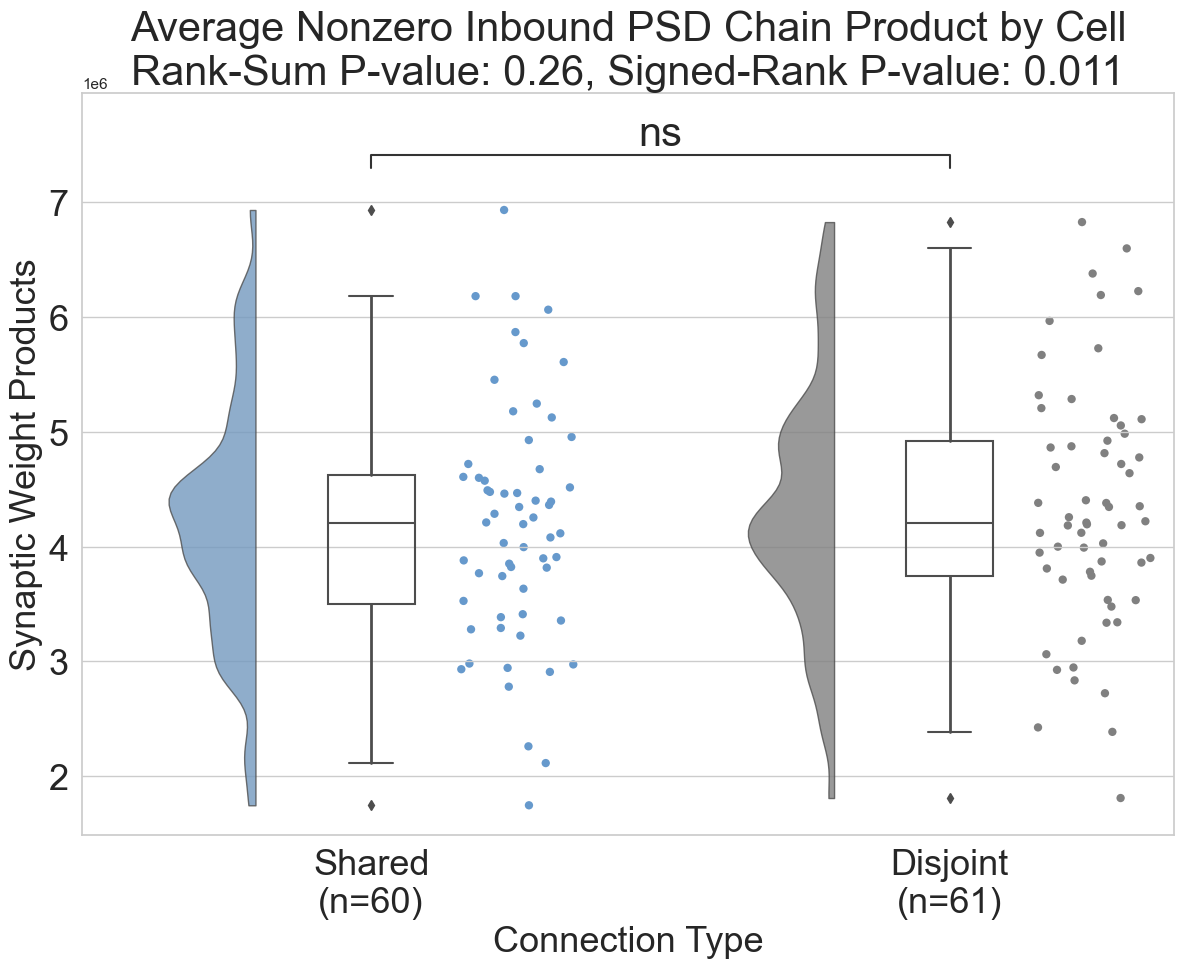

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:2.619e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


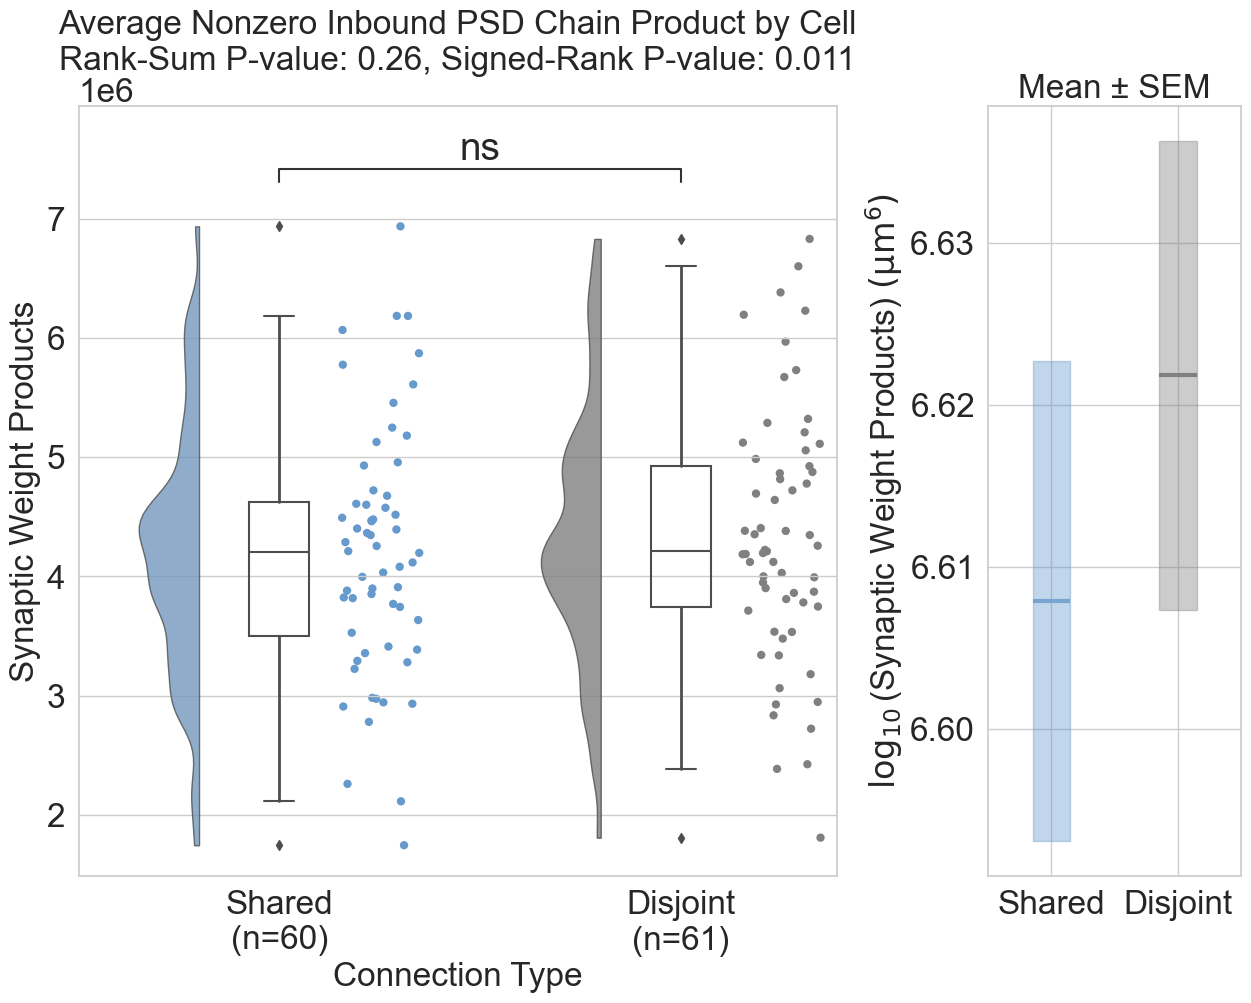

In [49]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3382, P-value: 0.3676

[UNPAIRED] Effect sizes (pos = 'greater')  n1=239, n2=307
  Test p-value: 0.3677
  Shared median = 3.946e-05, Disjoint median = 3.68207e-05

  Effect sizes with 95% CI (percentile):
    HL shift: 9.39335e-07 : CI [-5.24246e-06, 7.54562e-06]
    PS:       0.508 : CI [0.462, 0.561]   (δ=0.017 : CI [-0.076, 0.122])
    Cohen's d: -0.048 : CI [-0.216, 0.130]

  Effect sizes with 95% CI (BCa):
    HL shift: 9.39335e-07 : CI [-5.47049e-06, 7.31481e-06]
    PS:       0.508 : CI [0.459, 0.559]   (δ=0.017 : CI [-0.082, 0.117])
    Cohen's d: -0.048 : CI [-0.217, 0.129]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


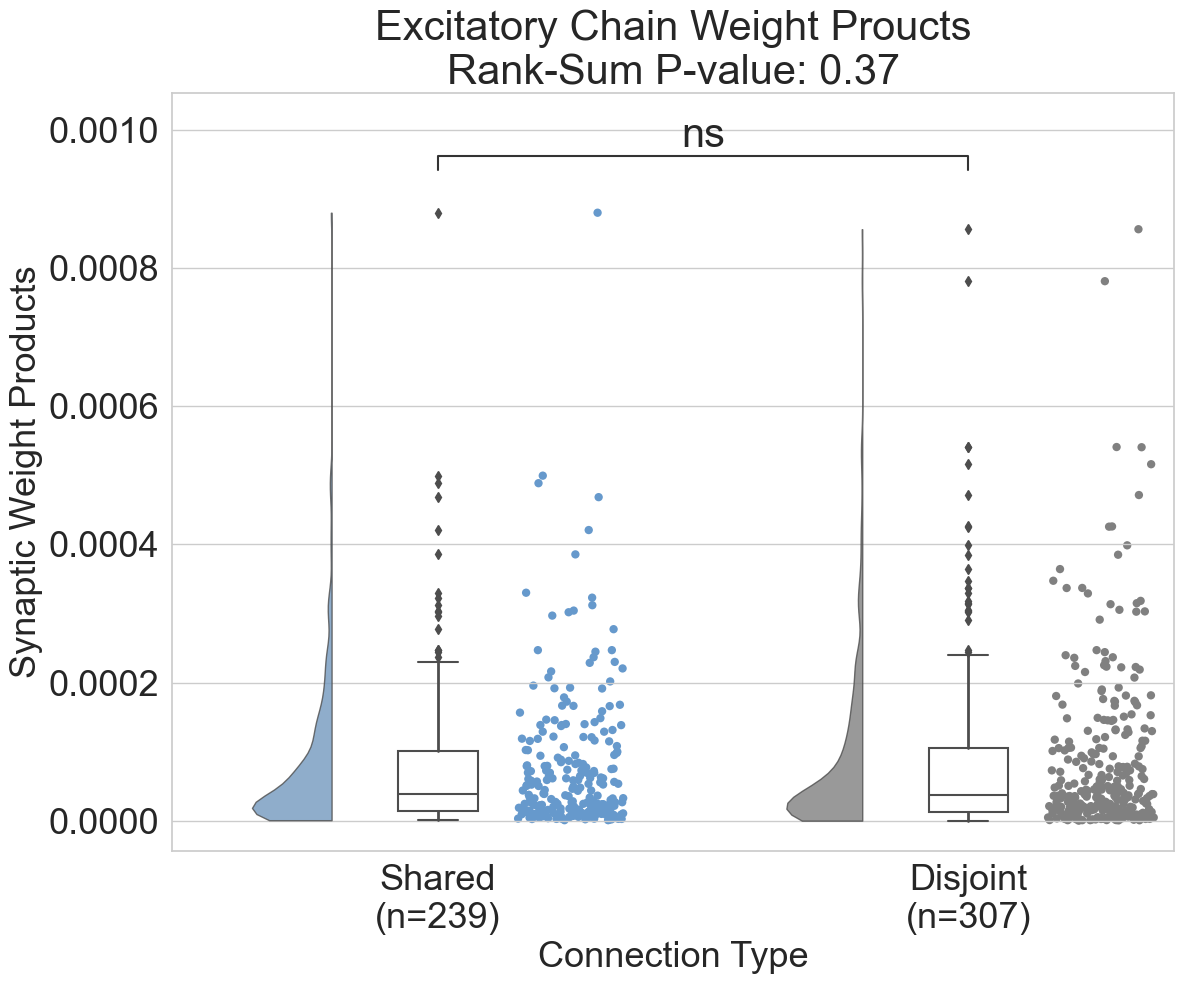

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


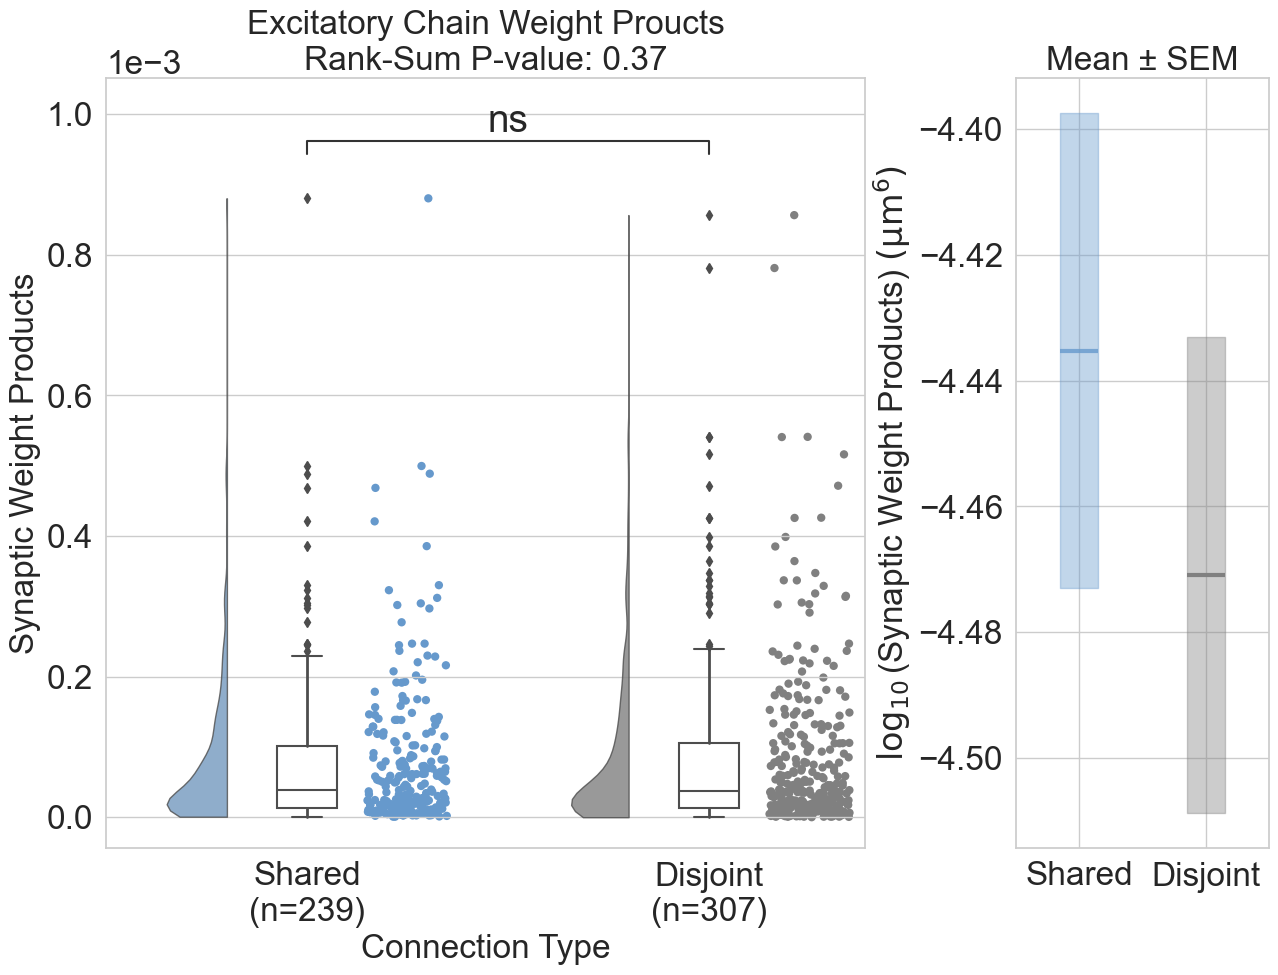

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -2.302, P-value: 0.01066

[UNPAIRED] Effect sizes (pos = 'less')  n1=1608, n2=2049
  Test p-value: 0.01066
  Shared median = 0.000698374, Disjoint median = 0.000719536

  Effect sizes with 95% CI (percentile):
    HL shift: 3.88568e-05 : CI [7.47329e-06, 7.16734e-05]
    PS:       0.522 : CI [0.504, 0.542]   (δ=0.044 : CI [0.008, 0.083])
    Cohen's d: 0.071 : CI [0.010, 0.136]

  Effect sizes with 95% CI (BCa):
    HL shift: 3.88568e-05 : CI [7.47658e-06, 7.16228e-05]
    PS:       0.522 : CI [0.504, 0.542]   (δ=0.044 : CI [0.008, 0.083])
    Cohen's d: 0.071 : CI [0.008, 0.135]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


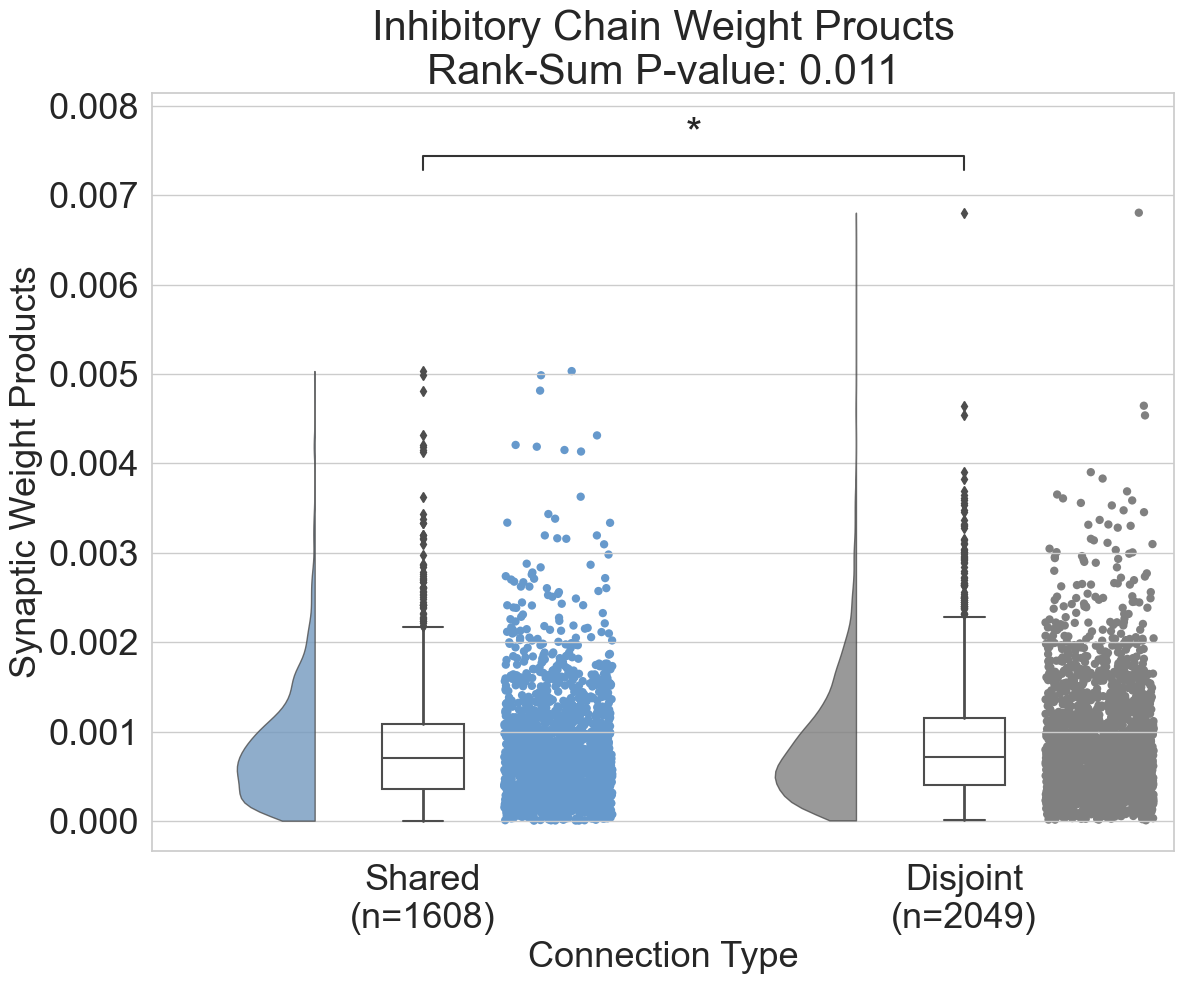

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


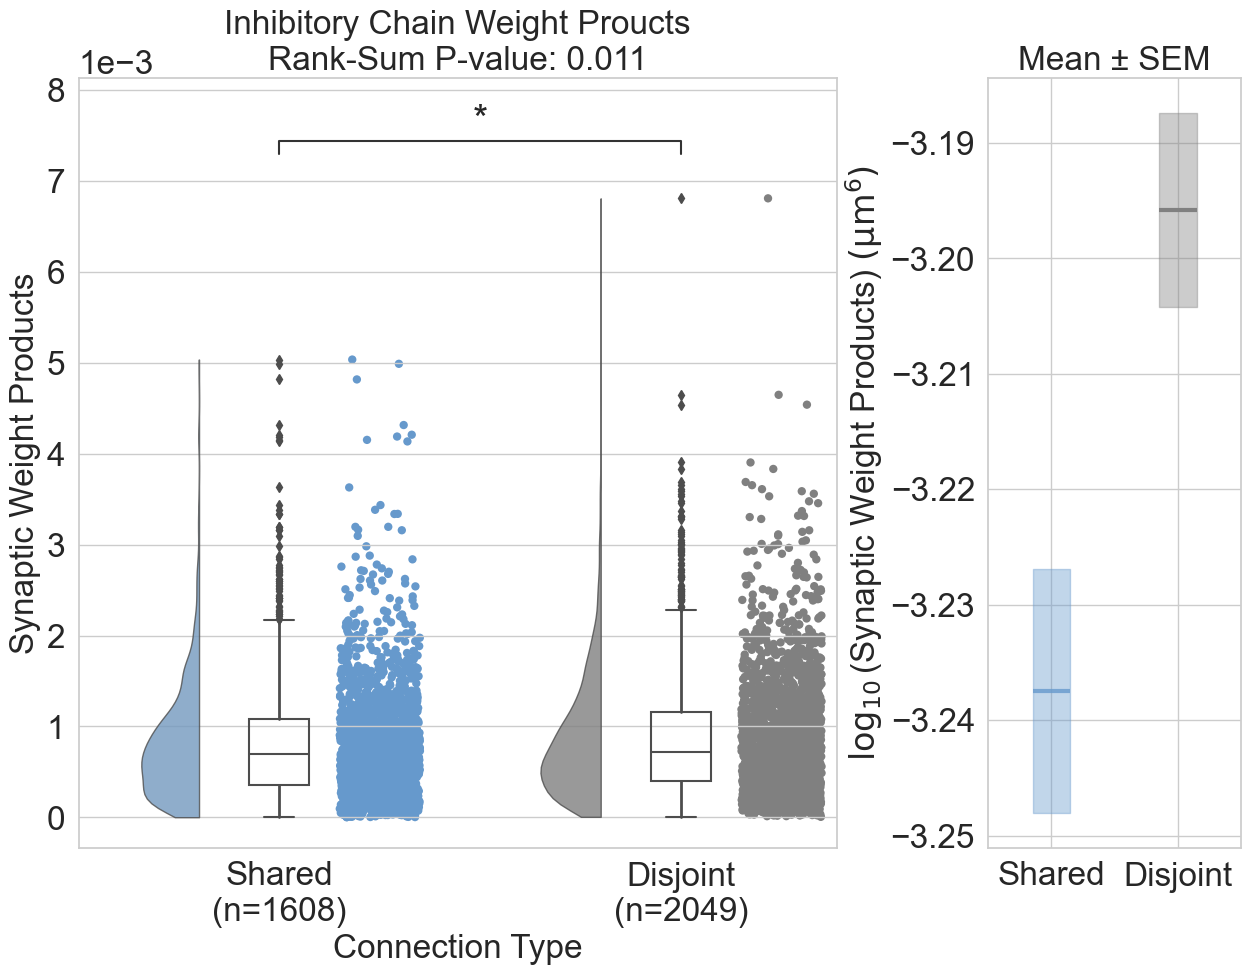

In [50]:
ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_excitatory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_E_Chain'
                                        )


ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_inhibitory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.3655, P-value: 0.6426

[UNPAIRED] Effect sizes (pos = 'greater')  n1=60, n2=61
  Test p-value: 0.6437
  Shared median = 0.000263675, Disjoint median = 0.000267941

  Effect sizes with 95% CI (percentile):
    HL shift: -1.05075e-05 : CI [-0.00010803, 0.000103875]
    PS:       0.481 : CI [0.375, 0.590]   (δ=-0.039 : CI [-0.250, 0.180])
    Cohen's d: -0.012 : CI [-0.379, 0.379]

  Effect sizes with 95% CI (BCa):
    HL shift: -1.05075e-05 : CI [-0.000109409, 0.000103733]
    PS:       0.481 : CI [0.376, 0.590]   (δ=-0.039 : CI [-0.249, 0.181])
    Cohen's d: -0.012 : CI [-0.365, 0.409]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 829, P-value: 0.5813

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=60
  Test p-value: 0.5813
  Median paired difference = -3.23065e-05

  Effect sizes with 95% CI (percentile):
    HL shift: -3.23065e-05 : CI [-7.84666e-05, 4.8823e-05]
    PS:       0.417 : CI [0.300, 

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


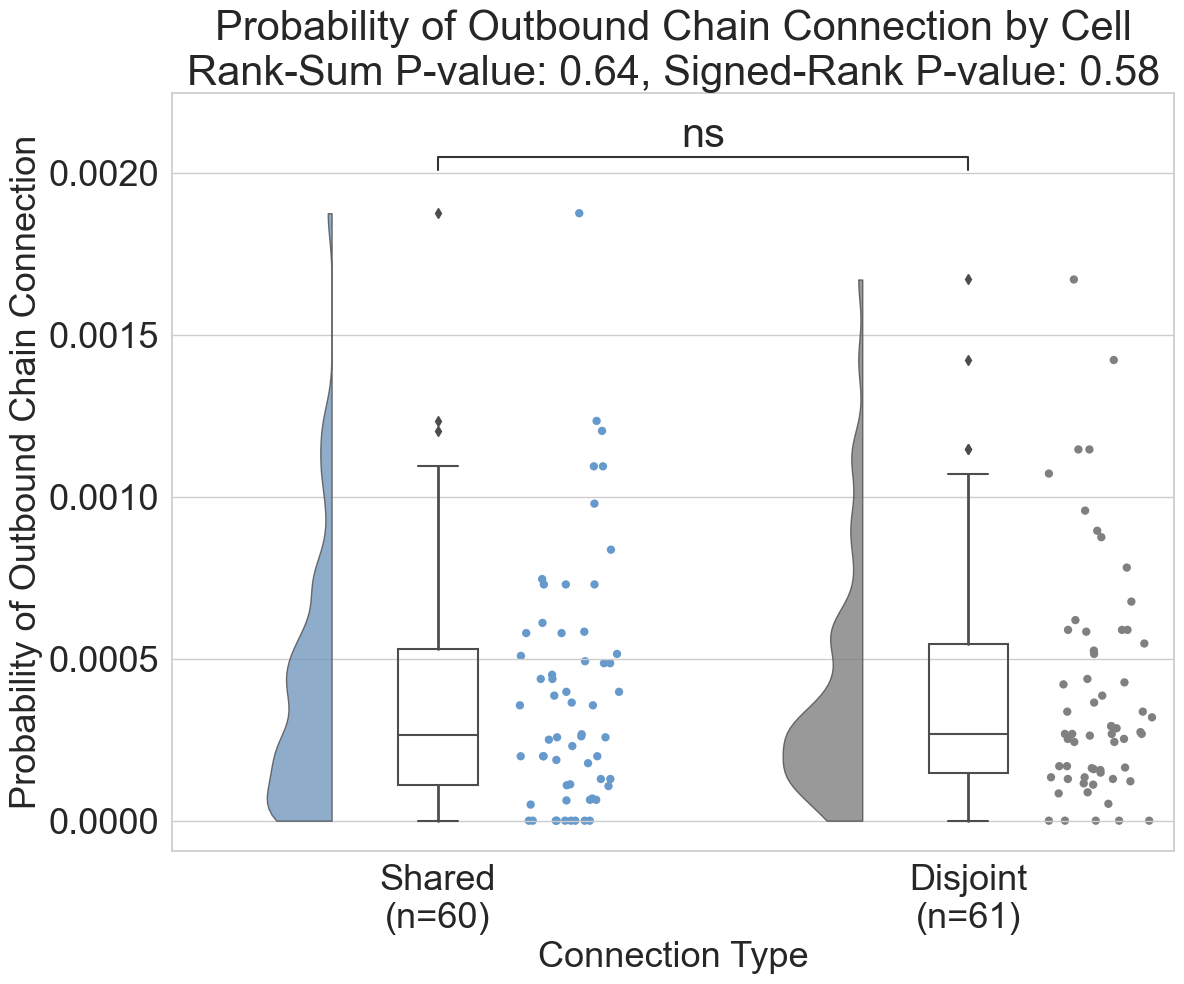

C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.426e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


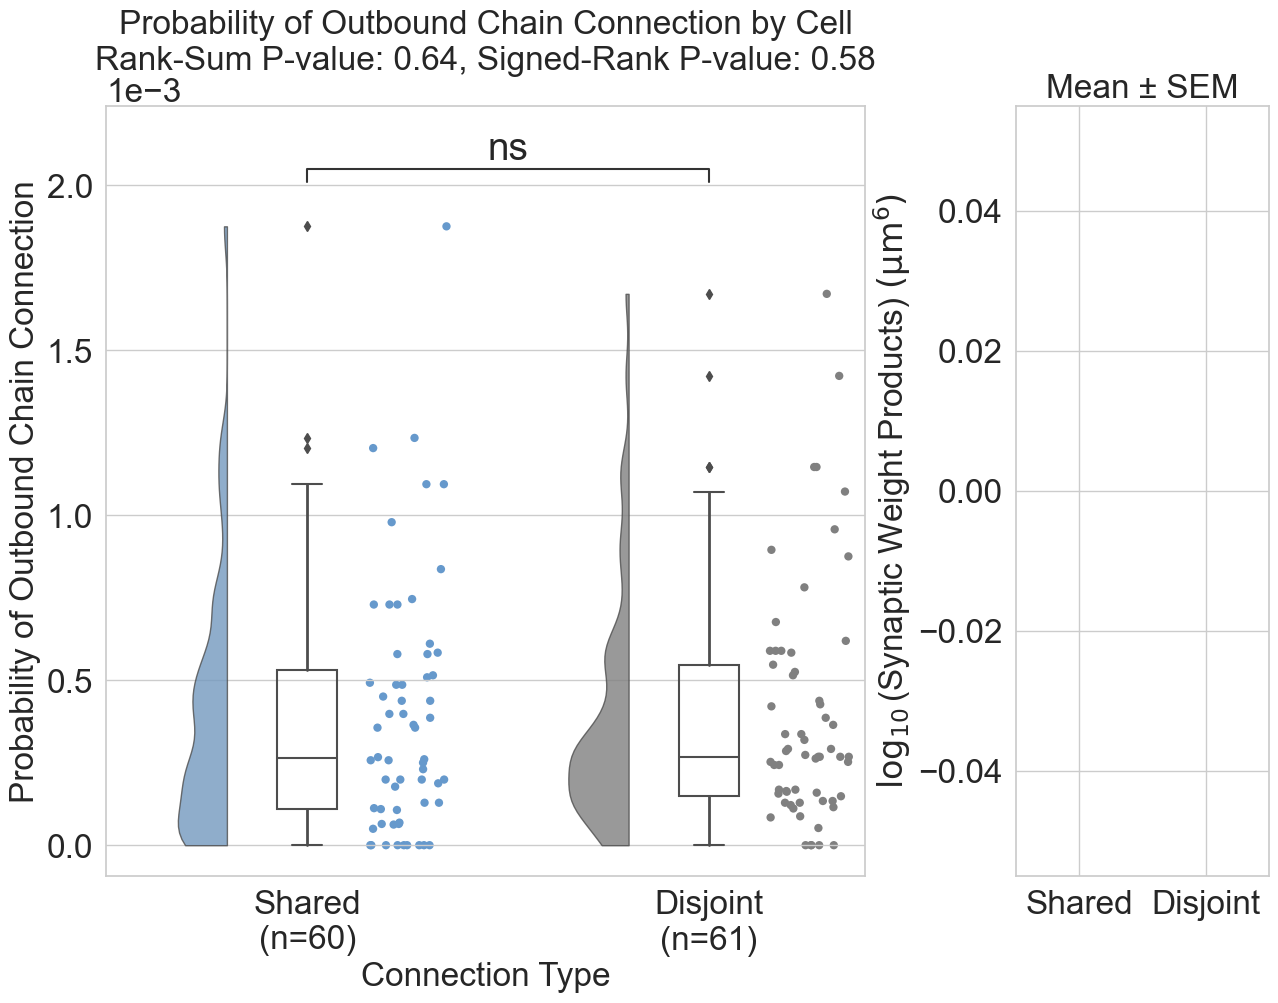

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 0.4251, P-value: 0.6646

[UNPAIRED] Effect sizes (pos = 'less')  n1=60, n2=61
  Test p-value: 0.6656
  Shared median = 0.0364702, Disjoint median = 0.0351341

  Effect sizes with 95% CI (percentile):
    HL shift: -0.00113279 : CI [-0.00446694, 0.00323033]
    PS:       0.478 : CI [0.381, 0.586]   (δ=-0.045 : CI [-0.239, 0.172])
    Cohen's d: -0.089 : CI [-0.415, 0.293]

  Effect sizes with 95% CI (BCa):
    HL shift: -0.00113279 : CI [-0.00444696, 0.00337142]
    PS:       0.478 : CI [0.384, 0.589]   (δ=-0.045 : CI [-0.232, 0.178])
    Cohen's d: -0.089 : CI [-0.403, 0.322]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 1336, P-value: 0.999

[PAIRED] Effect sizes (pos = 'less')  n_pairs=60
  Test p-value: 0.999
  Median paired difference = 0.00113837

  Effect sizes with 95% CI (percentile):
    HL shift: -0.00113837 : CI [-0.00233735, -0.000308326]
    PS:       0.367 : CI [0.250, 0.483]   (δ=-0.267 

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.646e-01


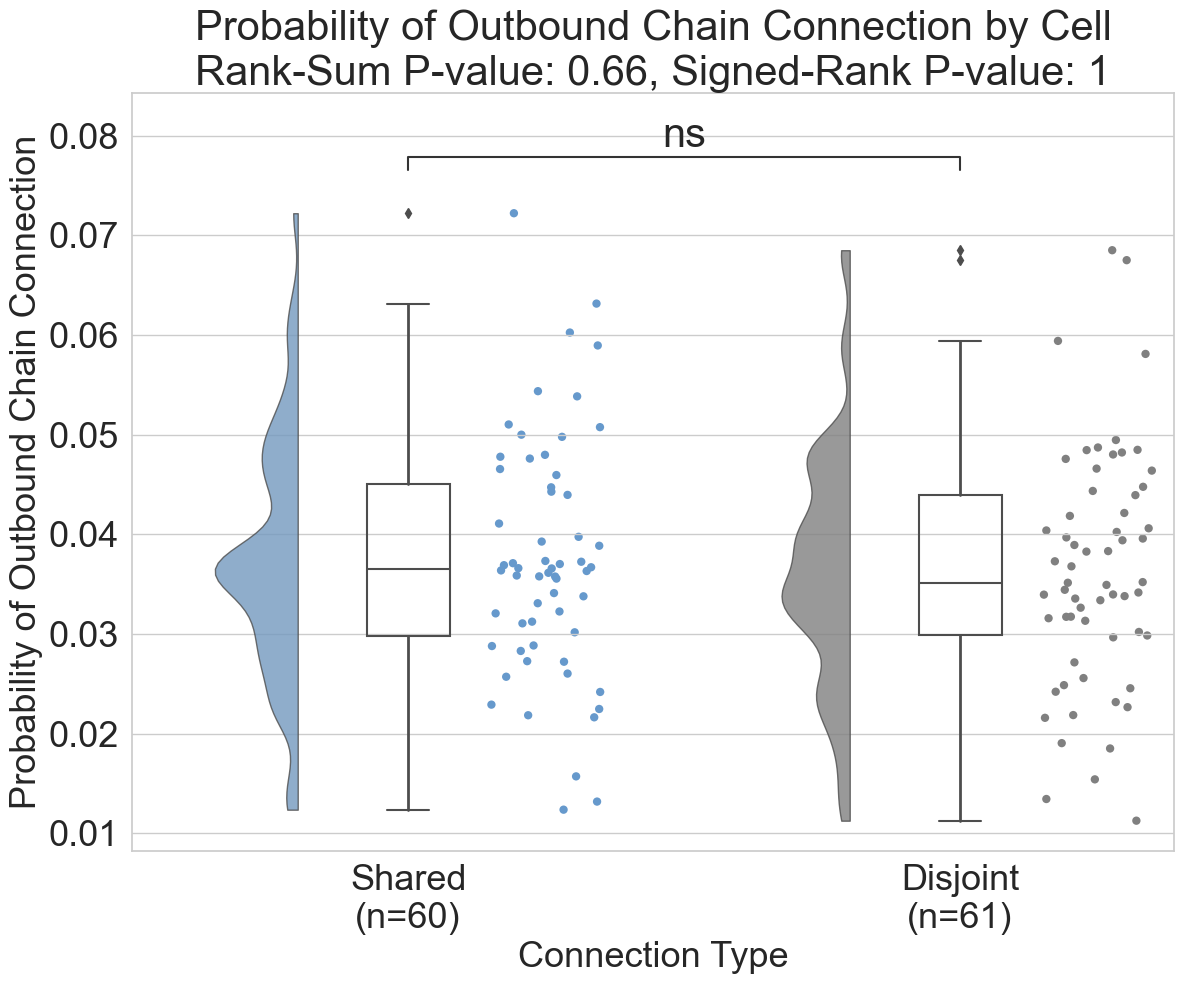

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.646e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


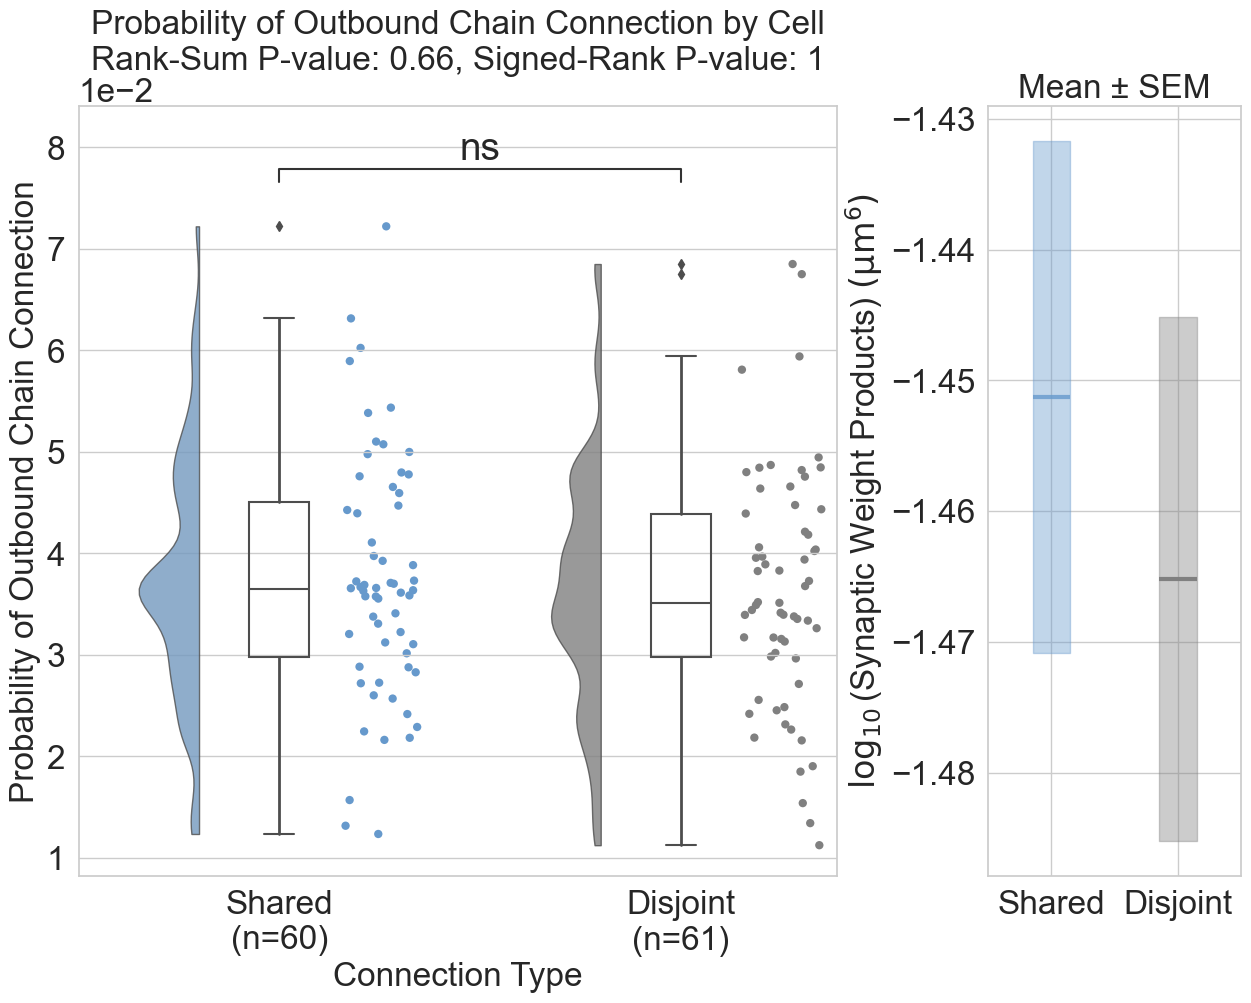

In [51]:
ranksum_signedrank_two_group_comparison(B_chain_out_excitatory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_chain_out_inhibitory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.0499, P-value: 0.4801

[UNPAIRED] Effect sizes (pos = 'greater')  n1=51, n2=56
  Test p-value: 0.4813
  Shared median = 3.79901e+06, Disjoint median = 3.76326e+06

  Effect sizes with 95% CI (percentile):
    HL shift: 25718.2 : CI [-1.2748e+06, 1.09474e+06]
    PS:       0.503 : CI [0.391, 0.616]   (δ=0.006 : CI [-0.219, 0.231])
    Cohen's d: 0.097 : CI [-0.306, 0.472]

  Effect sizes with 95% CI (BCa):
    HL shift: 25718.2 : CI [-1.27668e+06, 1.09407e+06]
    PS:       0.503 : CI [0.390, 0.616]   (δ=0.006 : CI [-0.219, 0.231])
    Cohen's d: 0.097 : CI [-0.281, 0.510]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 596, P-value: 0.4696

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=48
  Test p-value: 0.4696
  Median paired difference = -19544.5

  Effect sizes with 95% CI (percentile):
    HL shift: -19544.5 : CI [-1.53363e+06, 1.07247e+06]
    PS:       0.500 : CI [0.354, 0.646]   (δ=0.000 : CI

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=51) vs. Disjoint
(n=56): Custom statistical test, P_val:4.801e-01


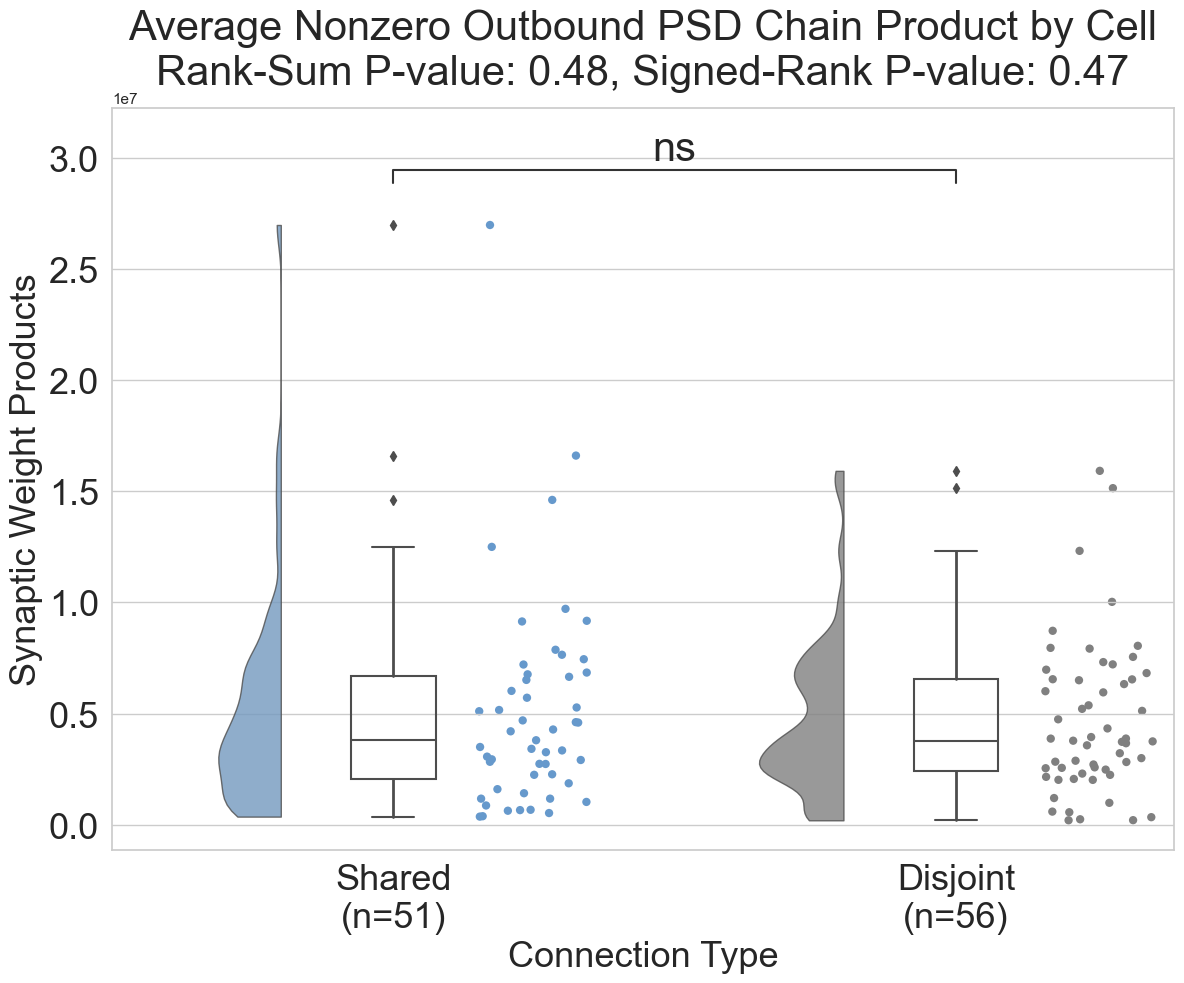

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=51) vs. Disjoint
(n=56): Custom statistical test, P_val:4.801e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


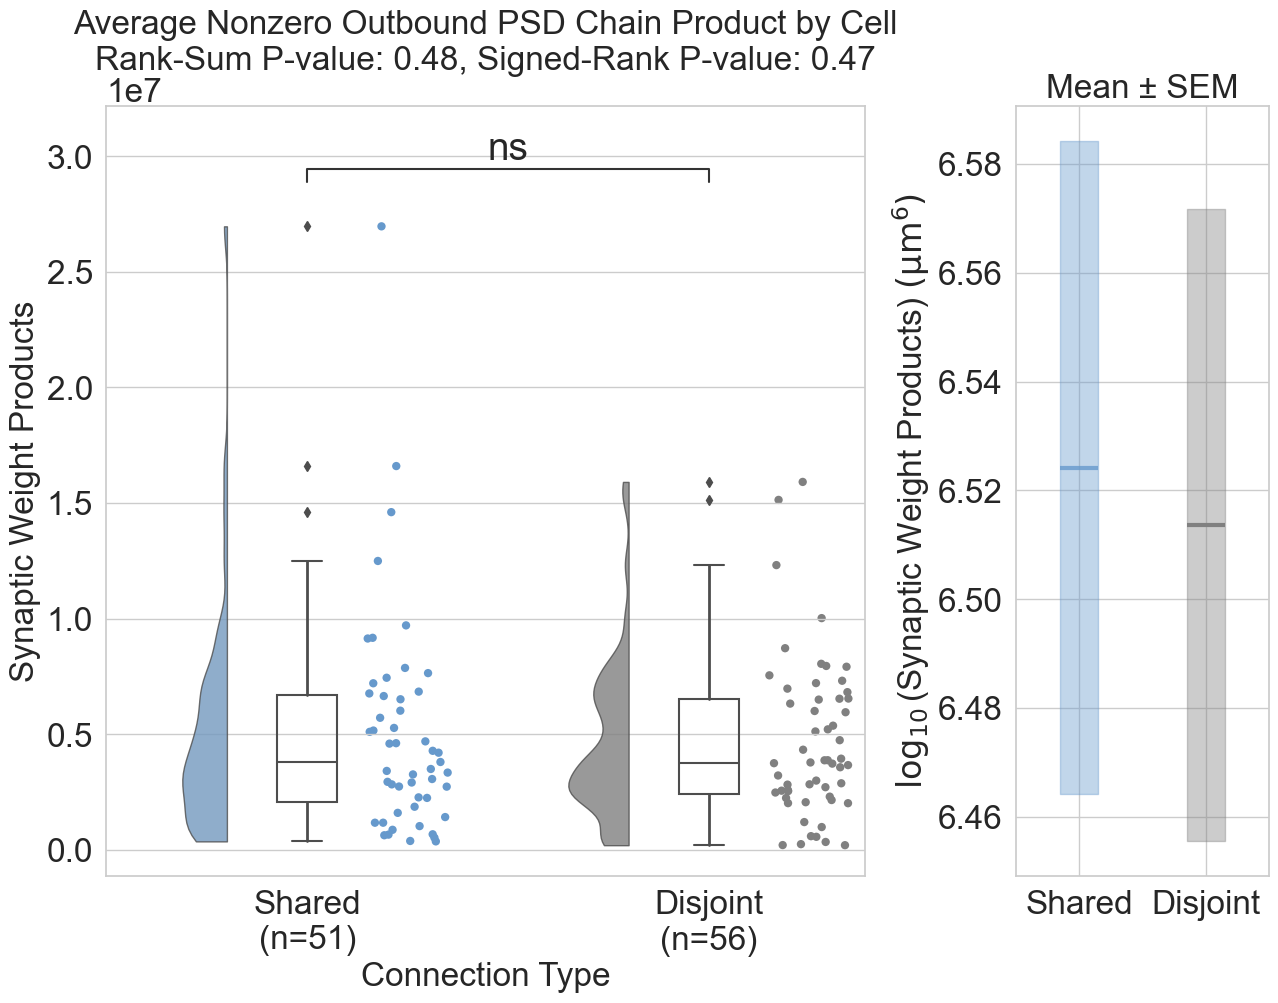

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.337, P-value: 0.09053

[UNPAIRED] Effect sizes (pos = 'less')  n1=60, n2=61
  Test p-value: 0.09096
  Shared median = 4.13073e+06, Disjoint median = 4.29109e+06

  Effect sizes with 95% CI (percentile):
    HL shift: 240451 : CI [-92429.4, 627755]
    PS:       0.570 : CI [0.467, 0.670]   (δ=0.141 : CI [-0.066, 0.340])
    Cohen's d: 0.179 : CI [-0.169, 0.550]

  Effect sizes with 95% CI (BCa):
    HL shift: 240451 : CI [-87146.3, 635237]
    PS:       0.570 : CI [0.466, 0.670]   (δ=0.141 : CI [-0.067, 0.340])
    Cohen's d: 0.179 : CI [-0.197, 0.524]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 493, P-value: 0.0009463

[PAIRED] Effect sizes (pos = 'less')  n_pairs=60
  Test p-value: 0.0009463
  Median paired difference = -193997

  Effect sizes with 95% CI (percentile):
    HL shift: 193997 : CI [75652.1, 442996]
    PS:       0.683 : CI [0.567, 0.800]   (δ=0.367 : CI [0.133, 0.600])
    Cohen's d

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:9.053e-02


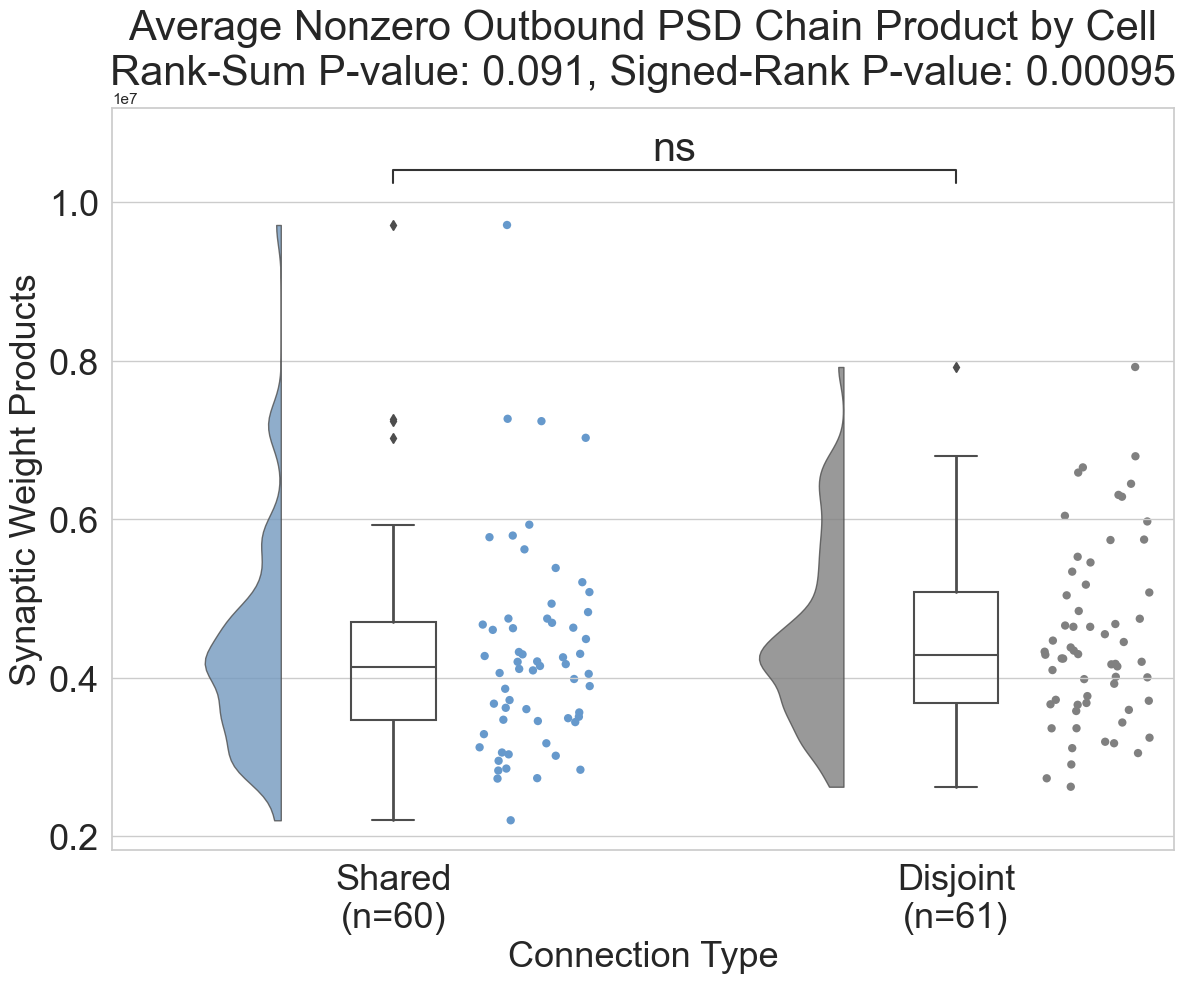

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:9.053e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


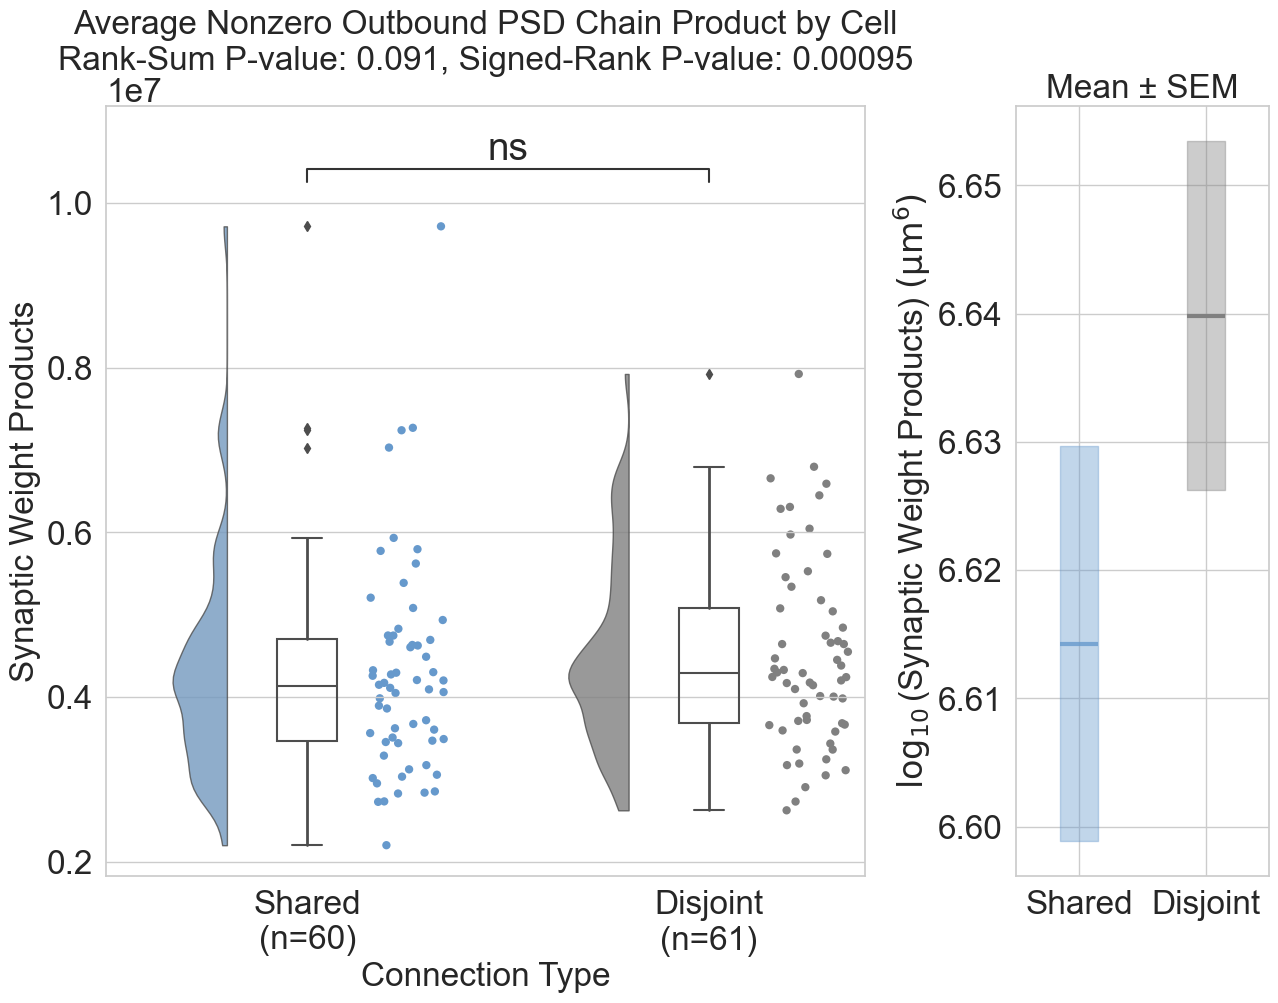

In [52]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_out_excitatory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_nonzero_chain_out_inhibitory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.3396, P-value: 0.6329

[UNPAIRED] Effect sizes (pos = 'greater')  n1=60, n2=61
  Test p-value: 0.6341
  Shared median = 0.000321792, Disjoint median = 0.000273523

  Effect sizes with 95% CI (percentile):
    HL shift: -1.61492e-05 : CI [-0.000120811, 0.000100997]
    PS:       0.482 : CI [0.383, 0.583]   (δ=-0.036 : CI [-0.233, 0.167])
    Cohen's d: -0.102 : CI [-0.431, 0.263]

  Effect sizes with 95% CI (BCa):
    HL shift: -1.61492e-05 : CI [-0.000145327, 8.63344e-05]
    PS:       0.482 : CI [0.375, 0.577]   (δ=-0.036 : CI [-0.251, 0.154])
    Cohen's d: -0.102 : CI [-0.458, 0.250]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 607, P-value: 0.8783

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=60
  Test p-value: 0.8783
  Median paired difference = -4.2221e-05

  Effect sizes with 95% CI (percentile):
    HL shift: -4.2221e-05 : CI [-8.41609e-05, 0]
    PS:       0.417 : CI [0.300, 0.533]   (

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.329e-01


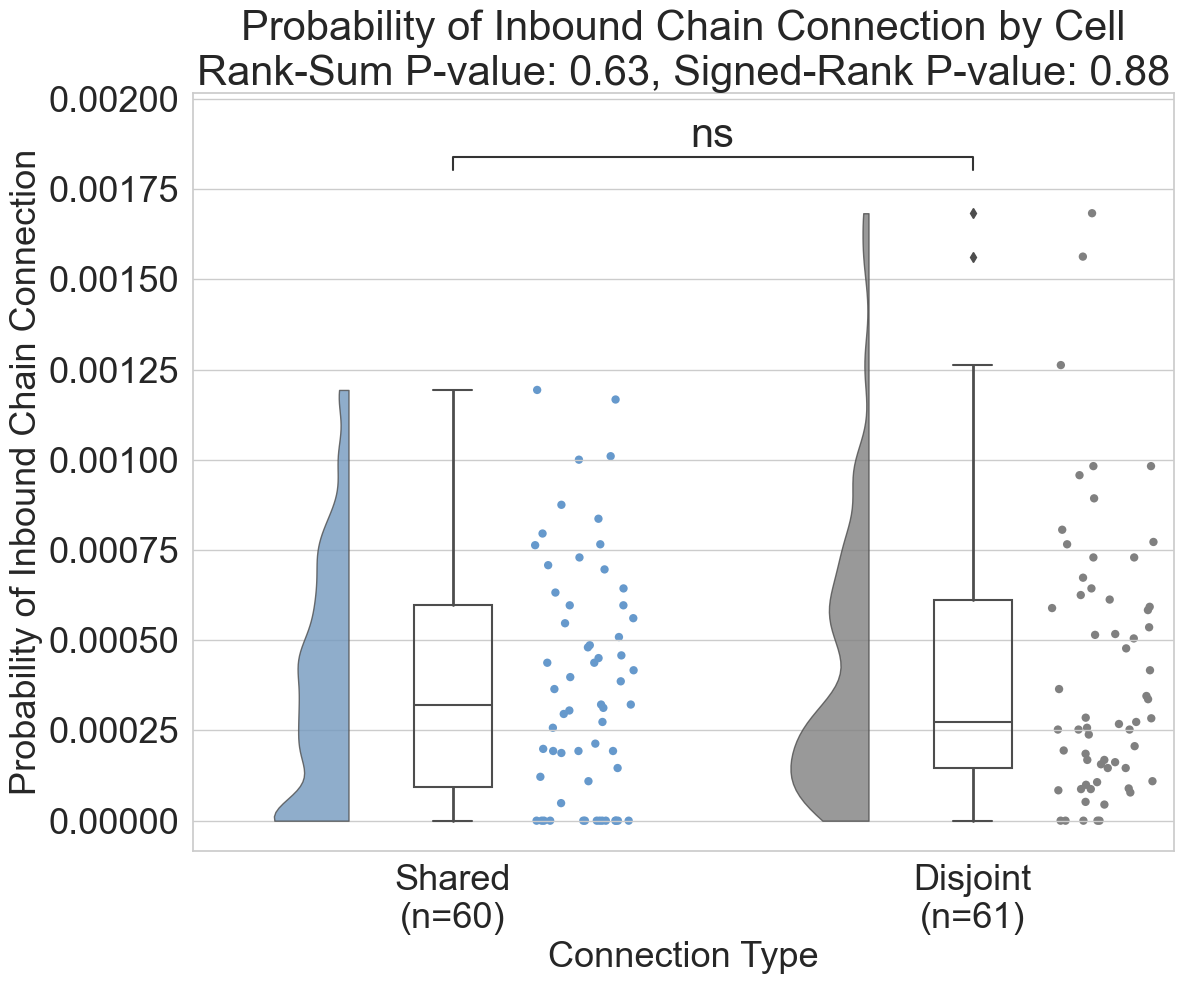

C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.329e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


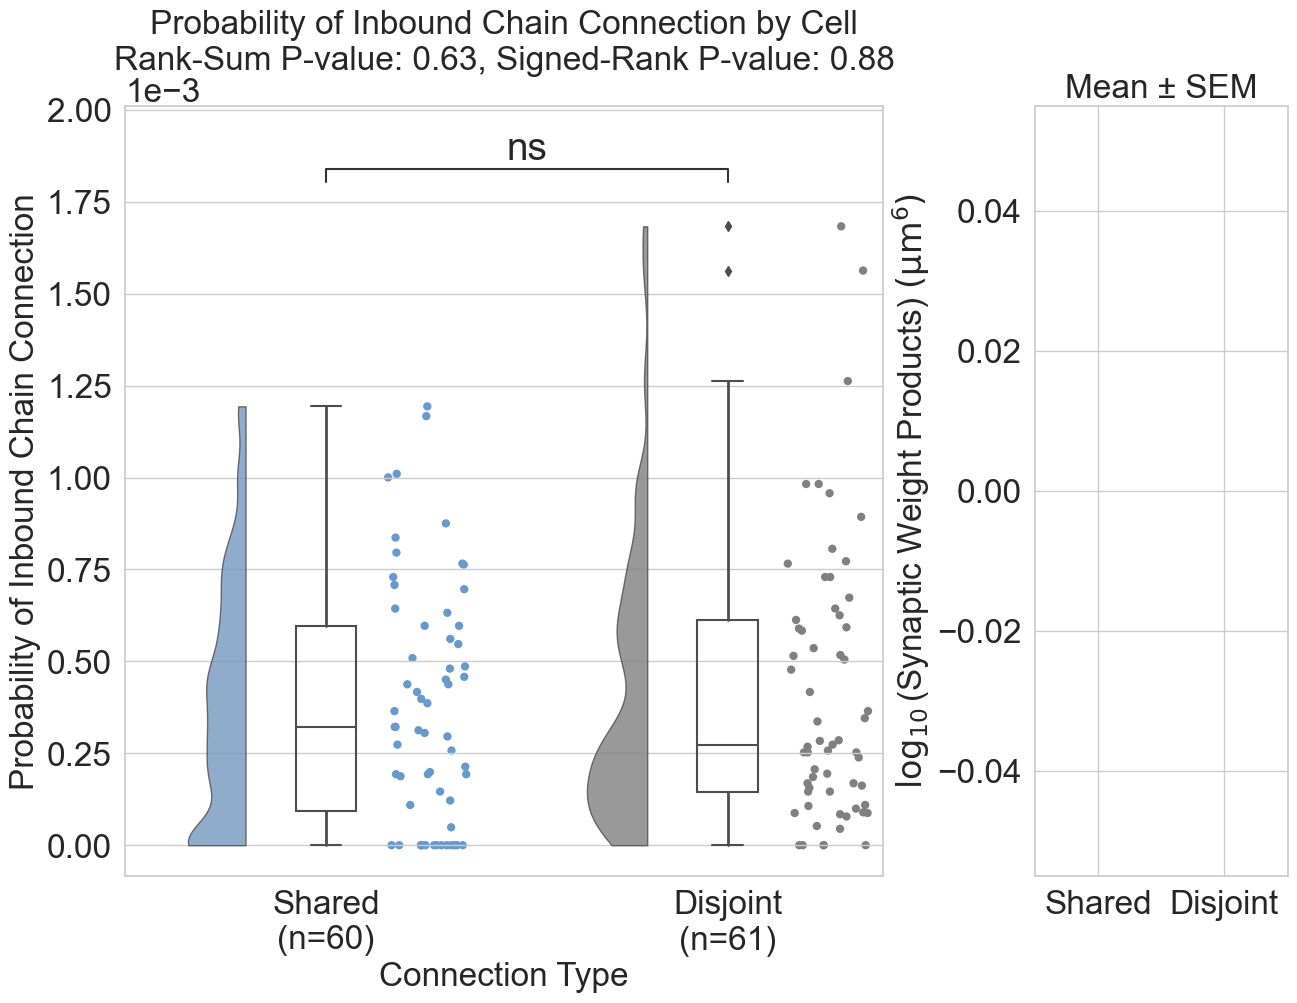

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.4977, P-value: 0.3094

[UNPAIRED] Effect sizes (pos = 'less')  n1=60, n2=61
  Test p-value: 0.3103
  Shared median = 0.0379312, Disjoint median = 0.038617

  Effect sizes with 95% CI (percentile):
    HL shift: 0.000753208 : CI [-0.00280379, 0.00425306]
    PS:       0.526 : CI [0.423, 0.628]   (δ=0.052 : CI [-0.154, 0.256])
    Cohen's d: 0.077 : CI [-0.287, 0.445]

  Effect sizes with 95% CI (BCa):
    HL shift: 0.000753208 : CI [-0.00281833, 0.00419749]
    PS:       0.526 : CI [0.425, 0.630]   (δ=0.052 : CI [-0.151, 0.260])
    Cohen's d: 0.077 : CI [-0.284, 0.447]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 619, P-value: 0.01466

[PAIRED] Effect sizes (pos = 'less')  n_pairs=60
  Test p-value: 0.01466
  Median paired difference = -0.00171842

  Effect sizes with 95% CI (percentile):
    HL shift: 0.00171842 : CI [0.000904722, 0.00224473]
    PS:       0.717 : CI [0.583, 0.817]   (δ=0.433 : CI

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:3.094e-01


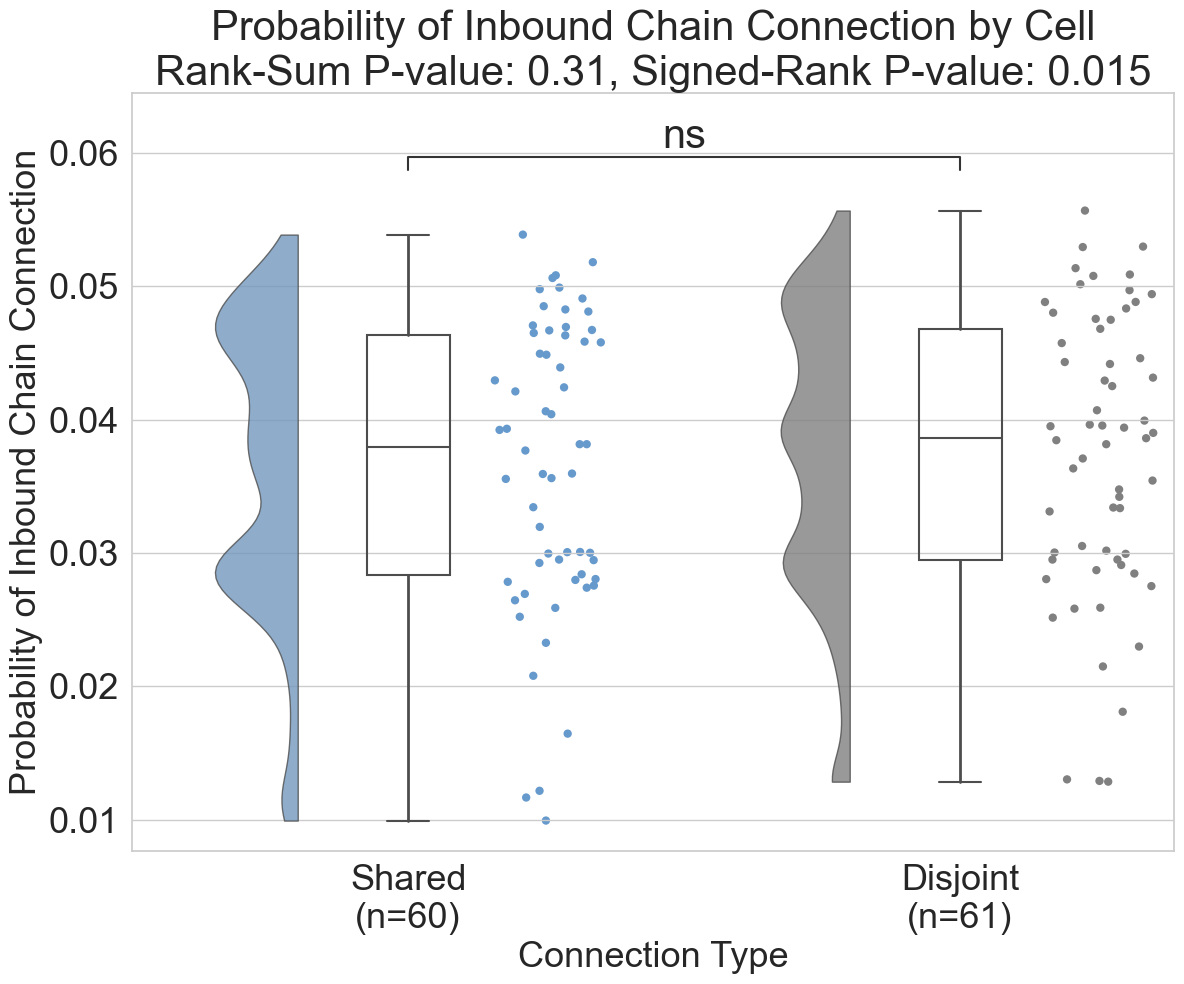

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:3.094e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


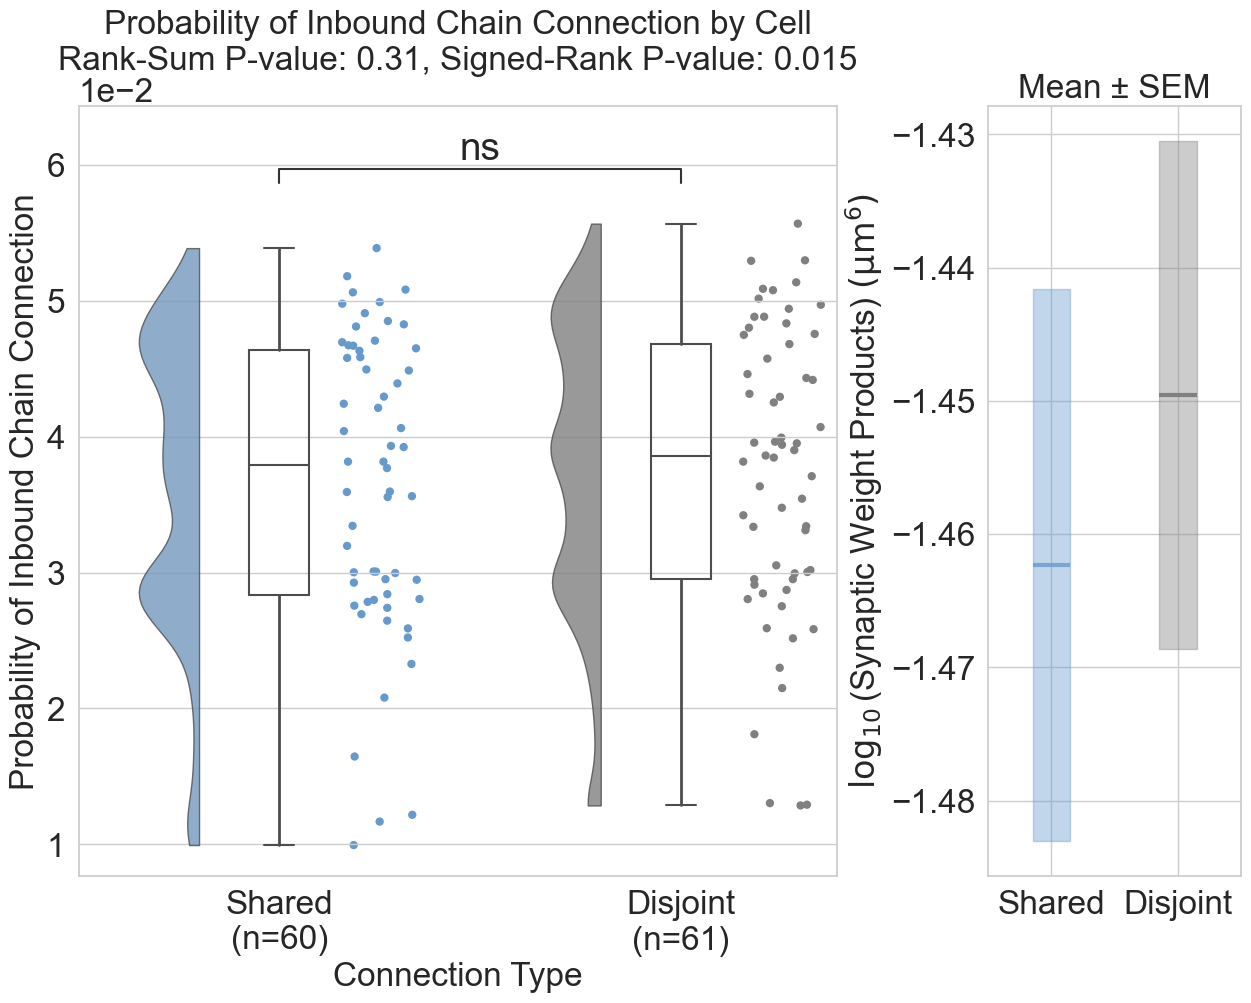

In [53]:
ranksum_signedrank_two_group_comparison(B_chain_in_excitatory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.7263, P-value: 0.2338

[UNPAIRED] Effect sizes (pos = 'greater')  n1=46, n2=56
  Test p-value: 0.2349
  Shared median = 4.06571e+06, Disjoint median = 4.09343e+06

  Effect sizes with 95% CI (percentile):
    HL shift: 412712 : CI [-749474, 1.62403e+06]
    PS:       0.542 : CI [0.432, 0.659]   (δ=0.084 : CI [-0.137, 0.318])
    Cohen's d: 0.186 : CI [-0.191, 0.574]

  Effect sizes with 95% CI (BCa):
    HL shift: 412712 : CI [-816942, 1.59296e+06]
    PS:       0.542 : CI [0.427, 0.654]   (δ=0.084 : CI [-0.147, 0.308])
    Cohen's d: 0.186 : CI [-0.202, 0.550]
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 502, P-value: 0.571

[PAIRED] Effect sizes (pos = 'greater')  n_pairs=45
  Test p-value: 0.571
  Median paired difference = -133996

  Effect sizes with 95% CI (percentile):
    HL shift: -133996 : CI [-2.14199e+06, 1.23001e+06]
    PS:       0.489 : CI [0.333, 0.644]   (δ=-0.022 : CI [-0.333, 0.28

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


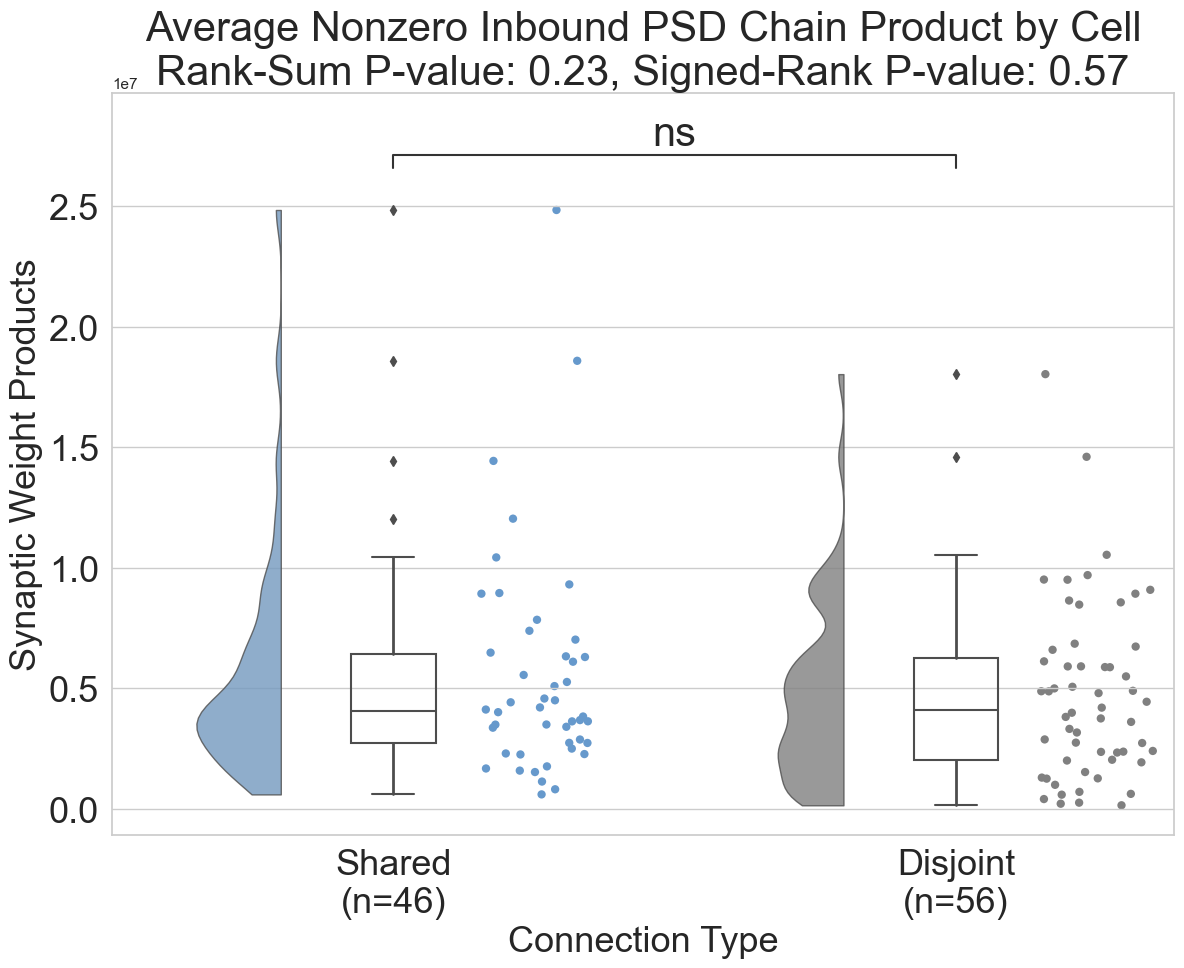

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=46) vs. Disjoint
(n=56): Custom statistical test, P_val:2.338e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


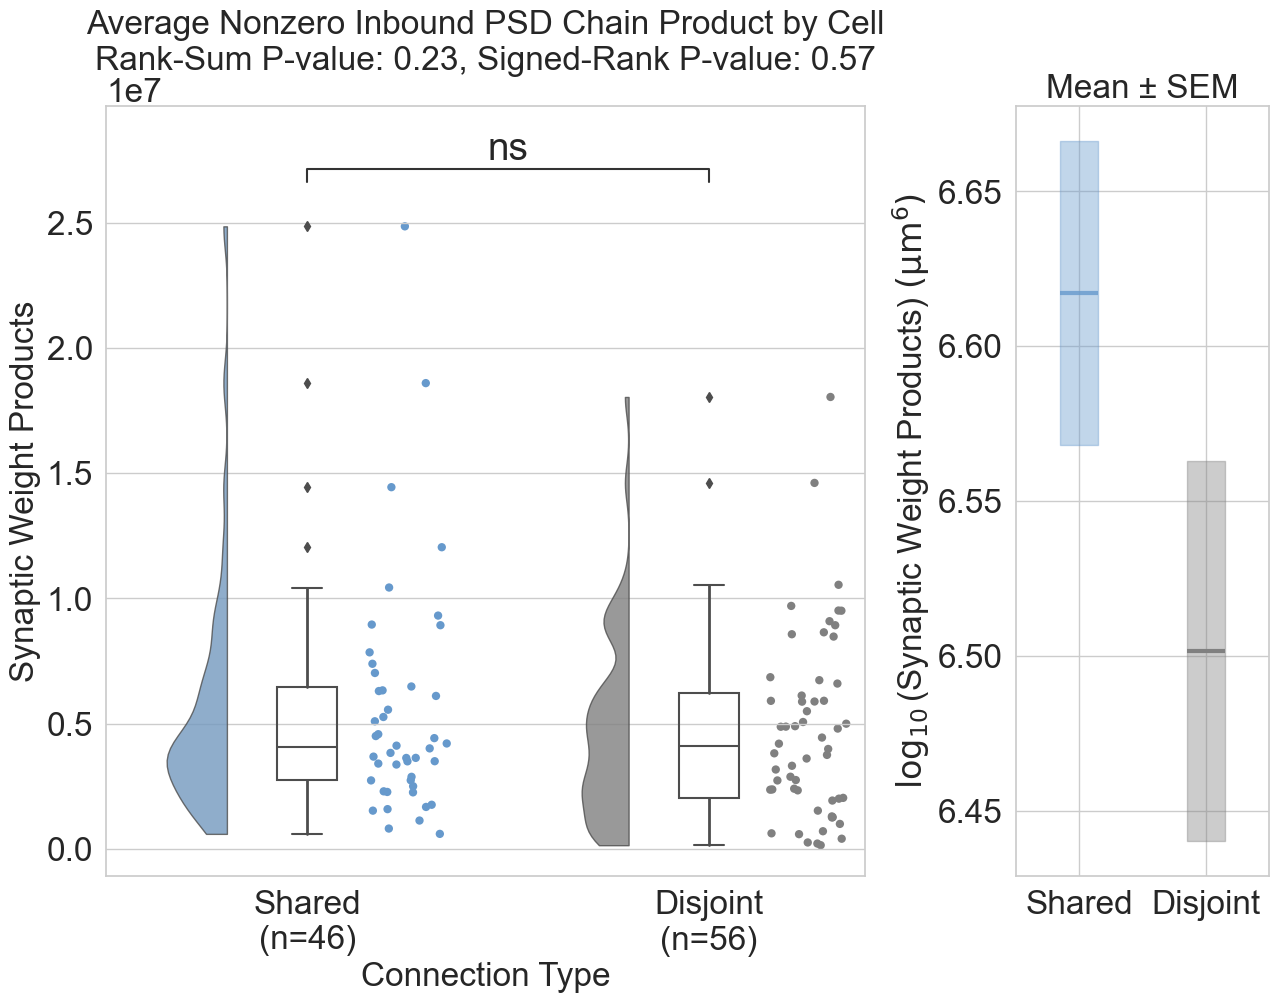

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.6376, P-value: 0.2619

[UNPAIRED] Effect sizes (pos = 'less')  n1=60, n2=61
  Test p-value: 0.2627
  Shared median = 4.20441e+06, Disjoint median = 4.21068e+06

  Effect sizes with 95% CI (percentile):
    HL shift: 124573 : CI [-245348, 485467]
    PS:       0.534 : CI [0.432, 0.634]   (δ=0.067 : CI [-0.136, 0.267])
    Cohen's d: 0.127 : CI [-0.229, 0.480]

  Effect sizes with 95% CI (BCa):
    HL shift: 124573 : CI [-255639, 482868]
    PS:       0.534 : CI [0.431, 0.633]   (δ=0.067 : CI [-0.137, 0.266])
    Cohen's d: 0.127 : CI [-0.232, 0.474]
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 606, P-value: 0.01146

[PAIRED] Effect sizes (pos = 'less')  n_pairs=60
  Test p-value: 0.01146
  Median paired difference = -134369

  Effect sizes with 95% CI (percentile):
    HL shift: 134369 : CI [-23351.2, 297052]
    PS:       0.600 : CI [0.483, 0.733]   (δ=0.200 : CI [-0.033, 0.467])
    Cohen's d: 0.3

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:2.619e-01


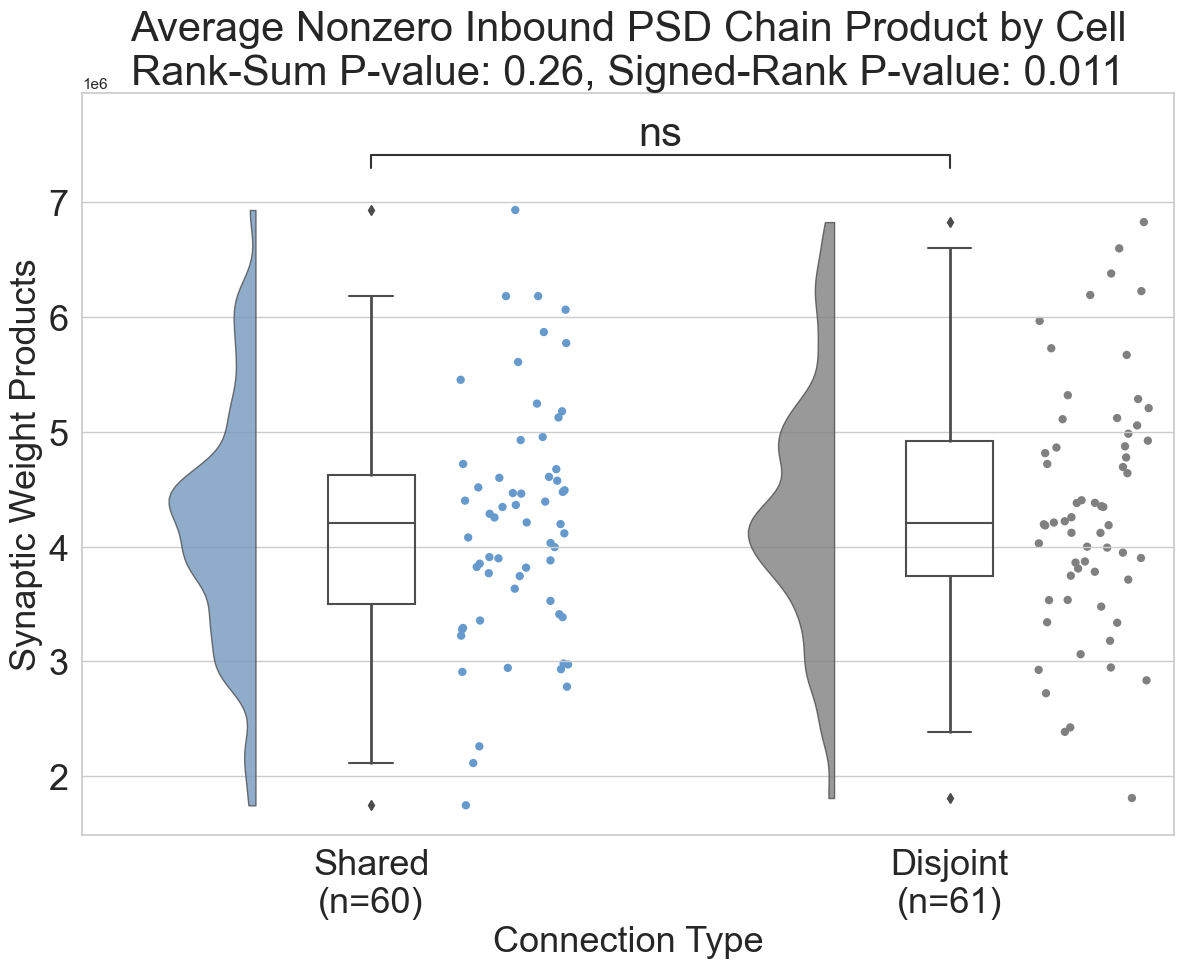

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:2.619e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


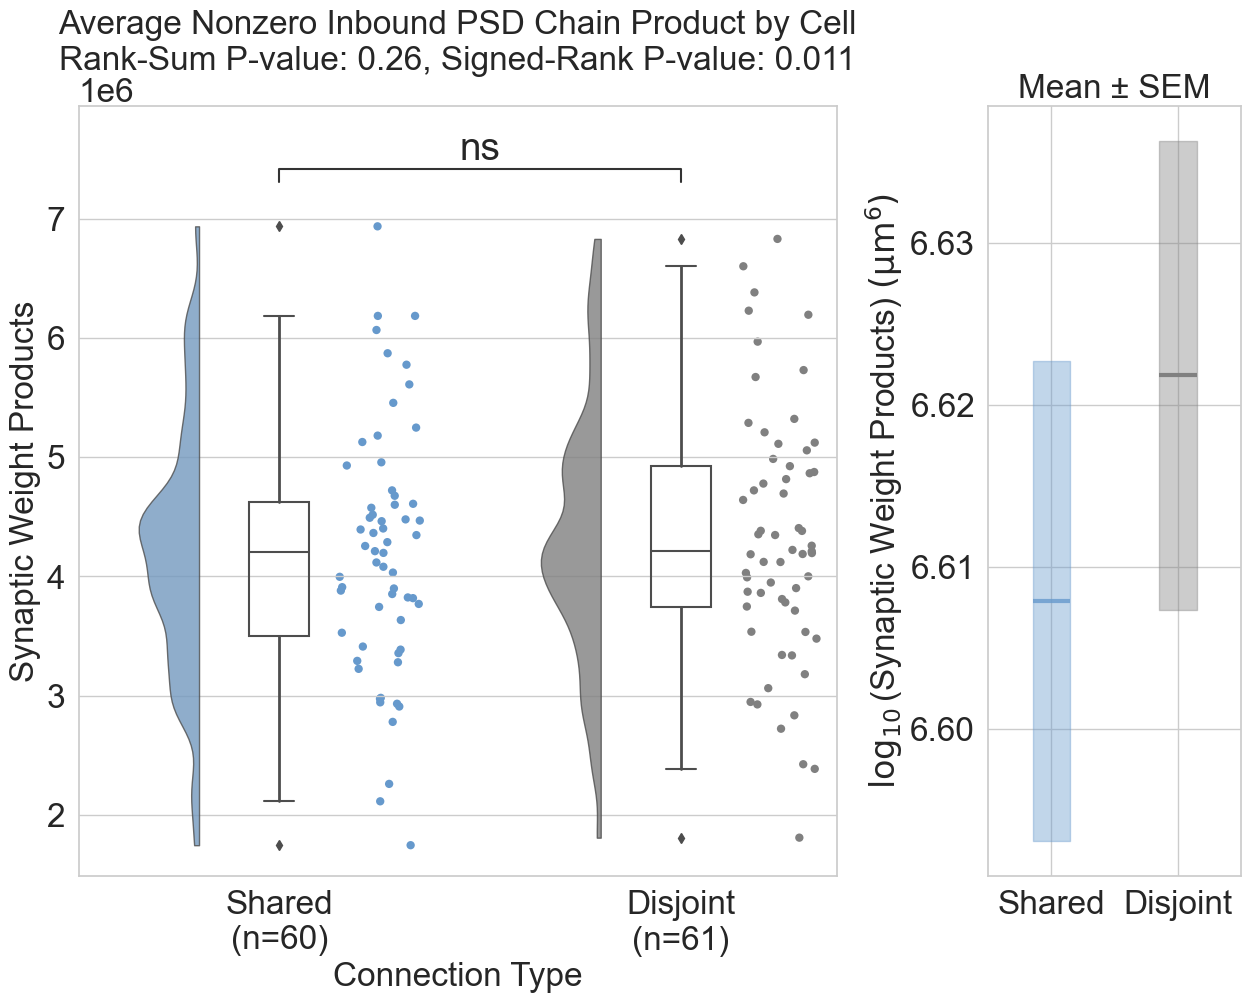

In [54]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_excitatory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

# Subsampling:

SUBSAMPLED
Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.106, P-value: 0.1343

[UNPAIRED] Effect sizes (pos = 'less')  n1=239, n2=307
  Test p-value: 0.1343
  Shared median = 0.000632796, Disjoint median = 0.000726464

  Effect sizes with 95% CI (percentile):
    HL shift: 4.75498e-05 : CI [-3.67543e-05, 0.000137155]
    PS:       0.528 : CI [0.479, 0.577]   (δ=0.055 : CI [-0.043, 0.154])
    Cohen's d: 0.063 : CI [-0.111, 0.243]

  Effect sizes with 95% CI (BCa):
    HL shift: 4.75498e-05 : CI [-2.95255e-05, 0.000141636]
    PS:       0.528 : CI [0.483, 0.581]   (δ=0.055 : CI [-0.035, 0.162])
    Cohen's d: 0.063 : CI [-0.108, 0.252]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


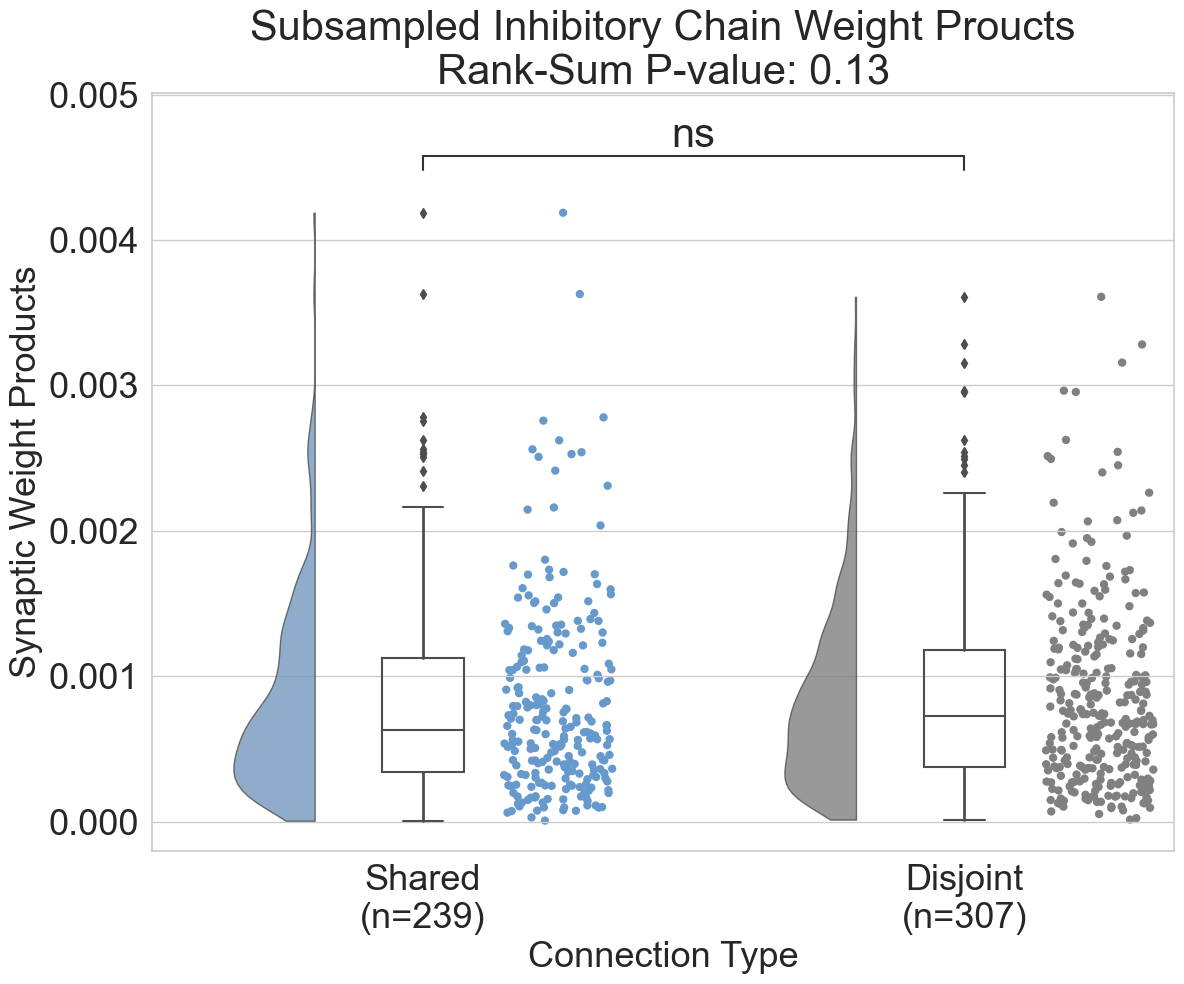

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_12532\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


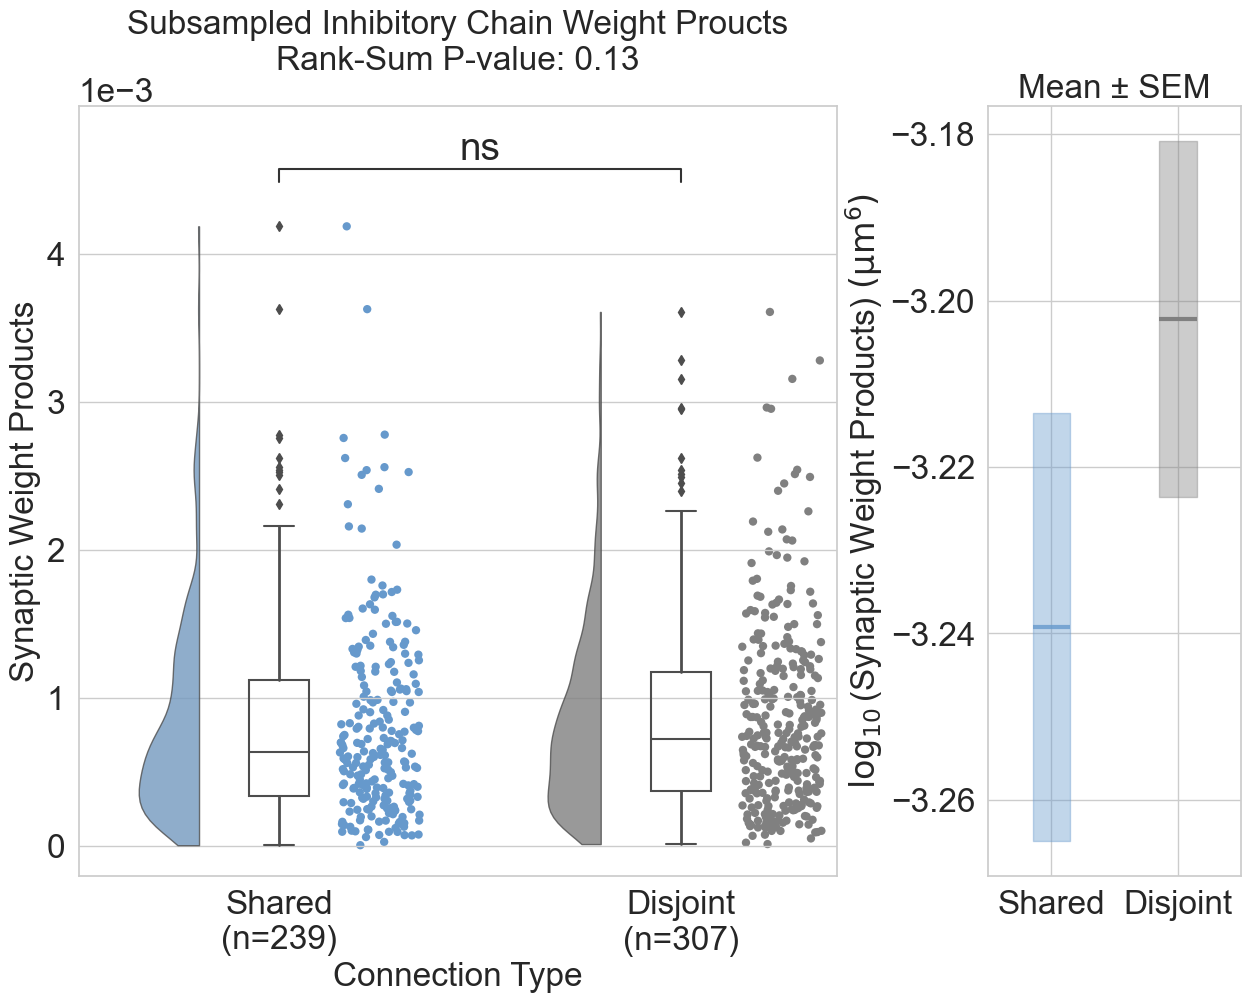


Resampling (B=10000) summary, resampling percentile CIs
Proportion significant (α=0.05): 0.209
HL shift median: 3.97e-05 (95% CI -3.92e-05–0.000115)
PS median: 0.523 (95% CI 0.478–0.566)
Cohen's d median: 0.0723 (95% CI -0.0823–0.226)
δ median: 0.0452 (95% CI -0.0445–0.132)


In [61]:
# ---------------- Helpers ----------------

def extract_vals_keys(dod):
    """Flatten dict-of-dicts into arrays (values) + arrays (keys) for each stratum."""
    vals, keys = {}, {}
    for k in ('shared', 'disjoint'):
        items = list(dod.get(k, {}).items())
        if items:
            k_arr, v_arr = zip(*items)         # tuples
            vals[k] = np.asarray(v_arr, dtype=float)
            keys[k] = np.asarray(k_arr, dtype=object)
        else:
            vals[k] = np.empty(0, float)
            keys[k] = np.empty(0, object)
    return vals, keys

def subsample_indices(n_avail, n_take, rng):
    if n_take > n_avail:
        raise ValueError(f"Requesting {n_take} from only {n_avail} available.")
    return rng.choice(n_avail, size=n_take, replace=False)

def build_dict_from_indices(keys, vals, idx_s, idx_d):
    """Rebuild dict-of-dicts for plotting/test function (keeps original (pre,post) keys)."""
    return {
        'shared':   {tuple(keys['shared'][i]): float(vals['shared'][i])     for i in idx_s},
        'disjoint': {tuple(keys['disjoint'][i]): float(vals['disjoint'][i]) for i in idx_d},
    }


def one_draw_stats(I_vals, n_shared, n_disjoint, rng):
    """One subsample: returns test results and effect sizes."""
    idx_s = subsample_indices(I_vals['shared'].size,   n_shared,   rng)
    idx_d = subsample_indices(I_vals['disjoint'].size, n_disjoint, rng)
    s = I_vals['shared'][idx_s]
    d = I_vals['disjoint'][idx_d]

    # Mann–Whitney U (direction shared < disjoint)
    U_s, p_mw = mannwhitneyu(s, d, alternative='less', method='asymptotic')
    n1, n2 = s.size, d.size
    delta = 1.0 - (2.0 * U_s) / (n1 * n2)

    # Other effect sizes
    d_cohen = cohens_d(s, d, alternative='less')
    HL = hodges_lehmann(s, d, alternative='less')
    PS, _ = ps_and_delta(s, d, alternative='less')

    return {
        "p": p_mw,
        "delta": delta,
        "d": d_cohen,
        "HL": HL,
        "PS": PS,
        "idx_s": idx_s,
        "idx_d": idx_d,
        "s": s,
        "d_vals": d,
    }


def resample_many(I_vals, n_shared, n_disjoint, B=10_000, rng=None):
    """Repeat subsampling many times: return arrays of effect sizes + p-values."""
    if rng is None:
        rng = default_rng()
    results = {"p": [], "delta": [], "d": [], "HL": [], "PS": []}
    for b in range(B):
        out = one_draw_stats(I_vals, n_shared, n_disjoint, rng)
        for k in results:
            results[k].append(out[k])
    return {k: np.array(v) for k, v in results.items()}


# ---------------- Subsampling Workflow ----------------

target = {'shared': 239, 'disjoint': 307}

# Flatten once
I_vals, I_keys = extract_vals_keys(W_chain_nonzero_pairwise_inhibitory)

# ---- One subsample ----
rng = default_rng(747)
one = one_draw_stats(I_vals, target['shared'], target['disjoint'], rng)
I_sub_for_plot = build_dict_from_indices(I_keys, I_vals, one['idx_s'], one['idx_d'])

print("SUBSAMPLED")
ranksum_signedrank_two_group_comparison(
    I_sub_for_plot,
    aggregation_method='connection',
    data_type='summed_psd',
    non_zero=True,
    chain_test=True,
    chain_description="Inhibitory",
    save=True,
    figure_name='Subsampled_Nonzero_PSD_by_Conn_I_Chain',
    title_prefix="Subsampled "
)

# ---- Many subsamples ----
B = 10_000
res = resample_many(I_vals, target['shared'], target['disjoint'], B=B, rng=rng)

alpha = 0.05
prop_sig = (res['p'] < alpha).mean()

def summarize(arr):
    return np.median(arr), np.percentile(arr, [2.5, 97.5])

HL_med, HL_ci = summarize(res['HL'])
PS_med, PS_ci = summarize(res['PS'])
d_med, d_ci = summarize(res['d'])
delta_med, delta_ci = summarize(res['delta'])

print(f"\nResampling (B={B}) summary, resampling percentile CIs")
print(f"Proportion significant (α={alpha}): {prop_sig:.3g}")
print(f"HL shift median: {HL_med:.3g} (95% CI {HL_ci[0]:.3g}–{HL_ci[1]:.3g})")
print(f"PS median: {PS_med:.3g} (95% CI {PS_ci[0]:.3g}–{PS_ci[1]:.3g})")
print(f"Cohen's d median: {d_med:.3g} (95% CI {d_ci[0]:.3g}–{d_ci[1]:.3g})")
print(f"δ median: {delta_med:.3g} (95% CI {delta_ci[0]:.3g}–{delta_ci[1]:.3g})")
